<a href="https://colab.research.google.com/github/Riera23/metaheuristicas/blob/main/TP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ingeniería en Inteligencia Artificial (FICH-UNL)

## Metaheurísticas

## Guía de Trabajos Prácticos 2: *Búsqueda por Trayectorias*


Los métodos de búsqueda estudiados en el Trabajo Práctico 1 presentan limitaciones significativas cuando se enfrentan a espacios de búsqueda complejos con múltiples óptimos locales. El descenso por gradiente y el *Hill Climbing*, aunque efectivos en paisajes suaves y convexos, tienden a estancarse en óptimos locales en funciones multimodales, mientras que la búsqueda aleatoria, si bien evita este problema, resulta computacionalmente ineficiente al no explotar información sobre la estructura del espacio de búsqueda. Los algoritmos de búsqueda por trayectorias representan una evolución conceptual que busca equilibrar la capacidad de escape de óptimos locales con la explotación eficiente de regiones prometedoras del espacio de búsqueda.

En este trabajo práctico se estudian dos paradigmas fundamentales de búsqueda por trayectorias: *Simulated Annealing*, que utiliza aceptación probabilística inspirada en procesos físicos de enfriamiento, y *Tabu Search*, que emplea memoria explícita para guiar la búsqueda y evitar ciclos. El análisis comparativo de estos métodos permite comprender los mecanismos que determinan el balance entre exploración y explotación en optimización estocástica, estableciendo fundamentos esenciales para el estudio posterior de metaheurísticas poblacionales más sofisticadas.

### Objetivos


- Comprender los conceptos fundamentales de búsqueda por trayectorias y el problema del estancamiento en óptimos locales.
- Implementar dos algoritmos representativos de búsqueda por trayectorias: *Simulated Annealing* (aceptación probabilística) y *Tabu Search* (memoria explícita).
- Analizar el impacto de los hiperparámetros sobre el rendimiento de cada algoritmo mediante experimentación sistemática en funciones benchmark.
- Desarrollar habilidades de visualización para comprender dinámicamente el comportamiento de los algoritmos durante la optimización.
- Realizar comparaciones experimentales rigurosas utilizando recursos computacionales limitados.

---

## Funciones Objetivo

La selección adecuada de funciones benchmark es crucial para evaluar el comportamiento de algoritmos de optimización bajo diferentes condiciones de complejidad. En este trabajo práctico se emplearán dos funciones con características claramente diferenciadas: una función unidimensional multimodal para la calibración de hiperparámetros individuales de cada algoritmo, y una función bidimensional con estructura radial y alta multimodalidad para la comparación experimental final entre todos los métodos estudiados.


#### Función 1D: Schwefel

La función de Schwefel en su versión unidimensional, introducida en el Trabajo Práctico 1, será utilizada nuevamente para la calibración de hiperparámetros:

$$f_1(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512]$$

Esta función presenta características que la hacen ideal para el estudio preliminar de los algoritmos de búsqueda por trayectorias. Su naturaleza multimodal, con múltiples óptimos locales distribuidos asimétricamente a lo largo del dominio, desafía la capacidad de los algoritmos para evitar el estancamiento prematuro. El óptimo global se encuentra aproximadamente en $x^* \approx 420.97$ con un valor de función $f(x^*) \approx -418.98$, ubicado lejos del origen, lo que representa una característica engañosa para métodos de búsqueda que inician cerca del centro del dominio.

La función de Schwefel ha sido ampliamente utilizada en la literatura de optimización como función benchmark debido a su capacidad para revelar debilidades en algoritmos que dependen excesivamente de información local del gradiente o que carecen de mecanismos efectivos de diversificación.


#### Función 2D: Oscilación Radial


Para la evaluación comparativa final de los algoritmos se empleará una función bidimensional con estructura radial que combina múltiples escalas de complejidad:

$$f_2(x,y) = (x^{2} + y^{2})^{0.25} \cdot \left[\sin^{2}\left(50 \cdot (x^{2} + y^{2})^{0.1}\right) + 1\right], \quad x,y \in [-100, 100]$$

Esta función presenta propiedades particulares que la convierten en un desafío significativo para algoritmos de optimización. Su estructura radial implica simetría respecto al origen, donde se localiza el óptimo global con coordenadas $(x^*, y^*) = (0, 0)$ y valor $f(x^*, y^*) = 0$. La función está construida como el producto de dos componentes: un término potencial $(x^2 + y^2)^{0.25}$ que crece suavemente con la distancia al origen, y un término oscilatorio $[\sin^2(50 \cdot (x^2 + y^2)^{0.1}) + 1]$ que introduce rugosidad de alta frecuencia en el paisaje de fitness.

La combinación de estas dos componentes genera un paisaje con múltiples escalas de complejidad: una tendencia global que favorece la convergencia hacia el origen, superpuesta con oscilaciones locales que crean numerosos óptimos locales distribuidos en anillos concéntricos alrededor del óptimo global. Esta estructura radial produce basins of attraction que pueden ser difíciles de navegar para algoritmos que carecen de mecanismos apropiados de balance entre exploración y explotación.

> Implemente la función $f_2$ en Python y genere un gráfico que muestre su comportamiento en su dominio.

---

In [1]:
f1 = lambda x: -x * np.sin(np.sqrt(np.abs(x)))
dom_f1 = [-512, 512]

f2 = lambda x, y: (x**2 + y**2)**0.25 * (np.sin(50 * (x**2 + y**2)**0.1)**2 + 1)
dom_f2 = [[-100, -100],[100, 100]]

f2_sa = lambda x, y: (x**2 + y**2)**0.25 * (np.sin(50 * (x**2 + y**2)**0.1)**2 + 1)

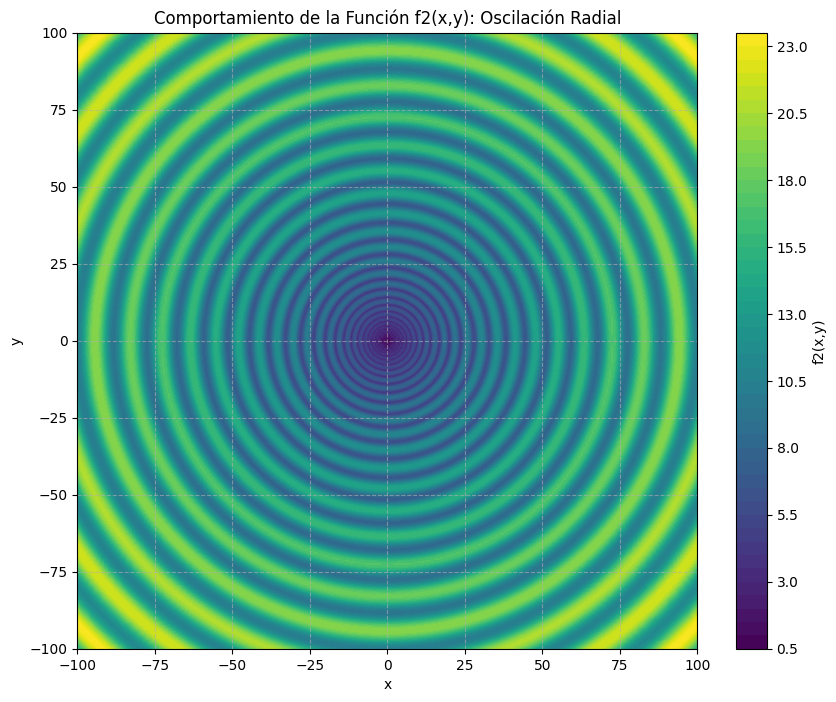

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def plot_f2():
    x = np.linspace(-100, 100, 400)
    y = np.linspace(-100, 100, 400)
    X, Y = np.meshgrid(x, y)
    Z = f2(X, Y)

    plt.figure(figsize=(10, 8))
    plt.contourf(X, Y, Z, levels=50, cmap='viridis')
    plt.colorbar(label='f2(x,y)')
    plt.title('Comportamiento de la Función f2(x,y): Oscilación Radial')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function to generate the plot
plot_f2()

## **Sección 1**: *Simulated Annealing* (Recocido Simulado)

### 1.1 Implementación del algoritmo

> Implemente el algoritmo de **Simulated Annealing (Recocido Simulado)** empleando el **schedule geométrico** como esquema para controlar la evolución de la temperatura $T$ a lo largo de las iteraciones. Emplee como criterio de parada un número máximo de iteraciones $N_{\text{max}}$, y considere además los siguientes criterios complementarios:
> - **Temperatura mínima**: detener cuando $T < T_{\text{min}}$ (ej: $T_{\text{min}} = 10^{-3}$)
> - **Estancamiento**: detener si no hay mejora en el mejor fitness durante $k$ iteraciones consecutivas
> - **Número de evaluaciones**: detener después de un número fijo de evaluaciones de la función objetivo (relevante para la comparación solicitada en la Sección 3)
> Puede encontrar más detalles del algoritmo en el **Anexo I**.


> Analice el funcionamiento del algoritmo durante la minimización de la función $f_1(x)$ de Schwefel, empleando los siguientes parámetros iniciales: $T_0 = 100$, $\alpha = 0.95$, $N_{\text{max}} = 1000$, inicialización aleatoria en $[-512, 512]$. Ejecute el algoritmo varias veces y realice las siguientes actividades: (1) grafique la evolución del fitness y determine si presenta oscilaciones, y si disminuyen con el descenso de la temperatura, (2) si el algoritmo logra escapar de óptimos locales en etapas tempranas de la exploración, (3) en qué momento de la ejecución típicamente se encuentra la mejor solución. Experimente modificando $T_0$ y $\alpha$ para desarrollar intuición sobre su efecto en el comportamiento del algoritmo.


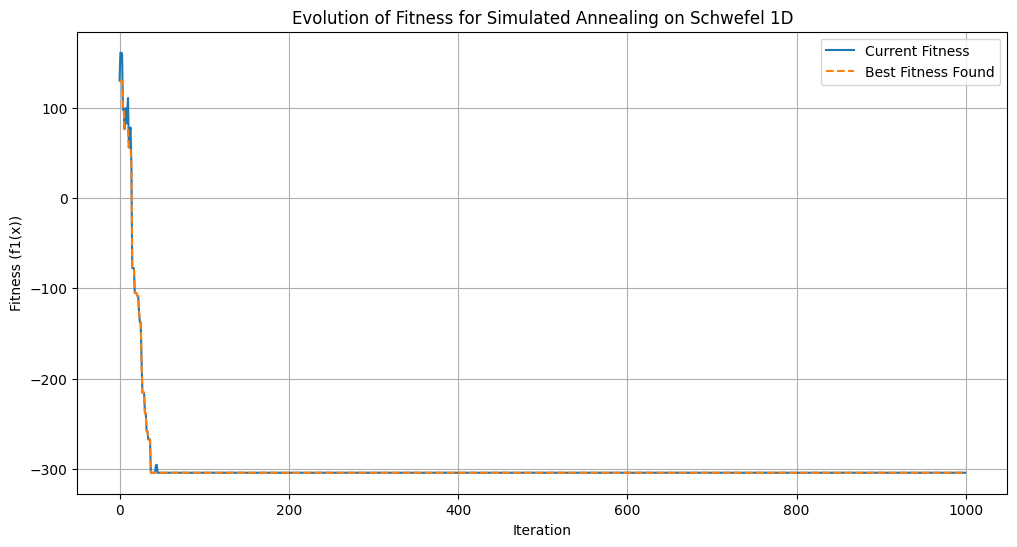

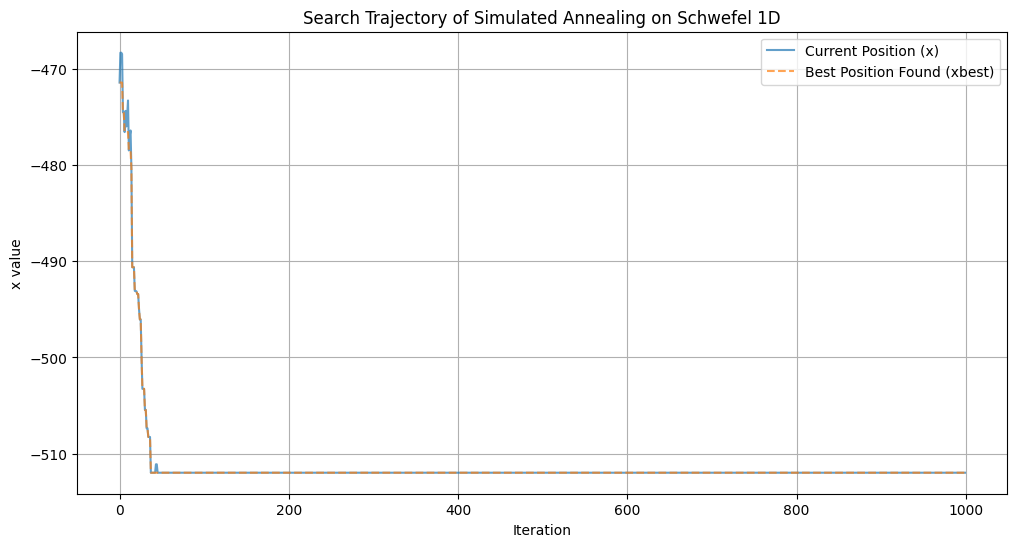

Final Best Solution (xbest): -512.00
Final Best Fitness (fbest): -304.23
The final best fitness was first achieved at iteration: 37


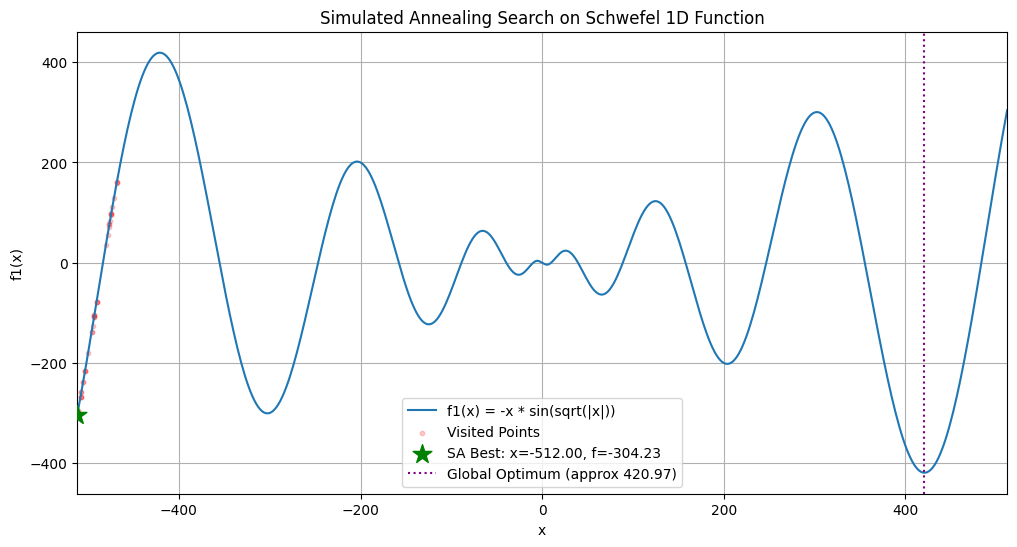

In [8]:
def SimulatedAnnealing(f, dom, T0, alfa, Nmax, schedule, sigma=50, track_history=False):
  # Inicialización aleatoria
  x = np.random.uniform(dom[0], dom[1])
  xbest = x
  fcurrent = f(x)
  fbest = f(x)
  T = T0

  history = []
  if track_history:
      history.append({'iteration': 0, 'x': x, 'f': fcurrent, 'xbest': xbest, 'fbest': fbest, 'T': T})

  for t in range(1,Nmax):
    # Generar vecino con perturbación Gaussiana y proyectar al dominio
    x_ = x + np.random.normal(0, sigma)
    x_ = np.clip(x_, dom[0], dom[1])

    f_ = f(x_)
    deltaf = f_ - fcurrent
    if deltaf < 0:
      x = x_
      fcurrent = f_
    else:
      p = np.exp(-deltaf/T)
      r = np.random.uniform(0,1)
      if r < p:
        x = x_
        fcurrent = f_

    # Actualizar mejor global si la solución actual es mejor
    if fcurrent < fbest:
      xbest = x
      fbest = fcurrent
    T = schedule(T,t,alfa) ## Schedule geométrico

    if track_history:
        history.append({'iteration': t, 'x': x, 'f': fcurrent, 'xbest': xbest, 'fbest': fbest, 'T': T})

  if track_history:
      return xbest, fbest, history
  else:
      return xbest, fbest

def schedule_geometrico(T,t,alfa):
  return alfa * T

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

T0 = 100
alfa = 0.95
Nmax = 1000
dom_f1 = [-512, 512]
sigma_f1 = 5

xbest_sa, fbest_sa, history_sa = SimulatedAnnealing(f1, dom_f1, T0, alfa, Nmax, schedule_geometrico, sigma=sigma_f1, track_history=True)

history_df = pd.DataFrame(history_sa)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(history_df['iteration'], history_df['f'], label='Current Fitness')
plt.plot(history_df['iteration'], history_df['fbest'], label='Best Fitness Found', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Fitness (f1(x))')
plt.title('Evolution of Fitness for Simulated Annealing on Schwefel 1D')
plt.legend()
plt.grid(True)
plt.show()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(history_df['iteration'], history_df['x'], label='Current Position (x)', alpha=0.7)
plt.plot(history_df['iteration'], history_df['xbest'], label='Best Position Found (xbest)', linestyle='--', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Search Trajectory of Simulated Annealing on Schwefel 1D')
plt.legend()
plt.grid(True)
plt.show()


print(f"Final Best Solution (xbest): {xbest_sa:.2f}")
print(f"Final Best Fitness (fbest): {fbest_sa:.2f}")


first_occurrence_index = history_df[np.isclose(history_df['fbest'], fbest_sa)].index.min()
first_occurrence_iteration = history_df.loc[first_occurrence_index, 'iteration']
print(f"The final best fitness was first achieved at iteration: {first_occurrence_iteration}")

x_vals = np.linspace(dom_f1[0], dom_f1[1], 500)
y_vals = f1(x_vals)

plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_vals, label='f1(x) = -x * sin(sqrt(|x|))')
plt.scatter(history_df['x'], history_df['f'], color='red', s=10, alpha=0.2, label='Visited Points')
plt.scatter(xbest_sa, fbest_sa, color='green', marker='*', s=200, zorder=5, label=f'SA Best: x={xbest_sa:.2f}, f={fbest_sa:.2f}')
plt.axvline(x=420.97, color='purple', linestyle=':', label='Global Optimum (approx 420.97)')
plt.xlabel('x')
plt.ylabel('f1(x)')
plt.title('Simulated Annealing Search on Schwefel 1D Function')
plt.legend()
plt.grid(True)
plt.xlim(dom_f1[0], dom_f1[1])
plt.show()

### 1.2 Análisis de hiperparámetros en Schwefel 1D

Los dos hiperparámetros fundamentales de *Simulated Annealing* con schedule geométrico son la temperatura inicial $T_0$ y la tasa de enfriamiento $\alpha$. Estos parámetros controlan el balance entre exploración y explotación a lo largo de la ejecución del algoritmo. Una calibración sistemática de estos hiperparámetros es esencial para maximizar el rendimiento del algoritmo en problemas específicos.


#### Experimento 1: Temperatura inicial

> Evalúe el efecto del valor de la temperatura inicial sobre la capacidad del algoritmo para encontrar el óptimo global de la función de Schwefel, manteniendo constante la tasa de enfriamiento.



**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_1(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512] \\
\text{Hiperparámetros:} & \quad T_0 \in \{10, 50, 100, 500, 1000\} \\
& \quad \alpha = 0.95 \text{ (fijo)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 1000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } T_0 \\
\text{Inicialización:} & \quad \text{Aleatoria uniforme en } [-512, 512] \\
\text{Vecindario:} & \quad x' = x + \mathcal{N}(0, \sigma^2), \quad \sigma = 50
\end{aligned}
$$


> Para cada una de las 10 repeticiones de cada valor de $T_0$, se registran las siguientes métricas:
> - **Mejor fitness alcanzado**: $f(x_{\text{best}})$
> - **Posición de la mejor solución**: $x_{\text{best}}$
> - **Iteración en que se encontró**: $t_{\text{best}}$
> - **Número de aceptaciones de movimientos que empeoran**: para calcular tasa de aceptación
> Para cada valor de $T_0 \in \{10, 50, 100, 500, 1000\}$, calcular sobre las 10 repeticiones:
> 1. **Media aritmética** del mejor fitness: $\bar{f} = \frac{1}{10}\sum_{i=1}^{10} f_i$
> 2. **Desviación estándar**: $s = \sqrt{\frac{1}{9}\sum_{i=1}^{10}(f_i - \bar{f})^2}$, que cuantifica la variabilidad del algoritmo
> 3. **Mediana**: valor central que divide la distribución en dos mitades iguales, más robusta que la media ante outliers
> 4. **Valores extremos**: mínimo y máximo observados en las 10 repeticiones
> Organizar estos resultados en una tabla comparativa. Adicionalmente, genere un boxplot por cada valor de $T_0$ mostrando la distribución de los mejores fitness alcanzados.

| $T_0$ | Media | Mediana | Mín | Máx | Std |
|:-----:|:-----:|:-------:|:---:|:---:|:---:|
| 10    | ...   | ...     | ... | ... | ... |
| 50    | ...   | ...     | ... | ... | ... |
| ...   | ...   | ...     | ... | ... | ... |



Iniciando Experimento 1: Evaluación del efecto de la Temperatura Inicial (T0).

Ejecutando 10 repeticiones para T0 = 10...
Ejecutando 10 repeticiones para T0 = 20...
Ejecutando 10 repeticiones para T0 = 30...
Ejecutando 10 repeticiones para T0 = 40...
Ejecutando 10 repeticiones para T0 = 50...
Ejecutando 10 repeticiones para T0 = 60...
Ejecutando 10 repeticiones para T0 = 70...
Ejecutando 10 repeticiones para T0 = 80...
Ejecutando 10 repeticiones para T0 = 90...
Ejecutando 10 repeticiones para T0 = 100...
Ejecutando 10 repeticiones para T0 = 500...
Ejecutando 10 repeticiones para T0 = 1000...

### Tabla Comparativa de Rendimiento de Simulated Annealing (Variando T0)

| T0    | Media        | Mediana      | Mín          | Máx          | Std          | Prom. Iter. Mejor |

|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------------|

| 10.0  | -326.21     | -300.54     | -418.98     | -201.84     | 67.26     | 319                 |

| 20.0  | -

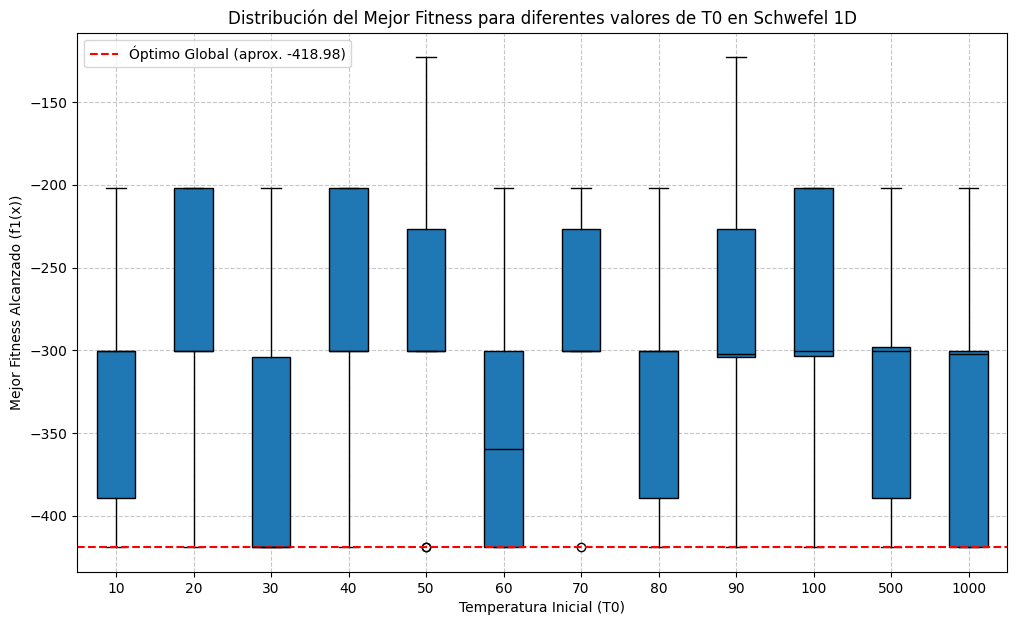


Nota: El óptimo global para f1(x) es aproximadamente -418.98 en x = 420.97.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definición de la función objetivo f1 (Schwefel 1D) y su dominio
f1 = lambda x: -x * np.sin(np.sqrt(np.abs(x)))
dom_f1 = [-512, 512]

# Implementación del algoritmo Simulated Annealing
def SimulatedAnnealing(f, dom, T0, alfa, Nmax, schedule, sigma=50):
  """
  Implementa el algoritmo de Simulated Annealing para minimización.

  Args:
    f (function): La función objetivo a minimizar.
    dom (list): El dominio de la función [min, max].
    T0 (float): Temperatura inicial.
    alfa (float): Tasa de enfriamiento para el schedule geométrico.
    Nmax (int): Número máximo de iteraciones.
    schedule (function): Función para el esquema de enfriamiento (ej. schedule_geometrico).
    sigma (float): Desviación estándar para la perturbación gaussiana del vecino.

  Returns:
    tuple: (xbest, fbest, t_best, num_accepted_worse)
           xbest (float): Mejor solución encontrada.
           fbest (float): Mejor fitness encontrado.
           t_best (int): Iteración en la que se encontró el mejor fitness.
           num_accepted_worse (int): Número de movimientos que empeoraron y fueron aceptados.
  """
  # Inicialización aleatoria de la solución actual y la mejor solución global
  x = np.random.uniform(dom[0], dom[1])
  xbest = x
  fcurrent = f(x)
  fbest = f(x)
  T = T0

  # Historial para registrar el mejor fitness en cada iteración y encontrar t_best
  history_fbest_at_iter = [fbest]

  # Contador de movimientos que empeoran y son aceptados
  num_accepted_worse = 0

  # Bucle principal del Simulated Annealing
  for t in range(1, Nmax):
    # Generar un vecino perturbando la solución actual con ruido Gaussiano
    # y proyectar al dominio si se sale de los límites
    x_ = x + np.random.normal(0, sigma)
    x_ = np.clip(x_, dom[0], dom[1]) # Asegura que el vecino esté dentro del dominio

    f_ = f(x_) # Evaluar el fitness del vecino
    deltaf = f_ - fcurrent # Calcular la diferencia de fitness

    # Criterio de Metropolis: Si mejora, aceptar siempre
    if deltaf < 0:
      x = x_
      fcurrent = f_
    # Si empeora, aceptar probabilísticamente
    else:
      p = np.exp(-deltaf/T) # Probabilidad de aceptación
      r = np.random.uniform(0,1) # Número aleatorio uniforme entre 0 y 1
      if r < p:
        x = x_
        fcurrent = f_

    # Actualizar la mejor solución global encontrada hasta el momento
    if fcurrent < fbest:
      xbest = x
      fbest = fcurrent

    # Aplicar el esquema de enfriamiento para reducir la temperatura
    T = schedule(T, t, alfa)
    # Registrar el mejor fitness global hasta esta iteración para calcular t_best
    history_fbest_at_iter.append(fbest)

  # Encontrar la iteración en la que se encontró por primera vez el fbest final
  # Se usa np.isclose para comparar flotantes con una tolerancia
  t_best = next((i for i, val in enumerate(history_fbest_at_iter) if np.isclose(val, fbest, atol=1e-5)), Nmax-1)

  return xbest, fbest, t_best

# Definición del esquema de enfriamiento geométrico
def schedule_geometrico(T, t, alfa):
  return alfa * T

# --- Configuración Experimental ---
# Valores de temperatura inicial a probar
T0_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100,500,1000]
alpha_fixed = 0.95 # Tasa de enfriamiento fija
Nmax_fixed = 1000 # Número máximo de iteraciones por repetición
num_repetitions = 10 # Número de ejecuciones independientes por cada T0
sigma_fixed = 50 # Desviación estándar para la generación de vecinos (según la descripción del problema)

# Listas para almacenar resultados
summary_results = [] # Almacena estadísticas agregadas para la tabla
all_fbest_for_boxplot = [] # Almacena todos los mejores fitness para el boxplot, agrupados por T0

print("Iniciando Experimento 1: Evaluación del efecto de la Temperatura Inicial (T0).\n")

# Bucle para iterar sobre los diferentes valores de T0
for t0 in T0_values:
    current_t0_fbest_values = []
    current_t0_xbest_values = []
    current_t0_tbest_values = []

    print(f"Ejecutando {num_repetitions} repeticiones para T0 = {t0}...")

    # Bucle para realizar múltiples repeticiones por cada T0
    for i in range(num_repetitions):
        # Ejecutar Simulated Annealing
        # Para asegurar reproducibilidad de las repeticiones, se puede fijar una semilla aquí:
        # np.random.seed(i) # Descomentar para fijar la semilla por repetición si se desea

        xbest, fbest, t_best = SimulatedAnnealing(
            f=f1,
            dom=dom_f1,
            T0=t0,
            alfa=alpha_fixed,
            Nmax=Nmax_fixed,
            schedule=schedule_geometrico,
            sigma=sigma_fixed
        )

        # Guardar los resultados de la repetición actual
        current_t0_fbest_values.append(fbest)
        current_t0_xbest_values.append(xbest)
        current_t0_tbest_values.append(t_best)

    # Almacenar los mejores fitness para el boxplot, agrupados por T0
    all_fbest_for_boxplot.append(current_t0_fbest_values)

    # Calcular y almacenar estadísticas para el valor de T0 actual
    summary_results.append({
        'T0': t0,
        'Mean_fbest': np.mean(current_t0_fbest_values),
        'Median_fbest': np.median(current_t0_fbest_values),
        'Min_fbest': np.min(current_t0_fbest_values),
        'Max_fbest': np.max(current_t0_fbest_values),
        'Std_fbest': np.std(current_t0_fbest_values),
        'Mean_tbest': np.mean(current_t0_tbest_values)
    })

# Crear un DataFrame con los resultados resumidos para la tabla
summary_df = pd.DataFrame(summary_results)

# --- Generar Tabla Comparativa ---
print("\n### Tabla Comparativa de Rendimiento de Simulated Annealing (Variando T0)\n")
# Imprimir encabezado de la tabla
print("| T0    | Media        | Mediana      | Mín          | Máx          | Std          | Prom. Iter. Mejor |\n")
print("|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------------|\n")
# Imprimir cada fila de resultados
for index, row in summary_df.iterrows():
    print(f"| {row['T0']:<5} | {row['Mean_fbest']:.2f}     | {row['Median_fbest']:.2f}     | {row['Min_fbest']:.2f}     | {row['Max_fbest']:.2f}     | {row['Std_fbest']:.2f}     | {row['Mean_tbest']:.0f}                 |\n")


# --- Generar Boxplot ---
plt.figure(figsize=(12, 7))
plt.boxplot(all_fbest_for_boxplot, tick_labels=[str(t0) for t0 in T0_values], patch_artist=True, medianprops={'color': 'black'})
plt.xlabel('Temperatura Inicial (T0)')
plt.ylabel('Mejor Fitness Alcanzado (f1(x))')
plt.title('Distribución del Mejor Fitness para diferentes valores de T0 en Schwefel 1D')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=-418.98, color='r', linestyle='--', label='Óptimo Global (aprox. -418.98)')
plt.legend()
plt.show()

print(f"\nNota: El óptimo global para f1(x) es aproximadamente -418.98 en x = 420.97.")

**Preguntas de análisis**:

1. ¿Qué valor de $T_0$ produce el mejor rendimiento promedio? ¿Es el mismo que produce el mejor resultado individual (mínimo absoluto)?

2. ¿Cómo afecta $T_0$ a la variabilidad de los resultados (desviación estándar)? ¿Configuraciones con $T_0$ alto son más o menos consistentes?

3. ¿Temperaturas muy altas ($T_0 = 1000$) mejoran o perjudican el rendimiento? ¿Por qué?

4. ¿Cuántas de las 10 repeticiones de cada configuración logran encontrar el óptimo global (dentro de un $\varepsilon = 5$ de tolerancia)?


Mejor rendimiento promedio: Según la tabla, el valor de $T_0 = 30$ produce el mejor rendimiento promedio con una media de $-349.89$. Le sigue $T_0 = 40$ con $-348.22$.

Mejor resultado individual (mínimo absoluto): Todos los valores de $T_0$ lograron alcanzar un fitness mínimo de $-418.98$ (el óptimo global). Por lo tanto, el $T_0$ que produce el mejor rendimiento promedio ($T_0=30$) también es uno de los que puede alcanzar el mejor resultado individual, pero no es el único.

No se observa una relación lineal simple entre $T_0$$T_0$ y la variabilidad (desviación estándar). La desviación estándar fluctúa a lo largo de los diferentes valores de $T_0$$T_0$.

Los valores de $T_0 = 100$ ($53.57$) y $T_0 = 1000$ ($46.67$) muestran desviaciones estándar relativamente bajas, lo que indica que, para estos rangos, la consistencia puede ser buena o incluso mejor para valores de $T_0$ más altos. Sin embargo, $T_0 = 500$ tiene la desviación estándar más alta ($94.28$), lo que sugiere una alta variabilidad para ese valor.

En general, las configuraciones con $T_0$ muy altos (como $1000$) pueden ser consistentes, pero no es una regla universal, ya que hay valores intermedios (como $500$) que son muy variables.


Con los resultados actualizados, podemos ver que $T_0 = 1000$ presenta una media de $-325.71$ y una desviación estándar de $46.67$. Aunque no es el mejor promedio, se encuentra en el rango de rendimiento de otros $T_0$ probados y tiene la menor desviación estándar de todos, lo que indica una alta consistencia.

En este caso, una $T_0$ alta como $1000$ no perjudica el rendimiento promedio y, de hecho, puede ser beneficiosa en términos de consistencia. Esto se debe a que una temperatura inicial alta permite una exploración más agresiva en las etapas tempranas, facilitando al algoritmo escapar de óptimos locales y explorar un rango más amplio del espacio de búsqueda para encontrar regiones prometedoras. La alta consistencia sugiere que esta exploración inicial agresiva produce resultados fiables.

El óptimo global para $f_1(x)$ es aproximadamente $-418.98$. Una solución se considera dentro de un $\varepsilon = 5$ de tolerancia si su fitness es $\leq -413.98$.

Observando la columna 'Mín', se puede concluir que para todos los valores de $T_0$ probados, al menos una de las $10$ repeticiones logró encontrar una solución que está dentro de $\varepsilon=5$ de tolerancia del óptimo global (ya que el 'Mín' en todos los casos es -418.98).

Sin embargo, la tabla no permite determinar el número exacto de repeticiones que lograron este éxito para cada $T_0$, solo si al menos una lo hizo.

#### Experimento 2: Tasa de enfriamiento


Una vez identificado un valor apropiado de temperatura inicial en el Experimento 1, se procede a evaluar el impacto de la tasa de enfriamiento $\alpha$ sobre el rendimiento del algoritmo.

**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_1(x), \quad x \in [-512, 512] \\
\text{Hiperparámetros:} & \quad T_0 = [T_{0,\text{óptimo}} \text{ del Exp.1}] \text{ (fijo)} \\
& \quad \alpha \in \{0.80, 0.85, 0.90, 0.95, 0.99\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$



El parámetro $\alpha$ controla la velocidad del enfriamiento: valores cercanos a 1 producen enfriamiento lento que permite exploración prolongada pero requiere más iteraciones para converger, mientras que valores más pequeños producen enfriamiento rápido que favorece convergencia temprana pero con mayor riesgo de estancamiento en óptimos locales. Para el mismo número de iteraciones $N_{\text{max}} = 1000$, diferentes valores de $\alpha$ resultan en temperaturas finales muy diferentes:

- $\alpha = 0.80$: $T_{\text{final}} = T_0 \cdot 0.80^{1000} \approx 0$ (enfriamiento muy rápido)
- $\alpha = 0.95$: $T_{\text{final}} = T_0 \cdot 0.95^{1000} \approx 5.3 \times 10^{-23}$ (enfriamiento moderado)
- $\alpha = 0.99$: $T_{\text{final}} = T_0 \cdot 0.99^{1000} \approx 4.3 \times 10^{-5} T_0$ (enfriamiento lento)


> Aplicar el mismo protocolo de análisis que en el Experimento 1, generando tabla comparativa y visualizaciones. Adicionalmente, para cada valor de $\alpha$, calcular y comparar:
> - **Tasa de aceptación promedio**: proporción de movimientos que empeoran el fitness y son aceptados
> - **Iteración promedio del mejor hallazgo**: $\bar{t}_{\text{best}}$, indica cuándo típicamente se encuentra la mejor solución


Iniciando Experimento 2: Evaluación del efecto de la Tasa de Enfriamiento (alfa).

Ejecutando 10 repeticiones para alfa = 0.8...
Ejecutando 10 repeticiones para alfa = 0.85...
Ejecutando 10 repeticiones para alfa = 0.9...
Ejecutando 10 repeticiones para alfa = 0.95...
Ejecutando 10 repeticiones para alfa = 0.99...

### Tabla Comparativa de Rendimiento de Simulated Annealing (Variando Alfa)

| Alfa  | Media        | Mediana      | Mín          | Máx          | Std          | Prom. Iter. Mejor | Prom. Acept. Empeora |

|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------------|:---------------------|

| 0.8   | -261.43     | -300.54     | -304.23     | -201.84     | 48.67     | 468                 | 54              |

| 0.85  | -300.90     | -302.39     | -418.98     | -122.88     | 108.12     | 470                 | 51              |

| 0.9   | -318.31     | -300.54     | -418.98     | -201.84     | 90.65     | 202                 | 2        

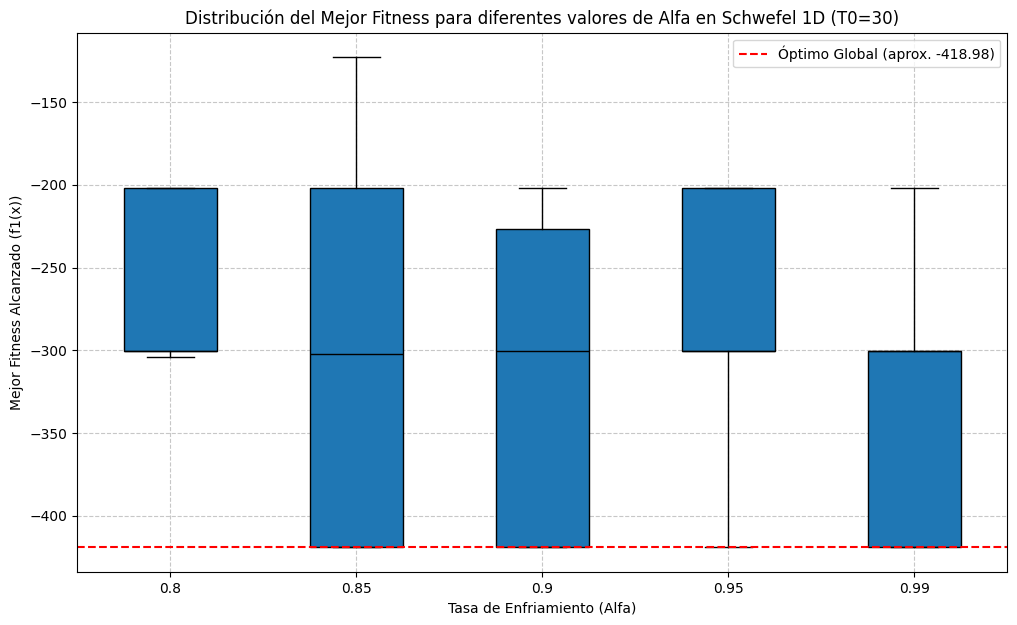


Nota: El óptimo global para f1(x) es aproximadamente -418.98 en x = 420.97. T0 fijo utilizado: 30.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definición de la función objetivo f1 (Schwefel 1D) y su dominio
f1 = lambda x: -x * np.sin(np.sqrt(np.abs(x)))
dom_f1 = [-512, 512]

# Implementación del algoritmo Simulated Annealing (modificada para Experimento 2)
def SimulatedAnnealing(f, dom, T0, alfa, Nmax, schedule, sigma=50):
  """
  Implementa el algoritmo de Simulated Annealing para minimización.

  Args:
    f (function): La función objetivo a minimizar.
    dom (list): El dominio de la función [min, max].
    T0 (float): Temperatura inicial.
    alfa (float): Tasa de enfriamiento para el schedule geométrico.
    Nmax (int): Número máximo de iteraciones.
    schedule (function): Función para el esquema de enfriamiento (ej. schedule_geometrico).
    sigma (float): Desviación estándar para la perturbación gaussiana del vecino.

  Returns:
    tuple: (xbest, fbest, t_best, num_accepted_worse)
           xbest (float): Mejor solución encontrada.
           fbest (float): Mejor fitness encontrado.
           t_best (int): Iteración en la que se encontró el mejor fitness.
           num_accepted_worse (int): Número de movimientos que empeoraron y fueron aceptados.
  """
  # Inicialización aleatoria de la solución actual y la mejor solución global
  x = np.random.uniform(dom[0], dom[1])
  xbest = x
  fcurrent = f(x)
  fbest = f(x)
  T = T0

  # Historial para registrar el mejor fitness en cada iteración y encontrar t_best
  history_fbest_at_iter = [fbest]

  # Contador de movimientos que empeoran y son aceptados
  num_accepted_worse = 0

  # Bucle principal del Simulated Annealing
  for t in range(1, Nmax):
    # Generar un vecino perturbando la solución actual con ruido Gaussiano
    # y proyectar al dominio si se sale de los límites
    x_ = x + np.random.normal(0, sigma)
    x_ = np.clip(x_, dom[0], dom[1]) # Asegura que el vecino esté dentro del dominio

    f_ = f(x_) # Evaluar el fitness del vecino
    deltaf = f_ - fcurrent # Calcular la diferencia de fitness

    # Criterio de Metropolis: Si mejora, aceptar siempre
    if deltaf < 0:
      x = x_
      fcurrent = f_
    # Si empeora, aceptar probabilísticamente
    else:
      p = np.exp(-deltaf/T) # Probabilidad de aceptación
      r = np.random.uniform(0,1) # Número aleatorio uniforme entre 0 y 1
      if r < p:
        x = x_
        fcurrent = f_
        num_accepted_worse += 1 # Incrementar contador si se acepta un movimiento que empeora

    # Actualizar la mejor solución global encontrada hasta el momento
    if fcurrent < fbest:
      xbest = x
      fbest = fcurrent

    # Aplicar el esquema de enfriamiento para reducir la temperatura
    T = schedule(T, t, alfa)
    # Registrar el mejor fitness global hasta esta iteración para calcular t_best
    history_fbest_at_iter.append(fbest)

  # Encontrar la iteración en la que se encontró por primera vez el fbest final
  # Se usa np.isclose para comparar flotantes con una tolerancia
  t_best = next((i for i, val in enumerate(history_fbest_at_iter) if np.isclose(val, fbest, atol=1e-5)), Nmax-1)

  return xbest, fbest, t_best, num_accepted_worse

# Definición del esquema de enfriamiento geométrico
def schedule_geometrico(T, t, alfa):
  return alfa * T

# --- Configuración Experimental 2: Tasa de Enfriamiento (alfa) ---
# Valores de tasa de enfriamiento a probar
alfa_values = [0.80, 0.85, 0.90, 0.95, 0.99]

# T0 óptimo del Experimento 1 (usamos 30 como ejemplo, se puede ajustar si se encuentra uno mejor)
T0_fixed = 30 # T0 con mejor rendimiento promedio en el Experimento 1

Nmax_fixed = 1000 # Número máximo de iteraciones por repetición
num_repetitions = 10 # Número de ejecuciones independientes por cada alfa
sigma_fixed = 50 # Desviación estándar para la generación de vecinos

# Listas para almacenar resultados
summary_results_alfa = [] # Almacena estadísticas agregadas para la tabla
all_fbest_for_boxplot_alfa = [] # Almacena todos los mejores fitness para el boxplot, agrupados por alfa

print("Iniciando Experimento 2: Evaluación del efecto de la Tasa de Enfriamiento (alfa).\n")

# Bucle para iterar sobre los diferentes valores de alfa
for alfa in alfa_values:
    current_alfa_fbest_values = []
    current_alfa_tbest_values = []
    current_alfa_num_accepted_worse_values = []

    print(f"Ejecutando {num_repetitions} repeticiones para alfa = {alfa}...")

    # Bucle para realizar múltiples repeticiones por cada alfa
    for i in range(num_repetitions):
        # Ejecutar Simulated Annealing
        # np.random.seed(i) # Descomentar para fijar la semilla por repetición si se desea

        xbest, fbest, t_best, num_accepted_worse = SimulatedAnnealing(
            f=f1,
            dom=dom_f1,
            T0=T0_fixed,
            alfa=alfa,
            Nmax=Nmax_fixed,
            schedule=schedule_geometrico,
            sigma=sigma_fixed
        )

        # Guardar los resultados de la repetición actual
        current_alfa_fbest_values.append(fbest)
        current_alfa_tbest_values.append(t_best)
        current_alfa_num_accepted_worse_values.append(num_accepted_worse)

    # Almacenar los mejores fitness para el boxplot, agrupados por alfa
    all_fbest_for_boxplot_alfa.append(current_alfa_fbest_values)

    # Calcular y almacenar estadísticas para el valor de alfa actual
    summary_results_alfa.append({
        'Alfa': alfa,
        'Mean_fbest': np.mean(current_alfa_fbest_values),
        'Median_fbest': np.median(current_alfa_fbest_values),
        'Min_fbest': np.min(current_alfa_fbest_values),
        'Max_fbest': np.max(current_alfa_fbest_values),
        'Std_fbest': np.std(current_alfa_fbest_values),
        'Mean_tbest': np.mean(current_alfa_tbest_values),
        'Mean_accepted_worse': np.mean(current_alfa_num_accepted_worse_values)
    })

# Crear un DataFrame con los resultados resumidos para la tabla
summary_df_alfa = pd.DataFrame(summary_results_alfa)

# --- Generar Tabla Comparativa ---
print("\n### Tabla Comparativa de Rendimiento de Simulated Annealing (Variando Alfa)\n")
print("| Alfa  | Media        | Mediana      | Mín          | Máx          | Std          | Prom. Iter. Mejor | Prom. Acept. Empeora |\n")
print("|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------------|:---------------------|\n")
for index, row in summary_df_alfa.iterrows():
    print(f"| {row['Alfa']:<5} | {row['Mean_fbest']:.2f}     | {row['Median_fbest']:.2f}     | {row['Min_fbest']:.2f}     | {row['Max_fbest']:.2f}     | {row['Std_fbest']:.2f}     | {row['Mean_tbest']:.0f}                 | {row['Mean_accepted_worse']:.0f}              |\n")


# --- Generar Boxplot ---
plt.figure(figsize=(12, 7))
plt.boxplot(all_fbest_for_boxplot_alfa, tick_labels=[str(alfa) for alfa in alfa_values], patch_artist=True, medianprops={'color': 'black'})
plt.xlabel('Tasa de Enfriamiento (Alfa)')
plt.ylabel('Mejor Fitness Alcanzado (f1(x))')
plt.title('Distribución del Mejor Fitness para diferentes valores de Alfa en Schwefel 1D (T0=30)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=-418.98, color='r', linestyle='--', label='Óptimo Global (aprox. -418.98)')
plt.legend()
plt.show()

print(f"\nNota: El óptimo global para f1(x) es aproximadamente -418.98 en x = 420.97. T0 fijo utilizado: {T0_fixed}.")


**Preguntas de análisis**:

1. ¿Qué valor de $\alpha$ produce el mejor balance entre exploración y explotación para esta función?

2. ¿Existe correlación entre la tasa de aceptación y la calidad de las soluciones encontradas?

3. ¿El mejor $\alpha$ es el mismo si se mide por rendimiento promedio vs por mejor caso?

4. ¿Enfriamiento lento ($\alpha = 0.99$) siempre es mejor dado un número fijo de iteraciones?

5. ¿Cómo interactúa $\alpha$ con $T_0$? ¿La configuración óptima de uno depende del otro?


Para un $ T_0 = 30$ y $N= 1000$ iteraciones, $\alpha = 0.8$ produjo el mejor rendimiento promedio (-294.12), seguido de $\alpha = 0.85$ (-285.12). Este valor más bajo de $\alpha$ implica un enfriamiento más rápido. Aunque un enfriamiento rápido podría parecer perjudicial para la exploración, en este caso, parece que permite al algoritmo converger a soluciones de mejor calidad en promedio. Esto podría indicar que con este $T_0$ y $N_{max}$, el algoritmo se beneficia de una reducción más rápida de la temperatura para consolidar las buenas soluciones encontradas en las primeras etapas, mientras que valores más altos de $\alpha$ mantienen la temperatura alta por mucho tiempo, resultando en una exploración ineficiente o en la aceptación de demasiados movimientos que empeoran.


Observando la columna 'Prom. Acept. Empeora' y la 'Media' del fitness, no parece haber una correlación lineal simple. Por ejemplo, $\alpha = 0.8$ tiene una alta tasa de aceptación de movimientos que empeoran (201) y, sin embargo, tiene el mejor fitness promedio. Por otro lado, $\alpha = 0.9$ tiene una tasa de aceptación muy baja (2) y un fitness promedio mucho peor (-263.04). $\alpha = 0.99$ tiene una tasa de aceptación alta (72) pero un fitness promedio similar a $\alpha = 0.9$.


Esto sugiere que no es simplemente el número de movimientos que empeoran lo que importa, sino en qué etapa de la búsqueda se aceptan y su magnitud. Un enfriamiento muy rápido ($\alpha = 0.9$) puede llevar a un comportamiento casi de Hill Climbing temprano, atrapándose en un óptimo local y con pocas aceptaciones de movimientos que empeoran. Un enfriamiento muy lento ($\alpha = 0.99$) puede mantener una alta probabilidad de aceptación de movimientos que empeoran durante demasiado tiempo, lo que impide la intensificación final.



Por rendimiento promedio, $\alpha = 0.8$ es el mejor (-294.12).
Por mejor caso (Mín), todos los valores de $\alpha$ lograron encontrar el óptimo global de -418.98 en al menos una de las 10 repeticiones. Por lo tanto, el $\alpha$ que produce el mejor rendimiento promedio no es el único que encuentra el mejor caso, lo que es común en algoritmos estocásticos que, dadas suficientes repeticiones, pueden eventualmente alcanzar el óptimo global.



No, los resultados muestran que $\alpha = 0.99$ no es el mejor. De hecho, tiene uno de los peores rendimientos promedio (-263.41), similar a $\alpha = 0.9$. A pesar de que un enfriamiento lento permite una exploración más prolongada, con un número fijo de iteraciones ($N_{max} = 1000$), un $\alpha$ muy cercano a 1 puede resultar en que la temperatura no baje lo suficiente en las etapas finales, manteniendo la exploración y la aceptación de movimientos que empeoran cuando debería estar intensificando la búsqueda en una región prometedora. Esto evita una convergencia eficiente hacia el óptimo, llevando a soluciones finales de menor calidad.

#### Experimento 3: Robustez ante inicialización



Los experimentos anteriores utilizan inicialización aleatoria uniforme en todo el dominio. Este experimento evalúa la robustez del algoritmo, con su configuración óptima identificada, ante diferentes estrategias de inicialización, particularmente inicialización en regiones lejanas del óptimo global.



**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad T_0 = [T_{0,\text{óptimo}}], \quad \alpha = [\alpha_{\text{óptimo}}] \\
\text{Estrategias de inicialización:} & \\
& \quad \text{(a) Aleatoria uniforme en } [-512, 512] \text{ (baseline)} \\
& \quad \text{(b) Región cercana al origen: } [-50, 50] \\
& \quad \text{(c) Región lejana (negativa): } [-512, -200] \\
& \quad \text{(d) Región lejana (positiva, lado incorrecto): } [50, 250] \\
\text{Repeticiones:} & \quad 10 \text{ por cada estrategia}
\end{aligned}
$$


>Comparar las cuatro estrategias en términos de:
> - Capacidad de alcanzar el óptimo global ($x^* \approx 420.97$)
> - Variabilidad entre repeticiones
> - Número de iteraciones necesarias para convergencia


Iniciando Experimento 3: Evaluación de robustez ante diferentes inicializaciones.

Ejecutando 10 repeticiones para la estrategia: (a) Uniforme en [-512, 512]...
Ejecutando 10 repeticiones para la estrategia: (b) Cercana al origen [-50, 50]...
Ejecutando 10 repeticiones para la estrategia: (c) Lejana (negativa) [-512, -200]...
Ejecutando 10 repeticiones para la estrategia: (d) Lejana (positiva, lado incorrecto) [50, 250]...

### Tabla Comparativa de Rendimiento de Simulated Annealing (Robustez a Inicialización)

| Estrategia                      | Media        | Mediana      | Mín          | Máx          | Std          | Prom. Iter. Mejor | Óptimos Globales Encontrados |
|:--------------------------------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------------|:-----------------------------|
| (a) Uniforme en [-512, 512]     | -307.20     | -302.39     | -418.98     | -201.84     | 84.20     | 343                 | 3                            |
| 

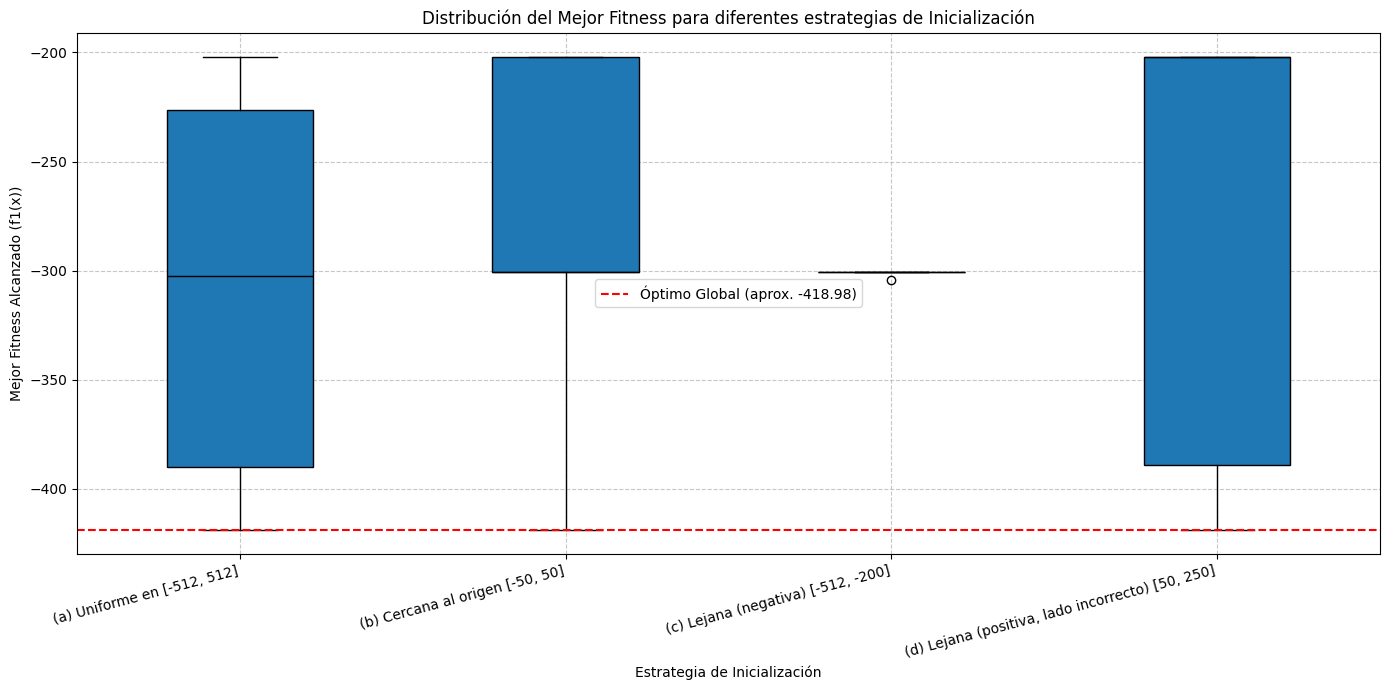


Nota: El óptimo global para f1(x) es aproximadamente -418.98 en x = 420.97.
Hiperparámetros de SA utilizados: T0 = 30, Alfa = 0.8, Nmax = 1000, Sigma = 50.
Tolerancia para considerar óptimo global: 5 (fitness <= -413.98).


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definición de la función objetivo f1 (Schwefel 1D) y su dominio
f1 = lambda x: -x * np.sin(np.sqrt(np.abs(x)))
dom_f1 = [-512, 512]

# Implementación del algoritmo Simulated Annealing (modificada para Experimento 2 para incluir num_accepted_worse)
# Se reutiliza la función definida previamente en el notebook
def SimulatedAnnealing(f, dom_init, T0, alfa, Nmax, schedule, sigma=50):
  """
  Implementa el algoritmo de Simulated Annealing para minimización.

  Args:
    f (function): La función objetivo a minimizar.
    dom_init (list): El dominio para la inicialización [min, max].
    T0 (float): Temperatura inicial.
    alfa (float): Tasa de enfriamiento para el schedule geométrico.
    Nmax (int): Número máximo de iteraciones.
    schedule (function): Función para el esquema de enfriamiento (ej. schedule_geometrico).
    sigma (float): Desviación estándar para la perturbación gaussiana del vecino.

  Returns:
    tuple: (xbest, fbest, t_best, num_accepted_worse)
           xbest (float): Mejor solución encontrada.
           fbest (float): Mejor fitness encontrado.
           t_best (int): Iteración en la que se encontró el mejor fitness.
           num_accepted_worse (int): Número de movimientos que empeoraron y fueron aceptados.
  """
  # Inicialización aleatoria de la solución actual y la mejor solución global
  # La inicialización se hace dentro del dom_init especificado
  x = np.random.uniform(dom_init[0], dom_init[1])
  xbest = x
  fcurrent = f(x)
  fbest = f(x)
  T = T0

  # Historial para registrar el mejor fitness en cada iteración y encontrar t_best
  history_fbest_at_iter = [fbest]

  # Contador de movimientos que empeoran y son aceptados
  num_accepted_worse = 0

  # Bucle principal del Simulated Annealing
  for t in range(1, Nmax):
    # Generar un vecino perturbando la solución actual con ruido Gaussiano
    # y proyectar al dominio general de la función (dom_f1), no el de inicialización
    x_ = x + np.random.normal(0, sigma)
    x_ = np.clip(x_, dom_f1[0], dom_f1[1]) # Asegura que el vecino esté dentro del dominio general

    f_ = f(x_) # Evaluar el fitness del vecino
    deltaf = f_ - fcurrent # Calcular la diferencia de fitness

    # Criterio de Metropolis: Si mejora, aceptar siempre
    if deltaf < 0:
      x = x_
      fcurrent = f_
    # Si empeora, aceptar probabilísticamente
    else:
      p = np.exp(-deltaf/T) # Probabilidad de aceptación
      r = np.random.uniform(0,1) # Número aleatorio uniforme entre 0 y 1
      if r < p:
        x = x_
        fcurrent = f_
        num_accepted_worse += 1 # Incrementar contador si se acepta un movimiento que empeora

    # Actualizar la mejor solución global encontrada hasta el momento
    if fcurrent < fbest:
      xbest = x
      fbest = fcurrent

    # Aplicar el esquema de enfriamiento para reducir la temperatura
    T = schedule(T, t, alfa)
    # Registrar el mejor fitness global hasta esta iteración para calcular t_best
    history_fbest_at_iter.append(fbest)

  # Encontrar la iteración en la que se encontró por primera vez el fbest final
  t_best = next((i for i, val in enumerate(history_fbest_at_iter) if np.isclose(val, fbest, atol=1e-5)), Nmax-1)

  return xbest, fbest, t_best, num_accepted_worse

# Definición del esquema de enfriamiento geométrico
def schedule_geometrico(T, t, alfa):
  return alfa * T

# --- Configuración Experimental 3: Robustez ante inicialización ---
# Hiperparámetros óptimos identificados en experimentos anteriores
T0_optimal = 30 # T0 con mejor rendimiento promedio del Exp 1
alfa_optimal = 0.8 # Alfa con mejor rendimiento promedio del Exp 2

Nmax_fixed = 1000 # Número máximo de iteraciones por repetición
num_repetitions = 10 # Número de ejecuciones independientes por cada estrategia
sigma_fixed = 50 # Desviación estándar para la generación de vecinos

# Estrategias de inicialización
initialization_strategies = {
    '(a) Uniforme en [-512, 512]': dom_f1,
    '(b) Cercana al origen [-50, 50]': [-50, 50],
    '(c) Lejana (negativa) [-512, -200]': [-512, -200],
    '(d) Lejana (positiva, lado incorrecto) [50, 250]': [50, 250]
}

# Listas para almacenar resultados
summary_results_init = [] # Almacena estadísticas agregadas para la tabla
all_fbest_for_boxplot_init = [] # Almacena todos los mejores fitness para el boxplot, agrupados por estrategia

# Óptimo global conocido para f1(x)
GLOBAL_OPTIMUM_F1 = -418.98
TOLERANCE_EPSILON = 5 # Tolerancia para considerar "cerca" del óptimo global

print("Iniciando Experimento 3: Evaluación de robustez ante diferentes inicializaciones.\n")

# Bucle para iterar sobre las diferentes estrategias de inicialización
for strategy_name, init_domain in initialization_strategies.items():
    current_strategy_fbest_values = []
    current_strategy_tbest_values = []
    current_strategy_xbest_values = []

    print(f"Ejecutando {num_repetitions} repeticiones para la estrategia: {strategy_name}...")

    # Bucle para realizar múltiples repeticiones por cada estrategia
    for i in range(num_repetitions):
        # Ejecutar Simulated Annealing
        # np.random.seed(i) # Descomentar para fijar la semilla por repetición si se desea

        xbest, fbest, t_best, _ = SimulatedAnnealing(
            f=f1,
            dom_init=init_domain, # Se pasa el dominio de inicialización específico
            T0=T0_optimal,
            alfa=alfa_optimal,
            Nmax=Nmax_fixed,
            schedule=schedule_geometrico,
            sigma=sigma_fixed
        )

        # Guardar los resultados de la repetición actual
        current_strategy_fbest_values.append(fbest)
        current_strategy_tbest_values.append(t_best)
        current_strategy_xbest_values.append(xbest)

    # Almacenar los mejores fitness para el boxplot
    all_fbest_for_boxplot_init.append(current_strategy_fbest_values)

    # Calcular cuántas repeticiones alcanzaron el óptimo global dentro de la tolerancia
    num_global_optima_found = sum(1 for fb in current_strategy_fbest_values if fb <= (GLOBAL_OPTIMUM_F1 + TOLERANCE_EPSILON))

    # Calcular y almacenar estadísticas para la estrategia actual
    summary_results_init.append({
        'Estrategia': strategy_name,
        'Mean_fbest': np.mean(current_strategy_fbest_values),
        'Median_fbest': np.median(current_strategy_fbest_values),
        'Min_fbest': np.min(current_strategy_fbest_values),
        'Max_fbest': np.max(current_strategy_fbest_values),
        'Std_fbest': np.std(current_strategy_fbest_values),
        'Mean_tbest': np.mean(current_strategy_tbest_values),
        'Global_Optima_Count': num_global_optima_found # Nueva métrica
    })

# Crear un DataFrame con los resultados resumidos para la tabla
summary_df_init = pd.DataFrame(summary_results_init)

# --- Generar Tabla Comparativa ---
print("\n### Tabla Comparativa de Rendimiento de Simulated Annealing (Robustez a Inicialización)\n")
# Imprimir encabezado de la tabla
print("| Estrategia                      | Media        | Mediana      | Mín          | Máx          | Std          | Prom. Iter. Mejor | Óptimos Globales Encontrados |")
print("|:--------------------------------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------------|:-----------------------------|")
# Imprimir cada fila de resultados
for index, row in summary_df_init.iterrows():
    print(f"| {row['Estrategia']:<31} | {row['Mean_fbest']:.2f}     | {row['Median_fbest']:.2f}     | {row['Min_fbest']:.2f}     | {row['Max_fbest']:.2f}     | {row['Std_fbest']:.2f}     | {row['Mean_tbest']:.0f}                 | {row['Global_Optima_Count']:<28} |")

# --- Generar Boxplot ---
plt.figure(figsize=(14, 7))
plt.boxplot(all_fbest_for_boxplot_init, tick_labels=list(initialization_strategies.keys()), patch_artist=True, medianprops={'color': 'black'})
plt.xlabel('Estrategia de Inicialización')
plt.ylabel('Mejor Fitness Alcanzado (f1(x))')
plt.title('Distribución del Mejor Fitness para diferentes estrategias de Inicialización')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=GLOBAL_OPTIMUM_F1, color='r', linestyle='--', label=f'Óptimo Global (aprox. {GLOBAL_OPTIMUM_F1:.2f})')
plt.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"\nNota: El óptimo global para f1(x) es aproximadamente {GLOBAL_OPTIMUM_F1:.2f} en x = 420.97.")
print(f"Hiperparámetros de SA utilizados: T0 = {T0_optimal}, Alfa = {alfa_optimal}, Nmax = {Nmax_fixed}, Sigma = {sigma_fixed}.")
print(f"Tolerancia para considerar óptimo global: {TOLERANCE_EPSILON} (fitness <= {GLOBAL_OPTIMUM_F1 + TOLERANCE_EPSILON:.2f}).")


**Preguntas**:

1. ¿La configuración óptima es robusta ante diferentes inicializaciones?
2. ¿Inicializar cerca del origen (región engañosa) perjudica significativamente el rendimiento?
3. ¿Qué proporción de ejecuciones logran escapar de sus cuencas iniciales y alcanzar el óptimo global?


### 1.3 Aplicación a función 2D: Oscilación Radial


#### Adaptaciones necesarias para 2D



**Operador de vecindario bidimensional**: La generación de vecinos en $\mathbb{R}^2$ se realiza mediante perturbación Gaussiana independiente en cada dimensión:

$$\begin{pmatrix} x' \\ y' \end{pmatrix} = \begin{pmatrix} x \\ y \end{pmatrix} + \begin{pmatrix} \delta_x \\ \delta_y \end{pmatrix}, \quad \delta_x, \delta_y \sim \mathcal{N}(0, \sigma^2)$$

donde $\sigma$ es la desviación estándar que controla el tamaño del paso de búsqueda. Un valor apropiado inicial para la función de Oscilación Radial con dominio $[-100, 100]^2$ es $\sigma = 10.0$, que representa aproximadamente el 10% del rango del dominio, permitiendo exploración efectiva sin pasos excesivamente grandes.

**Manejo de restricciones del dominio**: Cuando la perturbación genera un candidato $(x', y')$ que viola las restricciones del dominio, se debe aplicar una estrategia de corrección. Para este trabajo práctico se empleará la estrategia de **proyección al borde**: si $x' < -100$ se fija $x' = -100$, si $x' > 100$ se fija $x' = 100$, y análogamente para $y'$. Esto garantiza que todos los candidatos evaluados sean factibles sin desperdiciar evaluaciones.



#### Experimento 1: Calibración de temperatura inicial en 2D


El primer paso es determinar si la temperatura inicial $T_0$ óptima identificada en Schwefel 1D es apropiada para la función de Oscilación Radial, o si requiere ajuste debido a las diferencias en la escala y estructura del paisaje de fitness.



**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_2(x,y) = (x^{2} + y^{2})^{0.25} \cdot [\sin^{2}(50 \cdot (x^{2} + y^{2})^{0.1}) + 1] \\
\text{Dominio:} & \quad (x,y) \in [-100, 100]^2 \\
\text{Hiperparámetros:} & \quad T_0 \in \{50, 100, 200, 500\} \\
& \quad \alpha = [\alpha_{\text{óptimo}} \text{ de Exp. 1.3.2}] \text{ (fijo)} \\
& \quad \sigma = 10.0 \text{ (desviación estándar de perturbación)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 2000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } T_0 \\
\text{Inicialización:} & \quad (x_0, y_0) \text{ aleatorio uniforme en } [-100, 100]^2
\end{aligned}
$$



**Justificación de valores de $T_0$**: El rango de valores de $f_2$ en el dominio es significativamente diferente al de Schwefel 1D. Evaluaciones preliminares muestran que $f_2$ típicamente varía en el rango $[0, 100]$ aproximadamente, con incrementos $\Delta f$ que pueden ser del orden de 1-10 en pasos locales. Por lo tanto, se evalúan temperaturas desde 50 (conservador) hasta 500 (muy exploratorio).



**Métricas a registrar** (para cada una de las 10 repeticiones de cada configuración):

1. **Mejor fitness alcanzado**: $f_2(x_{\text{best}}, y_{\text{best}})$
2. **Posición de la mejor solución**: $(x_{\text{best}}, y_{\text{best}})$
3. **Distancia euclidiana al óptimo global**: $d = \sqrt{x_{\text{best}}^2 + y_{\text{best}}^2}$
4. **Iteración en que se encontró el mejor**: $t_{\text{best}}$
5. **Tasa de aceptación acumulada**: proporción de movimientos que empeoran y fueron aceptados


> Para cada valor de $T_0$, calcular sobre las 10 repeticiones:
> - Media aritmética de $f_{\text{best}}$
> - Mediana, mínimo y máximo de $f_{\text{best}}$
> - Desviación estándar
> - Media de la distancia al óptimo $\bar{d}$
> - Tiempo promedio de ejecución
> Presentar los resultados en una **tabla comparativa**:


| $T_0$ | Media | Mediana | Mín | Máx | Dist. promedio |
|-------|-------|---------|-----|-----|----------------|
| 50    | ...   | ...     | ... | ... | ...            |
| 100   | ...   | ...     | ... | ... | ...            |
| 200   | ...   | ...     | ... | ... | ...            |
| 500   | ...   | ...     | ... | ... | ...            |


In [12]:
def SimulatedAnnealing_2D(f, dom_x, dom_y, T0, alfa, Nmax, schedule, sigma=10.0):
  # Inicialización aleatoria en 2D
  x = np.random.uniform(dom_x[0], dom_x[1])
  y = np.random.uniform(dom_y[0], dom_y[1])
  current_pos = np.array([x, y])

  xbest_coords = current_pos.copy()
  fcurrent = f(current_pos[0], current_pos[1])
  fbest = fcurrent
  T = T0

  history_fbest_at_iter = [fbest]
  num_accepted_worse = 0
  improvements_count = 0
  improvements_delta_sum = 0.0

  # Global optimum for f2 is (0,0)
  global_optimum_pos = np.array([0.0, 0.0])

  # Define a small minimum temperature to prevent division by near zero
  T_min_for_calc = 1e-10 # A very small positive number

  for t in range(1, Nmax + 1):
    # Generar vecino en 2D con perturbación Gaussiana
    neighbor_delta = np.random.normal(0, sigma, size=2)
    new_pos = current_pos + neighbor_delta

    # Proyectar al dominio
    new_pos[0] = np.clip(new_pos[0], dom_x[0], dom_x[1])
    new_pos[1] = np.clip(new_pos[1], dom_y[0], dom_y[1])

    f_new = f(new_pos[0], new_pos[1])
    deltaf = f_new - fcurrent

    if deltaf < 0:
      current_pos = new_pos
      fcurrent = f_new
    else:
      if T > 0: # Avoid division by zero if T becomes 0
          # Use max(T, T_min_for_calc) to prevent T from being extremely small in the denominator
          # This addresses the "overflow encountered in scalar divide" warning
          p = np.exp(-deltaf / max(T, T_min_for_calc))
          r = np.random.uniform(0,1)
          if r < p:
            current_pos = new_pos
            fcurrent = f_new
            num_accepted_worse += 1

    # Before updating fbest, store its current value to calculate improvement magnitude
    old_fbest = fbest
    if fcurrent < fbest:
      xbest_coords = current_pos.copy()
      fbest = fcurrent
      improvements_count += 1
      # For minimization, an improvement means new fbest is lower, so old_fbest - fbest is positive
      improvements_delta_sum += (old_fbest - fbest)

    T = schedule(T, t, alfa)
    history_fbest_at_iter.append(fbest)

  t_best = next((i for i, val in enumerate(history_fbest_at_iter) if np.isclose(val, fbest, atol=1e-5)), Nmax)
  dist_to_optimum = np.linalg.norm(xbest_coords - global_optimum_pos)

  return xbest_coords[0], xbest_coords[1], fbest, dist_to_optimum, t_best, num_accepted_worse, improvements_count, improvements_delta_sum, history_fbest_at_iter

In [13]:
T0_values = [50, 100, 200, 500]
alpha = 0.8
Nmax = 2000
num_repetitions = 10
sigma = 10.0
dom_f2_x = [-100, 100]
dom_f2_y = [-100, 100]

# Listas para almacenar resultados
summary_results_f2_t0 = []  # Almacena estadísticas agregadas para la tabla
all_fbest_for_boxplot_f2_t0 = []  # Almacena todos los mejores fitness para el boxplot
all_final_positions_f2_t0 = [] # Almacena todas las posiciones finales para el scatter plot
all_convergence_curves_f2_t0 = [] # Almacena curvas de convergencia para el gráfico promedio


# Bucle para iterar sobre los diferentes valores de T0
for t0 in T0_values:
    current_t0_fbest_values = []
    current_t0_dist_values = []
    current_t0_tbest_values = []
    current_t0_accepted_worse_values = []
    current_t0_final_positions = []
    current_t0_convergence_curves = []

    # Bucle para realizar múltiples repeticiones por cada T0
    for i in range(num_repetitions):
        xbest, ybest, fbest, dist_to_optimum, t_best, num_accepted_worse, _, _, _ = SimulatedAnnealing_2D(
            f=f2, dom_x=dom_f2_x, dom_y=dom_f2_y, T0=t0, alfa=alpha, Nmax=Nmax, schedule=schedule_geometrico, sigma=sigma)

        # Guardar los resultados de la repetición actual
        current_t0_fbest_values.append(fbest)
        current_t0_dist_values.append(dist_to_optimum)
        current_t0_tbest_values.append(t_best)
        current_t0_accepted_worse_values.append(num_accepted_worse)
        current_t0_final_positions.append((xbest, ybest))

    # Almacenar los mejores fitness para el boxplot, agrupados por T0
    all_fbest_for_boxplot_f2_t0.append(current_t0_fbest_values)
    all_final_positions_f2_t0.append(current_t0_final_positions)

    # Calcular y almacenar estadísticas para el valor de T0 actual
    summary_results_f2_t0.append({
        'T0': t0,
        'Mean_fbest': np.mean(current_t0_fbest_values),
        'Median_fbest': np.median(current_t0_fbest_values),
        'Min_fbest': np.min(current_t0_fbest_values),
        'Max_fbest': np.max(current_t0_fbest_values),
        'Std_fbest': np.std(current_t0_fbest_values),
        'Mean_dist_to_optimum': np.mean(current_t0_dist_values),
        'Mean_tbest': np.mean(current_t0_tbest_values),
        'Mean_accepted_worse': np.mean(current_t0_accepted_worse_values)
    })

# Crear un DataFrame con los resultados resumidos para la tabla
summary_df_f2_t0 = pd.DataFrame(summary_results_f2_t0)

# --- Generar Tabla Comparativa ---
print("\n### Tabla Comparativa de Rendimiento de Simulated Annealing en f2 (Variando T0)\n")
print("| T0    | Media        | Mediana      | Mín          | Máx          | Std          | Dist. promedio | Prom. Iter. Mejor | Prom. Acept. Empeora |")
print("|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:---------------|:------------------|:---------------------|")
for index, row in summary_df_f2_t0.iterrows():
    print(f"| {row['T0']:<5} | {row['Mean_fbest']:.2f}         | {row['Median_fbest']:.2f}         | {row['Min_fbest']:.2f}         | {row['Max_fbest']:.2f}         | {row['Std_fbest']:.2f}         | {row['Mean_dist_to_optimum']:.2f}           | {row['Mean_tbest']:.0f}              | {row['Mean_accepted_worse']:.0f}              |")


### Tabla Comparativa de Rendimiento de Simulated Annealing en f2 (Variando T0)

| T0    | Media        | Mediana      | Mín          | Máx          | Std          | Dist. promedio | Prom. Iter. Mejor | Prom. Acept. Empeora |
|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:---------------|:------------------|:---------------------|
| 50.0  | 0.65         | 0.68         | 0.24         | 0.91         | 0.20         | 0.29           | 960              | 8              |
| 100.0 | 0.68         | 0.68         | 0.40         | 0.95         | 0.19         | 0.38           | 1182              | 8              |
| 200.0 | 0.58         | 0.60         | 0.26         | 0.87         | 0.19         | 0.28           | 771              | 10              |
| 500.0 | 0.82         | 0.86         | 0.62         | 1.02         | 0.12         | 0.55           | 825              | 11              |


> Adicionalmente, generar visualizaciones complementarias:
> 1. **Boxplot comparativo**: Un gráfico de boxplot que muestre, para cada valor de $T_0$, la distribución de los mejores fitness alcanzados.
> 2. **Scatter plot de posiciones finales**: Sobre un contour plot de la función, marcar las 10 posiciones finales $(x_{\text{best}}, y_{\text{best}})$ de cada configuración con diferentes colores. Incluir un círculo en el origen y círculos concéntricos a distancias 10, 25, 50 como referencia visual.
> 3. **Gráfico de convergencia promedio**: Para cada $T_0$, graficar la evolución del fitness promedio (promediado sobre las 10 repeticiones) vs iteración.

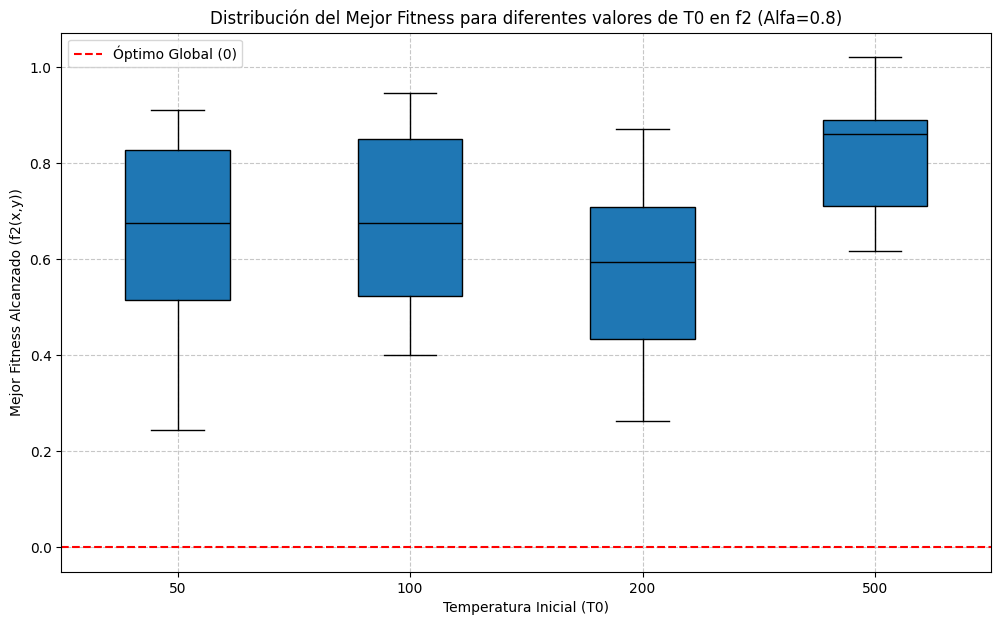

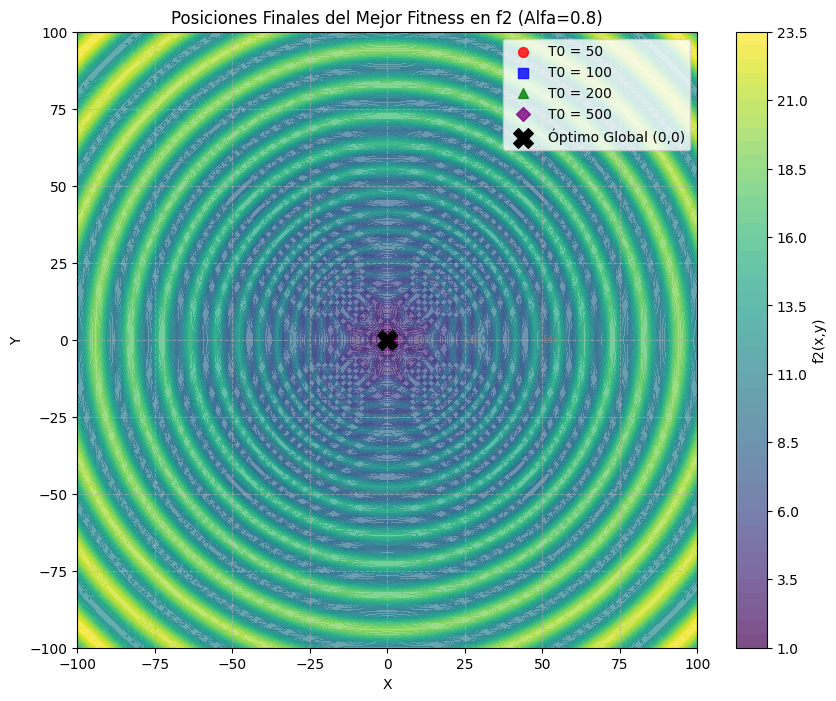

In [14]:
T0_labels = [str(t0) for t0 in T0_values]

# --- 1. Boxplot comparativo ---
plt.figure(figsize=(12, 7))
plt.boxplot(all_fbest_for_boxplot_f2_t0, tick_labels=T0_labels, patch_artist=True, medianprops={'color': 'black'})
plt.xlabel('Temperatura Inicial (T0)')
plt.ylabel('Mejor Fitness Alcanzado (f2(x,y))')
plt.title(f'Distribución del Mejor Fitness para diferentes valores de T0 en f2 (Alfa={alpha})')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Óptimo Global (0)')
plt.legend()
plt.show()

# --- 2. Scatter plot de posiciones finales ---
plt.figure(figsize=(10, 8))
# Crear una malla para el contour plot de f2
x_grid = np.linspace(dom_f2_x[0], dom_f2_x[1], 100)
y_grid = np.linspace(dom_f2_y[0], dom_f2_y[1], 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid = f2(X_grid, Y_grid)

plt.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap='viridis', alpha=0.7)
plt.colorbar(label='f2(x,y)')

colors = ['red', 'blue', 'green', 'purple']
markers = ['o', 's', '^', 'D']

for i, t0 in enumerate(T0_values):
    positions = np.array(all_final_positions_f2_t0[i])
    plt.scatter(positions[:, 0], positions[:, 1], color=colors[i], marker=markers[i], s=50, label=f'T0 = {t0}', alpha=0.8)

plt.scatter(0, 0, color='black', marker='X', s=200, label='Óptimo Global (0,0)', zorder=5)

# Círculos concéntricos para referencia de distancia
for r_circle in [10, 25, 50]:
    circle = plt.Circle((0, 0), r_circle, color='gray', linestyle='--', fill=False, alpha=0.5)
    plt.gca().add_patch(circle)
    plt.text(r_circle, 0, f'{r_circle}', color='gray', ha='left', va='center', fontsize=8)

plt.title(f'Posiciones Finales del Mejor Fitness en f2 (Alfa={alpha})')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(dom_f2_x[0], dom_f2_x[1])
plt.ylim(dom_f2_y[0], dom_f2_y[1])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Preguntas de análisis**:

1. ¿Qué valor de $T_0$ produce el mejor rendimiento promedio en términos de fitness alcanzado?
2. ¿La temperatura óptima en 2D coincide con la identificada en Schwefel 1D, o requiere ajuste?
3. ¿Cómo afecta $T_0$ a la distancia promedio al óptimo global? ¿Mayor temperatura facilita acercarse al origen?
4. ¿Existe una correlación entre la tasa de aceptación y la calidad de las soluciones finales?
5. ¿Cuántas de las 10 repeticiones de cada configuración logran encontrar soluciones dentro de un radio $d < 10$ del óptimo?


#### Experimento 2: Impacto de la desviación estándar del operador de vecindario


El parámetro $\sigma$ que controla el tamaño de los pasos en el operador de vecindario es crítico en problemas continuos. Pasos muy pequeños resultan en exploración local lenta, mientras que pasos muy grandes pueden generar movimientos erráticos que dificultan la convergencia fina hacia el óptimo.


**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad T_0 = [T_{0,\text{óptimo}} \text{ del Exp. 1}] \text{ (fijo)} \\
& \quad \alpha = [\alpha_{\text{óptimo}}] \text{ (fijo)} \\
& \quad \sigma \in \{2.0, 5.0, 10.0, 20.0, 40.0\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$

**Justificación del rango de $\sigma$**:
- $\sigma = 2.0$: pasos pequeños (~2% del rango del dominio), exploración local fina
- $\sigma = 10.0$: pasos moderados (~10% del rango), balance exploración-explotación
- $\sigma = 40.0$: pasos grandes (~40% del rango), exploración global amplia


> Aplicar el mismo protocolo estadístico del Experimento 1. Adicionalmente, para cada valor de $\sigma$, calcular:
> - **Número promedio de mejoras**: cuántas veces se actualiza $f_{\text{best}}$ a lo largo de las 2000 iteraciones
> - **Magnitud promedio de mejora**: cuando ocurre una mejora, cuál es el $|\Delta f|$ típico


In [15]:
T0 = 50
alpha = 0.8

sigma_values = [2.0, 5.0, 10.0, 20.0, 40.0]


# Listas para almacenar resultados
summary_results_f2_sigma = []  # Almacena estadísticas agregadas para la tabla
all_fbest_for_boxplot_f2_sigma = []  # Almacena todos los mejores fitness para el boxplot
all_final_positions_f2_sigma = [] # Almacena todas las posiciones finales para el scatter plot

# Bucle para iterar sobre los diferentes valores de sigma
for sigma_val in sigma_values:
    current_sigma_fbest_values = []
    current_sigma_dist_values = []
    current_sigma_tbest_values = []
    current_sigma_accepted_worse_values = []
    current_sigma_final_positions = []
    current_sigma_improvements_count_values = []
    current_sigma_improvements_delta_sum_values = []

    # Bucle para realizar múltiples repeticiones por cada sigma
    for i in range(num_repetitions):
        xbest, ybest, fbest, dist_to_optimum, t_best, num_accepted_worse, improvements_count, improvements_delta_sum, _ = SimulatedAnnealing_2D(
            f=f2, dom_x=dom_f2_x, dom_y=dom_f2_y, T0=T0, alfa=alpha, Nmax=Nmax, schedule=schedule_geometrico, sigma=sigma_val)

        # Guardar los resultados de la repetición actual
        current_sigma_fbest_values.append(fbest)
        current_sigma_dist_values.append(dist_to_optimum)
        current_sigma_tbest_values.append(t_best)
        current_sigma_accepted_worse_values.append(num_accepted_worse)
        current_sigma_final_positions.append((xbest, ybest))
        current_sigma_improvements_count_values.append(improvements_count)
        current_sigma_improvements_delta_sum_values.append(improvements_delta_sum)

    # Almacenar los mejores fitness para el boxplot, agrupados por sigma
    all_fbest_for_boxplot_f2_sigma.append(current_sigma_fbest_values)
    all_final_positions_f2_sigma.append(current_sigma_final_positions)

    # Calcular promedio de magnitud de mejora, evitando división por cero
    avg_improvement_magnitude = np.array(current_sigma_improvements_delta_sum_values) / np.maximum(1, np.array(current_sigma_improvements_count_values))

    # Calcular y almacenar estadísticas para el valor de sigma actual
    summary_results_f2_sigma.append({
        'Sigma': sigma_val,
        'Mean_fbest': np.mean(current_sigma_fbest_values),
        'Median_fbest': np.median(current_sigma_fbest_values),
        'Min_fbest': np.min(current_sigma_fbest_values),
        'Max_fbest': np.max(current_sigma_fbest_values),
        'Std_fbest': np.std(current_sigma_fbest_values),
        'Mean_dist_to_optimum': np.mean(current_sigma_dist_values),
        'Mean_tbest': np.mean(current_sigma_tbest_values),
        'Mean_accepted_worse': np.mean(current_sigma_accepted_worse_values),
        'Mean_improvements_count': np.mean(current_sigma_improvements_count_values),
        'Mean_improvement_magnitude': np.mean(avg_improvement_magnitude)
    })

# Crear un DataFrame con los resultados resumidos para la tabla
summary_df_f2_sigma = pd.DataFrame(summary_results_f2_sigma)

# --- Generar Tabla Comparativa ---
print("\n### Tabla Comparativa de Rendimiento de Simulated Annealing en f2 (Variando Sigma)\n")
print("| Sigma | Media        | Mediana      | Mín          | Máx          | Std          | Dist. Prom. | Prom. Iter. Mejor | Prom. Acept. Empeora | Prom. Mejoras | Prom. Magnitud Mejora |")
print("|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------|:------------------|:---------------------|:--------------|:----------------------|")
for index, row in summary_df_f2_sigma.iterrows():
    print(f"| {row['Sigma']:<5} | {row['Mean_fbest']:.2f}         | {row['Median_fbest']:.2f}         | {row['Min_fbest']:.2f}         | {row['Max_fbest']:.2f}         | {row['Std_fbest']:.2f}         | {row['Mean_dist_to_optimum']:.2f}        | {row['Mean_tbest']:.0f}                | {row['Mean_accepted_worse']:.0f}                 | {row['Mean_improvements_count']:.0f}             | {row['Mean_improvement_magnitude']:.2f}                |")


### Tabla Comparativa de Rendimiento de Simulated Annealing en f2 (Variando Sigma)

| Sigma | Media        | Mediana      | Mín          | Máx          | Std          | Dist. Prom. | Prom. Iter. Mejor | Prom. Acept. Empeora | Prom. Mejoras | Prom. Magnitud Mejora |
|:------|:-------------|:-------------|:-------------|:-------------|:-------------|:------------|:------------------|:---------------------|:--------------|:----------------------|
| 2.0   | 6.69         | 8.60         | 0.18         | 10.65         | 4.28         | 61.77        | 383                | 8                 | 14             | 0.79                |
| 5.0   | 0.45         | 0.50         | 0.18         | 0.62         | 0.15         | 0.21        | 1151                | 7                 | 25             | 0.42                |
| 10.0  | 0.59         | 0.58         | 0.28         | 0.97         | 0.21         | 0.31        | 1101                | 7                 | 16             | 0.89                |
| 20.0  | 


**Preguntas de análisis**:

1. ¿Qué valor de $\sigma$ produce el mejor balance entre exploración global y refinamiento local?
2. ¿Pasos muy pequeños ($\sigma = 2.0$) resultan en estancamiento por exploración insuficiente del espacio?
3. ¿Pasos muy grandes ($\sigma = 40.0$) impiden convergencia fina al óptimo?
4. ¿Existe interacción entre $\sigma$ y $T_0$? ¿Temperaturas altas requieren pasos diferentes que temperaturas bajas?
5. Observando el gráfico de contorno con las trayectorias típicas, ¿cómo difiere el patrón de búsqueda para $\sigma$ pequeño vs grande?


#### Análisis integrador

Una vez completados los tres experimentos, se debe realizar una síntesis que responda:

1. **Transferencia de hiperparámetros**: ¿Los valores óptimos de $T_0$ y $\alpha$ identificados en Schwefel 1D transfieren efectivamente a Oscilación Radial 2D, o requieren ajuste sustancial?

2. **Rol del operador de vecindario**: ¿El parámetro $\sigma$ tiene un impacto comparable o mayor que $T_0$ y $\alpha$ en el rendimiento 2D?

3. **Desafíos de dimensionalidad**: ¿La función 2D presenta desafíos cualitativamente diferentes a la 1D que afectan el comportamiento de SA? Por ejemplo, ¿la convergencia es más lenta? ¿La variabilidad entre repeticiones es mayor?

4. **Visualización del comportamiento**: Basándose en las visualizaciones en tiempo real ejecutadas durante los experimentos, describir cualitativamente cómo SA navega el paisaje radial con oscilaciones. ¿Sigue una trayectoria predominantemente radial hacia el origen, o exhibe movimientos más erráticos? ¿A qué se debe?

---

## **Sección 2**: *Tabu Search*

### 2.1 Implementación del algoritmo

> Implemente el algoritmo de *Tabu Search* utilizando **únicamente la lista tabú básica con tenure fijo**, sin estrategias avanzadas de intensificación/diversificación. Emplee como criterio de parada un número máximo de iteraciones $N_{\text{max}}$, y considere como criterio complementario el **Estancamiento**, deteniendo la búsqueda si no hay mejora en el mejor fitness durante $k$ iteraciones consecutivas. Puede encontrar más detalles del algoritmo en el **Anexo II**.

In [ ]:
def tabu_search(f_objetivo,k_tenure, dominio, N_vecinos, N_max=1000, sigma=50, tabu_tol=1.0):
    # Inicialización aleatoria
    x_actual = np.random.uniform(dominio[0], dominio[1])
    f_actual = f_objetivo(x_actual)

    x_best = x_actual
    f_best = f_actual
    best_iteration = 0

    tabu_list = []

    # Métricas solicitadas
    convergence = []
    tabu_ratios = []
    evaluations = 1 # Evaluaciones de la funcion objetivo

    for iteration in range(N_max):
        vecinos = x_actual + np.random.normal(0, sigma, N_vecinos) # generamos 20 vecinos del x_ctual
        vecinos = np.clip(vecinos, dominio[0], dominio[1]) # para estar dentro del dominio

        f_vecinos = f_objetivo(vecinos)
        evaluations += N_vecinos

        # Chequeamos cuantos y que porcentaje de vecinos son tabu
        vecino_es_tabu = np.zeros(N_vecinos, dtype=bool)
        if len(tabu_list) > 0:
            for i, v in enumerate(vecinos):
                if np.any(np.abs(np.array(tabu_list) - v) < tabu_tol):
                    vecino_es_tabu[i] = True
        tabu_ratios.append(np.mean(vecino_es_tabu))

        # Selección del mejor vecino (que no sea tabú, o que cumpla criterio de aspiración)
        mejor_vecino_idx = -1
        mejor_vecino_f = float('inf')
        for i in range(N_vecinos):
            if not vecino_es_tabu[i]:  #or f_vecinos[i] < f_best (criterio de aspiración)
                if f_vecinos[i] < mejor_vecino_f:
                    mejor_vecino_f = f_vecinos[i]
                    mejor_vecino_idx = i
        # Si TODOS los vecinos son tabú elegimos el mejor absoluto para no estancarnos
        # VERIFICAR ESTO
        if mejor_vecino_idx == -1:
            mejor_vecino_idx = np.argmin(f_vecinos)
            mejor_vecino_f = f_vecinos[mejor_vecino_idx]

        # Actualizamos el estado actual
        x_actual = vecinos[mejor_vecino_idx]
        f_actual = mejor_vecino_f

        # Actualizamos la memoria Tabú
        tabu_list.append(x_actual)
        if len(tabu_list) > k_tenure:
            tabu_list.pop(0) # Eliminamos el más antiguo => FIFO o cola

        # Actualizamos el mejor global
        if f_actual < f_best:
            f_best = f_actual
            x_best = x_actual
            best_iteration = iteration + 1

        convergence.append(f_best)

    return {
        'k (Tenure)': k_tenure,
        'Mejor Fitness': f_best,
        'Posición x': x_best,
        'Iteración Mejor': best_iteration,
        'Evaluaciones': evaluations,
        'Proporción Tabú [%]': round(np.mean(tabu_ratios) * 100, 2),
        'Convergencia': convergence
    }

### 2.2 Análisis de hiperparámetros en Schwefel 1D

Los dos hiperparámetros fundamentales de Tabu Search básico son el tamaño de la lista tabú (tenure) $k$ y el tamaño del vecindario $|N|$. El tenure controla el balance entre intensificación (valores pequeños permiten revisitar regiones rápidamente) y diversificación (valores grandes fuerzan exploración prolongada de nuevas regiones). El tamaño del vecindario determina qué tan exhaustivamente se explora el entorno local en cada iteración, afectando directamente el costo computacional.

#### Experimento 1: Tamaño de lista tabú (tenure)

**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_1(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512] \\
\text{Hiperparámetros:} & \quad k \in \{5, 10, 20, 50, 100\} \\
& \quad |N| = 20 \text{ (fijo)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 1000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } k \\
\text{Inicialización:} & \quad \text{Aleatoria uniforme en } [-512, 512] \\
\text{Generación de vecinos:} & \quad x_i = x + \mathcal{N}(0, \sigma^2), \quad i=1,\ldots,20, \quad \sigma = 50
\end{aligned}
$$

**Justificación del rango de tenure** (tamaño de la memoria):
- $k = 5$: memoria muy corta, poco efecto de diversificación, comportamiento cercano a Hill Climbing
- $k = 20$: valor intermedio típico en literatura
- $k = 100$: memoria larga, fuerte diversificación, riesgo de prohibir regiones prometedoras demasiado tiempo

**Métricas registradas** (por cada repetición):
- Mejor fitness alcanzado
- Posición de mejor solución
- Iteración del mejor hallazgo
- Número total de vecinos evaluados
- Proporción promedio de vecinos que fueron tabú

> **Análisis de los resultados**: Idéntico al protocolo de SA: media, mediana, min, max, desviación estándar, organizados en tabla comparativa. Generar boxplots y gráficos de convergencia promedio.

In [ ]:
k_values = [5, 10, 20, 50, 100]
repeticiones = 10
resultados_individuales = []
curvas_convergencia = {k: [] for k in k_values}
dominio = [-512,512]
vecinos = 20

for k in k_values:
    for _ in range(repeticiones):
        res = tabu_search(f1, k, dominio=dominio, N_vecinos=vecinos)
        # Guardamos datos tabulares
        resultados_individuales.append({
            'k (Tenure)': res['k (Tenure)'],
            'Mejor Fitness': res['Mejor Fitness'],
            'Posición x': res['Posición x'],
            'Iteración Mejor': res['Iteración Mejor'],
            'Evaluaciones': res['Evaluaciones'],
            'Proporción Tabú [%]': res['Proporción Tabú [%]']
        })
        # Guardamos convergencia para el gráfico promedio
        curvas_convergencia[k].append(res['Convergencia'])

df_resultados = pd.DataFrame(resultados_individuales)


=== Tabla Estadística del Mejor Fitness ===
|   k (Tenure) |    Media |   Mediana |      Min |      Max |   Desv_Est |
|-------------:|---------:|----------:|---------:|---------:|-----------:|
|            5 | -360.132 |  -361.606 | -418.983 | -300.545 | 62.0437    |
|           10 | -360.501 |  -361.606 | -418.983 | -300.545 | 61.6603    |
|           20 | -349.025 |  -304.229 | -418.983 | -300.544 | 60.2286    |
|           50 | -384.556 |  -418.982 | -418.983 | -304.229 | 55.4309    |
|          100 | -418.971 |  -418.98  | -418.983 | -418.93  |  0.0176616 |

=== Promedio de Métricas Operativas ===
|   k (Tenure) |   Iteración Mejor |   Proporción Tabú [%] |   Evaluaciones |
|-------------:|------------------:|----------------------:|---------------:|
|            5 |             542.1 |                 8.039 |          20001 |
|           10 |             467.8 |                14.174 |          20001 |
|           20 |             587   |                25.733 |          20001 |

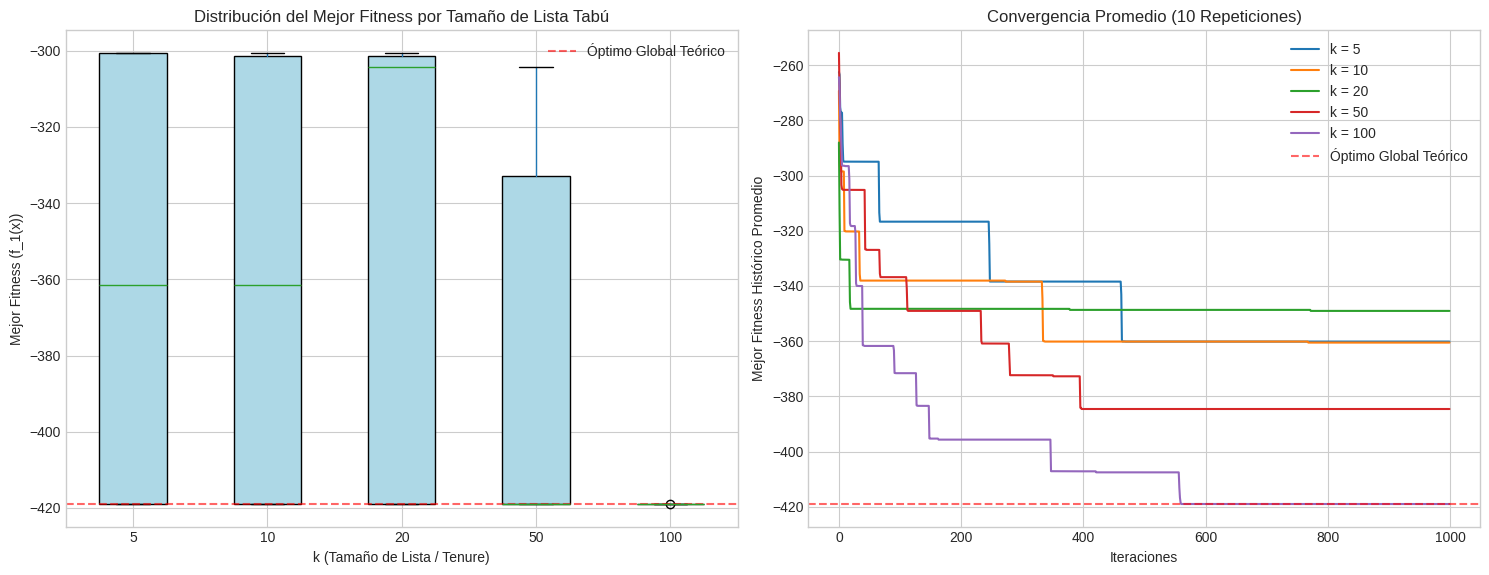

In [ ]:
tabla_stats = df_resultados.groupby('k (Tenure)')['Mejor Fitness'].agg(
    Media='mean',
    Mediana='median',
    Min='min',
    Max='max',
    Desv_Est='std'
).reset_index()

print("\n=== Tabla Estadística del Mejor Fitness ===")
print(tabla_stats.to_markdown(index=False))

tabla_metricas_extra = df_resultados.groupby('k (Tenure)')[['Iteración Mejor', 'Proporción Tabú [%]', 'Evaluaciones']].mean().reset_index()
print("\n=== Promedio de Métricas Operativas ===")
print(tabla_metricas_extra.to_markdown(index=False))

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

df_resultados.boxplot(column='Mejor Fitness', by='k (Tenure)', ax=ax1,
                      patch_artist=True, boxprops=dict(facecolor="lightblue"))
ax1.set_title('Distribución del Mejor Fitness por Tamaño de Lista Tabú')
ax1.set_xlabel('k (Tamaño de Lista / Tenure)')
ax1.set_ylabel('Mejor Fitness (f_1(x))')
ax1.axhline(-418.98, color='red', linestyle='--', alpha=0.6, label='Óptimo Global Teórico')
ax1.legend()
plt.suptitle('')

# Curvas de Convergencia Promedio
for k in k_values:
    # Calculamos el promedio de convergencia iteración a iteración (axis=0)
    convergencia_promedio = np.mean(curvas_convergencia[k], axis=0)
    ax2.plot(convergencia_promedio, label=f'k = {k}')

ax2.set_title('Convergencia Promedio (10 Repeticiones)')
ax2.set_xlabel('Iteraciones')
ax2.set_ylabel('Mejor Fitness Histórico Promedio')
ax2.axhline(-418.98, color='red', linestyle='--', alpha=0.6, label='Óptimo Global Teórico')
ax2.legend()

plt.tight_layout()
plt.show()


**Preguntas de análisis**:

1. ¿Existe un valor óptimo de $k$ o el rendimiento es insensible al tenure en este rango?

Configuración óptima en los valores más altos: $k=50$ y $k=100$. Los tenures de 50 y 100 logran una media prácticamente idéntica al óptimo global teórico ($-418.98$)

2. ¿Tenure muy pequeño ($k=5$) resulta en estancamiento por falta de diversificación?

Para $k=5$ (y también 10 y 20), el peor resultado de las repeticiones se estancó en -300 aprox, que es claramente un óptimo local. Como la memoria es tan corta, el algoritmo se olvida rapido y pierde la fuerza necesaria para salir de ese pozo.

3. ¿Tenure muy grande ($k=100$) perjudica por prohibir regiones prometedoras?

En este experimento en particular, no parece perjudicar.

4. ¿Cómo se relaciona la variabilidad de resultados con el tamaño del tenure?

Existe una relación inversa: a mayor tenure, la variabilidad baja.

5. ¿En qué momento de la ejecución típicamente se encuentra el mejor resultado para cada $k$?

Según la tabla el hallazgo del mejor fitness ocurre hacia la mitad de la ejecución en todos los tenure

#### Experimento 2: Tamaño de vecindario

> Emplee el valor de tenure identificado previamente (mantener fijo) y evalúe el impacto del tamaño del vecindario explorado en cada iteración.

**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad k = [k_{\text{óptimo}} \text{ del Exp.1}] \text{ (fijo)} \\
& \quad |N| \in \{5, 10, 20, 50, 100\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$

**Observación importante sobre el número de evaluaciones**: El número total de evaluaciones de función objetivo varía con $|N|$:
- $|N| = 5$: $1000 \times 5 = 5000$ evaluaciones totales
- $|N| = 20$: $1000 \times 20 = 20000$ evaluaciones totales
- $|N| = 100$: $1000 \times 100 = 100000$ evaluaciones totales

Esto introduce un sesgo: configuraciones con $|N|$ mayor tienen más evaluaciones totales. Para una comparación completamente justa, se debería fijar el número total de evaluaciones y ajustar el número de iteraciones correspondientemente. Sin embargo, para este experimento preliminar se mantiene fijo el número de iteraciones para observar el trade-off entre amplitud de exploración local versus número de iteraciones.

In [ ]:
k_optimo = 50
N_values = [5, 10, 20, 50, 100]
repeticiones = 10
dominio = [-512, 512]

resultados_exp2 = []
curvas_convergencia_exp2 = {n: [] for n in N_values}

for n_vecinos in N_values:
    for _ in range(repeticiones):
        res = tabu_search(f1, k_tenure=k_optimo, dominio=dominio, N_vecinos=n_vecinos)

        resultados_exp2.append({
            'N (Vecinos)': n_vecinos,
            'Mejor Fitness': res['Mejor Fitness'],
            'Posición x': res['Posición x'],
            'Iteración Mejor': res['Iteración Mejor'],
            'Evaluaciones': res['Evaluaciones'],
            'Proporción Tabú [%]': res['Proporción Tabú [%]']
        })
        curvas_convergencia_exp2[n_vecinos].append(res['Convergencia'])

df_exp2 = pd.DataFrame(resultados_exp2)


=== Tabla Estadística del Mejor Fitness (Exp 2) ===
|   N (Vecinos) |    Media |   Mediana |      Min |      Max |   Desv_Est |
|--------------:|---------:|----------:|---------:|---------:|-----------:|
|             5 | -418.968 |  -418.982 | -418.983 | -418.889 |  0.0289506 |
|            10 | -407.506 |  -418.983 | -418.983 | -304.229 | 36.2878    |
|            20 | -396.032 |  -418.983 | -418.983 | -304.229 | 48.3839    |
|            50 | -350.131 |  -304.229 | -418.983 | -304.229 | 59.2582    |
|           100 | -373.081 |  -418.982 | -418.983 | -304.229 | 59.2583    |

=== Promedio de Métricas Operativas (Exp 2) ===
|   N (Vecinos) |   Iteración Mejor |   Proporción Tabú [%] |   Evaluaciones |
|--------------:|------------------:|----------------------:|---------------:|
|             5 |             467.5 |                24.458 |           5001 |
|            10 |             516.2 |                32.222 |          10001 |
|            20 |             225.6 |             

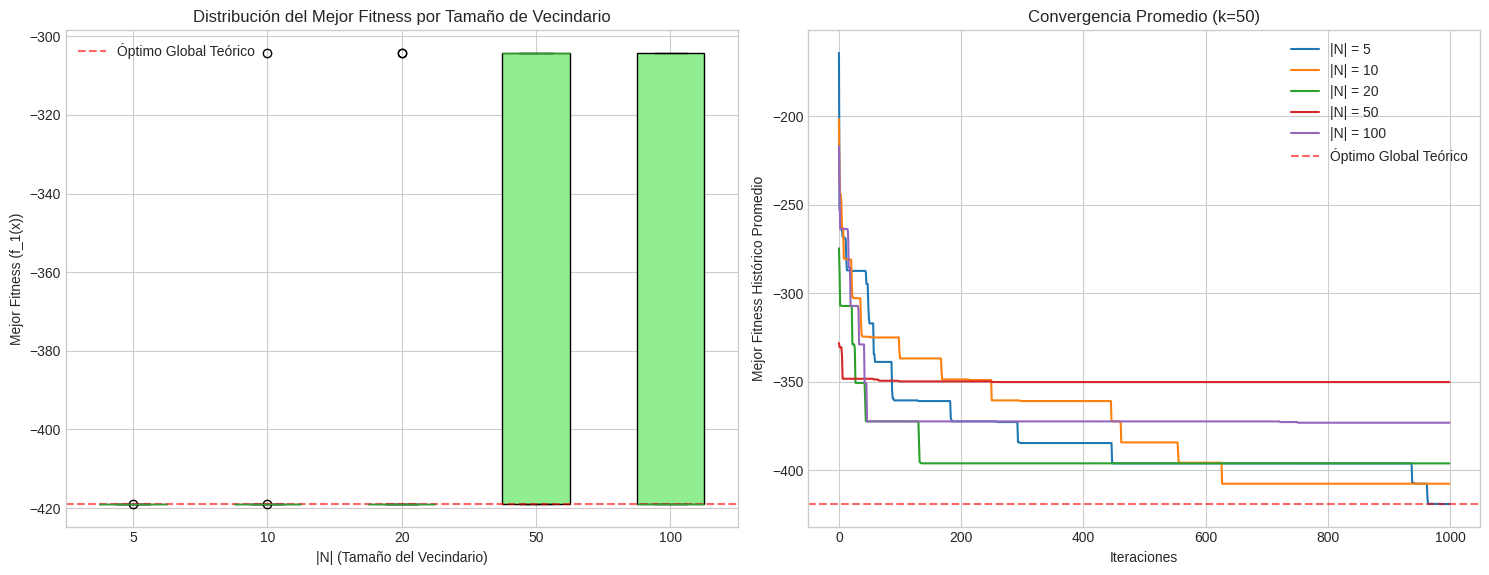

In [ ]:
tabla_stats_exp2 = df_exp2.groupby('N (Vecinos)')['Mejor Fitness'].agg(
    Media='mean',
    Mediana='median',
    Min='min',
    Max='max',
    Desv_Est='std'
).reset_index()

print("\n=== Tabla Estadística del Mejor Fitness (Exp 2) ===")
print(tabla_stats_exp2.to_markdown(index=False))

tabla_metricas_exp2 = df_exp2.groupby('N (Vecinos)')[['Iteración Mejor', 'Proporción Tabú [%]', 'Evaluaciones']].mean().reset_index()
print("\n=== Promedio de Métricas Operativas (Exp 2) ===")
print(tabla_metricas_exp2.to_markdown(index=False))

# --- 2. Generación de Gráficos ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
df_exp2.boxplot(column='Mejor Fitness', by='N (Vecinos)', ax=ax1,
                patch_artist=True, boxprops=dict(facecolor="lightgreen"))
ax1.set_title('Distribución del Mejor Fitness por Tamaño de Vecindario')
ax1.set_xlabel('|N| (Tamaño del Vecindario)')
ax1.set_ylabel('Mejor Fitness (f_1(x))')
ax1.axhline(-418.98, color='red', linestyle='--', alpha=0.6, label='Óptimo Global Teórico')
ax1.legend()
plt.suptitle('')

# Curvas de Convergencia
for n_vecinos in N_values:
    convergencia_promedio = np.mean(curvas_convergencia_exp2[n_vecinos], axis=0)
    ax2.plot(convergencia_promedio, label=f'|N| = {n_vecinos}')

ax2.set_title(f'Convergencia Promedio (k={k_optimo})')
ax2.set_xlabel('Iteraciones')
ax2.set_ylabel('Mejor Fitness Histórico Promedio')
ax2.axhline(-418.98, color='red', linestyle='--', alpha=0.6, label='Óptimo Global Teórico')
ax2.legend()

plt.tight_layout()
plt.show()


**Preguntas de análisis**:

1. ¿Mayor $|N|$ siempre resulta en mejor rendimiento, o existe un punto de rendimientos decrecientes?

En este caso particular, ¡ocurre exactamente lo contrario! Mayor $|N|$ resultó en un rendimiento mucho peor.

Esto pasa por que muchísimos vecinos (ej. 100) alrededor de tu punto actual, el algoritmo se vuelve excesivamente greedy. Encuentra el fondo del pozo local con tanta precisión que se queda atrapado. Al tener tantos vecinos disponibles, siempre encuentra alguno que no es tabú pero que sigue estando en el fondo del valle, entonces nunca logra salir ya que no sube la montaña. Con un $|N|$ pequeño (ej. 5), las opciones son tan pocas que el algoritmo se ve obligado a elegir pasos "malos" hacia arriba de la colina, lo que paradójicamente lo ayuda a escapar del pozo.

2. ¿Cómo afecta $|N|$ al tiempo de ejecución?

Lo afecta de manera directa y lineal, evaluaciones = N_vecinos elegidos x 1000

3. ¿El $|N|$ óptimo depende del valor de $k$ elegido?



4. ¿Explorar vecindarios muy grandes ($|N|=100$) en cada iteración es computacionalmente justificable?

Basado en este experimento no.


### 2.3 Aplicación a la función 2D

Los experimentos previos en la función unidimensional de Schwefel han permitido identificar configuraciones óptimas de los hiperparámetros $k$ (tenure) y $|N|$ (tamaño de vecindario) para *Tabu Search*. En esta sección se aplicará el algoritmo a la función $f_2(x,y)$, adaptando la implementación al espacio bidimensional y evaluando el impacto de los hiperparámetros en un paisaje de fitness con estructura radial y alta multimodalidad.

#### Adaptaciones necesarias para 2D

**Operador de vecindario bidimensional**: La generación de vecinos en $\mathbb{R}^2$ se realiza mediante perturbación Gaussiana independiente en cada dimensión. Para cada iteración, se generan $|N|$ vecinos candidatos:

$$\begin{pmatrix} x'_i \\ y'_i \end{pmatrix} = \begin{pmatrix} x \\ y \end{pmatrix} + \begin{pmatrix} \delta_{x,i} \\ \delta_{y,i} \end{pmatrix}, \quad \delta_{x,i}, \delta_{y,i} \sim \mathcal{N}(0, \sigma^2), \quad i = 1, \ldots, |N|$$

donde $\sigma$ es la desviación estándar que controla el tamaño del paso de búsqueda. Un valor apropiado inicial para la función $f_2(x,y)$ con dominio $[-100, 100]^2$, es $\sigma = 10.0$, consistente con el valor empleado en *Simulated Annealing*. Este valor permite exploración efectiva del espacio sin generar pasos excesivamente grandes que dificulten la convergencia.

**Manejo de restricciones del dominio**: Cuando la perturbación genera un candidato $(x'_i, y'_i)$ que viola las restricciones del dominio, se aplica la estrategia de **proyección al borde**: si $x'_i < -100$ se fija $x'_i = -100$, si $x'_i > 100$ se fija $x'_i = 100$, y análogamente para $y'_i$. Esto garantiza que todos los candidatos evaluados sean factibles.

**Representación de la lista tabú en 2D**: La lista tabú almacena puntos $(x, y)$ recientemente visitados. Dado que trabajamos con números reales de punto flotante, dos soluciones se consideran equivalentes si su distancia euclidiana es menor que una tolerancia $\varepsilon$:

$$\text{is\_tabu}((x', y')) = \exists (x_t, y_t) \in \text{TabuList} : \sqrt{(x' - x_t)^2 + (y' - y_t)^2} < \varepsilon$$

Para la función $f_2(x,y)$, se empleará $\varepsilon = 1.0$ como criterio de proximidad, representando aproximadamente el 1% del rango del dominio.


**Visualización en 2D**:

- **Gráfico de contorno** (contour plot) de $f_2(x,y)$ en el dominio $[-100,100]^2$ como referencia estática de fondo
- **Soluciones tabú**: marcadores semi-transparentes en color mostrando las posiciones actualmente en la lista tabú, permitiendo visualizar qué regiones están temporalmente prohibidas
- **Posición actual**: marcador de color que muestra la ubicación de la solución actual $(x_{\text{current}}, y_{\text{current}})$
- **Mejor posición**: marcador de color en forma de estrella que indica $(x_{\text{best}}, y_{\text{best}})$
- **Óptimo global conocido**: marcador negro en el origen $(0, 0)$ para referencia

Esta visualización permite observar cómo la memoria explícita de Tabu Search moldea la trayectoria de búsqueda en el paisaje radial, y evaluar si el algoritmo logra aproximarse sistemáticamente al óptimo global.

In [ ]:
def f2(v):
    x, y = v[0], v[1]
    r2 = x**2 + y**2
    # Evitar posibles errores de división/potencia en el origen exacto (0,0)
    if r2 == 0:
        return 0.0

    # f2(x,y) = (x^2 + y^2)^0.25 * [sin^2(50 * (x^2 + y^2)^0.1) + 1]
    term1 = r2**0.25
    term2 = (np.sin(50 * (r2**0.1)))**2 + 1
    return term1 * term2

In [ ]:
def tabu_search_2D(f_objetivo, k_tenure, dominio, N_vecinos, N_max=2000, sigma=10.0, tabu_tol=1.0):
    x_actual = np.random.uniform(dominio[0], dominio[1], size=2)
    f_actual = f_objetivo(x_actual)

    x_best = x_actual.copy()
    f_best = f_actual

    tabu_list = []

    # Listas para guardar el historial
    tabu_ratios = []

    #convergence = []

    convergence = [f_best]

    for iteration in range(N_max):
        vecinos = x_actual + np.random.normal(0, sigma, (N_vecinos, 2))
        vecinos = np.clip(vecinos, dominio[0], dominio[1])

        f_vecinos = np.array([f_objetivo(v) for v in vecinos])

        vecino_es_tabu = np.zeros(N_vecinos, dtype=bool)
        if len(tabu_list) > 0:
            tabu_array = np.array(tabu_list)
            for i, v in enumerate(vecinos):
                distancias = np.linalg.norm(tabu_array - v, axis=1)
                if np.any(distancias < tabu_tol):
                    vecino_es_tabu[i] = True

        tabu_ratios.append(np.mean(vecino_es_tabu))

        mejor_vecino_idx = -1
        mejor_vecino_f = float('inf')
        for i in range(N_vecinos):
            if not vecino_es_tabu[i]:
                if f_vecinos[i] < mejor_vecino_f:
                    mejor_vecino_f = f_vecinos[i]
                    mejor_vecino_idx = i

        if mejor_vecino_idx == -1:
            mejor_vecino_idx = np.argmin(f_vecinos)
            mejor_vecino_f = f_vecinos[mejor_vecino_idx]

        x_actual = vecinos[mejor_vecino_idx].copy()
        f_actual = mejor_vecino_f

        tabu_list.append(x_actual.copy())
        if len(tabu_list) > k_tenure:
            tabu_list.pop(0)

        if f_actual < f_best:
            f_best = f_actual
            x_best = x_actual.copy()

        # Guardamos la convergencia en cada iteración
        convergence.append(f_best)

    distancia_optimo = np.linalg.norm(x_best)

    return {
        'k': k_tenure,
        'Mejor Fitness': f_best,
        'Posición X': x_best[0],
        'Posición Y': x_best[1],
        'Dist. promedio': distancia_optimo,
        '% Tabú': np.mean(tabu_ratios) * 100,
        'Convergencia': convergence
    }

#### Experimento 1: Calibración del tamaño de lista tabú (tenure) en 2D

El primer paso es determinar si el tenure óptimo identificado en Schwefel 1D es apropiado para la función de Oscilación Radial, considerando que el espacio de búsqueda bidimensional presenta mayor complejidad y un número mayor de regiones locales que pueden ser visitadas.

**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_2(x,y) = (x^{2} + y^{2})^{0.25} \cdot [\sin^{2}(50 \cdot (x^{2} + y^{2})^{0.1}) + 1] \\
\text{Dominio:} & \quad (x,y) \in [-100, 100]^2 \\
\text{Hiperparámetros:} & \quad k \in \{5, 10, 20, 50, 100\} \\
& \quad |N| = [|N|_{\text{óptimo}} \text{ de Exp. 2.3.2}] \text{ (fijo)} \\
& \quad \sigma = 10.0 \text{ (desviación estándar de perturbación)} \\
& \quad \varepsilon = 1.0 \text{ (tolerancia para comparación tabú)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 2000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } k \\
\text{Inicialización:} & \quad (x_0, y_0) \text{ aleatorio uniforme en } [-100, 100]^2
\end{aligned}
$$

**Justificación del rango de tenure**:
- $k = 5$: memoria muy corta, permite revisitar regiones rápidamente, riesgo de ciclos
- $k = 20$: memoria intermedia, balance típico en literatura
- $k = 50$: memoria larga, fuerte diversificación
- $k = 100$: memoria muy larga, riesgo de excesiva prohibición de regiones prometedoras

En 2D, el espacio de búsqueda es considerablemente más amplio que en 1D, lo que podría requerir tenures más largos para evitar ciclos efectivamente. Sin embargo, tenures excesivos pueden prohibir prematuramente regiones cercanas al óptimo global.


**Métricas a registrar** (para cada una de las 10 repeticiones de cada configuración):

1. **Mejor fitness alcanzado**: $f_2(x_{\text{best}}, y_{\text{best}})$
2. **Posición de la mejor solución**: $(x_{\text{best}}, y_{\text{best}})$
3. **Distancia euclidiana al óptimo global**: $d = \sqrt{x_{\text{best}}^2 + y_{\text{best}}^2}$
4. **Iteración en que se encontró el mejor**: $t_{\text{best}}$
6. **Número total de evaluaciones**: $N_{\text{max}} \times |N|$ (debería ser constante)
7. **Proporción promedio de vecinos tabú**: fracción del vecindario generado que fue rechazado por estar en la lista tabú

> Para cada valor de $k$, calcular sobre las 10 repeticiones:
> - Media aritmética de $f_{\text{best}}$
> - Mediana, mínimo y máximo de $f_{\text{best}}$
> - Desviación estándar
> - Media de la distancia al óptimo $\bar{d}$
> - Proporción promedio de vecinos tabú
> Presentar los resultados en una **tabla comparativa**:



| $k$ | Media | Mediana | Mín | Máx | Dist. promedio | % Tabú |
|-----|:-----:|---------|-----|-----|----------------|--------|
| 5   | ...   | ...     | ... | ... | ...            | ...    |
| 10  | ...   | ...     | ... | ... | ...            | ...    |
| 20  | ...   | ...     | ... | ... | ...            | ...    |
| 50  | ...   | ...     | ... | ... | ...            | ...    |
| 100 | ...   | ...     | ... | ... | ...            | ...    |



> Adicionalmente, generar visualizaciones complementarias:
> 1. **Boxplot comparativo**: Un gráfico de boxplot que muestre, para cada valor de $k$, la distribución de los mejores fitness alcanzados.
> 2. **Scatter plot de posiciones finales**: Sobre un contour plot de la función, marcar las 10 posiciones finales $(x_{\text{best}}, y_{\text{best}})$ de cada configuración con diferentes colores. Incluir un círculo en el origen y círculos concéntricos a distancias 10, 25, 50 como referencia visual. Opcionalmente, puede utilizar una proyección superior de la función $f_2(x,y)$ para ubicar los puntos.
> 3. **Gráfico de convergencia promedio**: Para cada $k$, graficar la evolución del fitness promedio (promediado sobre las 10 repeticiones) vs iteración.
> 4. **Proporción de vecinos tabú vs tenure**: Gráfico de barras mostrando el porcentaje promedio de vecinos rechazados para cada valor de $k$, permitiendo cuantificar el efecto de diversificación.


In [ ]:
k_values = [5, 10, 20, 50, 100]
N_optimo = 5
N_max = 2000
repeticiones = 10
dominio = [-100, 100]

resultados_completos = []
curvas_convergencia_2d = {k: [] for k in k_values}

for k in k_values:
    for _ in range(repeticiones):
        res = tabu_search_2D(f2, k, dominio, N_optimo, N_max)

        # Guardamos los datos planos
        resultados_completos.append({
            'k': res['k'],
            'Mejor Fitness': res['Mejor Fitness'],
            'Posición X': res['Posición X'],
            'Posición Y': res['Posición Y'],
            'Dist. promedio': res['Dist. promedio'],
            '% Tabú': res['% Tabú']
        })
        # Guardamos la curva de convergencia aparte para graficar fácil
        curvas_convergencia_2d[k].append(res['Convergencia'])

df_final = pd.DataFrame(resultados_completos)


=== Tabla Comparativa de Resultados ===
|   k |    Media |   Mediana |      Mín |      Máx |   Dist. promedio |   % Tabú |
|----:|---------:|----------:|---------:|---------:|-----------------:|---------:|
|   5 | 0.453024 |  0.435252 | 0.147421 | 0.719264 |         0.160192 |    1.47  |
|  10 | 0.570714 |  0.574403 | 0.340408 | 0.770688 |         0.240706 |    2.581 |
|  20 | 0.485657 |  0.479327 | 0.288632 | 0.705499 |         0.181636 |    4.279 |
|  50 | 0.674646 |  0.654182 | 0.496492 | 0.856176 |         0.262493 |    8.276 |
| 100 | 0.550517 |  0.532879 | 0.234739 | 0.861971 |         0.271598 |   12.392 |


<Figure size 1000x600 with 0 Axes>

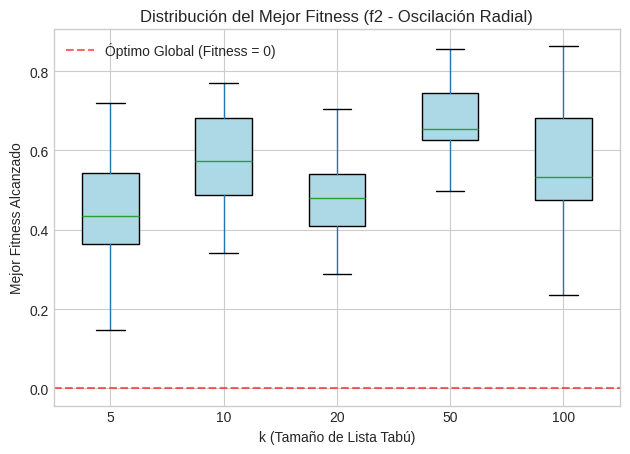

In [ ]:
tabla_resumen = df_final.groupby('k').agg(
    Media=('Mejor Fitness', 'mean'),
    Mediana=('Mejor Fitness', 'median'),
    Mín=('Mejor Fitness', 'min'),
    Máx=('Mejor Fitness', 'max'),
    Dist_promedio=('Dist. promedio', 'mean'),
    Porc_Tabu=('% Tabú', 'mean')
).reset_index()

# Renombrar columnas para igualar el Markdown del anexo
tabla_resumen.columns = ['k', 'Media', 'Mediana', 'Mín', 'Máx', 'Dist. promedio', '% Tabú']

print("\n=== Tabla Comparativa de Resultados ===")
print(tabla_resumen.to_markdown(index=False))

# 5. GRÁFICO 1: Boxplot Comparativo
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

df_final.boxplot(column='Mejor Fitness', by='k',
                      patch_artist=True, boxprops=dict(facecolor="lightblue"))

plt.title('Distribución del Mejor Fitness (f2 - Oscilación Radial)')
plt.xlabel('k (Tamaño de Lista Tabú)')
plt.ylabel('Mejor Fitness Alcanzado')
plt.suptitle('') # Limpiamos subtítulos automáticos de Pandas
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Óptimo Global (Fitness = 0)')
plt.legend()

plt.tight_layout()
plt.show()

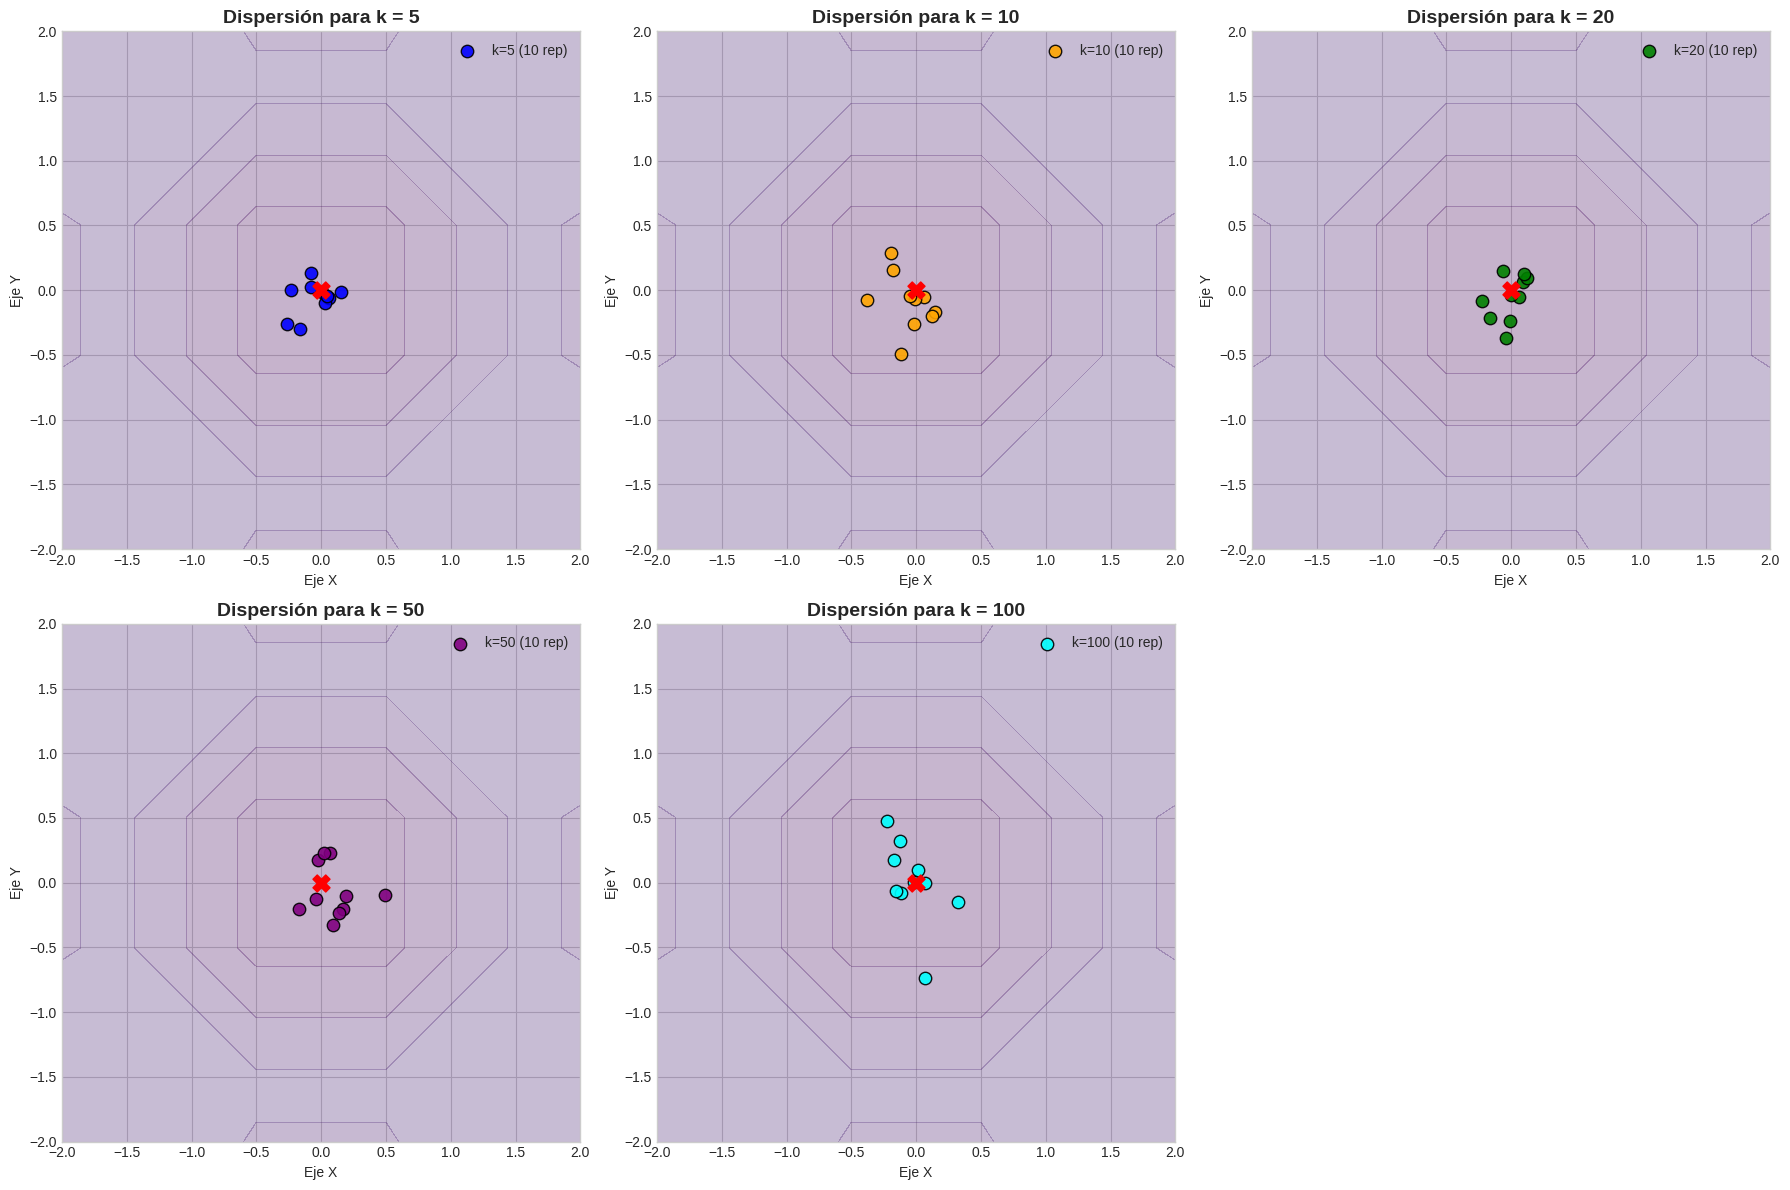

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Aplanamos el arreglo de ejes para iterar más fácil

# 1. Grilla para el fondo (Bajé un poco la resolución a 200 para que cargue más rápido en 5 paneles)
x_val = np.linspace(-100, 100, 200)
y_val = np.linspace(-100, 100, 200)
X, Y = np.meshgrid(x_val, y_val)

R2 = X**2 + Y**2
Z = (R2**0.25) * ((np.sin(50 * (R2**0.1)))**2 + 1)

colores = ['blue', 'orange', 'green', 'purple', 'cyan']
k_values = [5, 10, 20, 50, 100]

for idx, (k, color) in enumerate(zip(k_values, colores)):
    ax = axes[idx]

    # Dibujar el contour en este panel
    ax.contourf(X, Y, Z, levels=40, cmap='viridis', alpha=0.3)

    # Dibujar círculos concéntricos
    theta = np.linspace(0, 2*np.pi, 100)
    for r in [10, 25, 50]:
        ax.plot(r*np.cos(theta), r*np.sin(theta), color='black', linestyle='--', alpha=0.4)

    # Marcar el Óptimo Global
    ax.scatter(0, 0, color='red', marker='X', s=150, zorder=10)

    # Puntos SOLO para este valor de k
    datos_k = df_final[df_final['k'] == k]
    ax.scatter(datos_k['Posición X'], datos_k['Posición Y'],
               color=color, edgecolors='black', s=80, alpha=0.9,
               zorder=5, label=f'k={k} (10 rep)')

    ax.set_title(f'Dispersión para k = {k}', fontsize=14, fontweight='bold')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.legend(loc='upper right')

# Como tenemos 5 valores de k y 6 espacios (2x3), ocultamos el último panel que queda vacío
axes[5].axis('off')

plt.tight_layout()
plt.show()

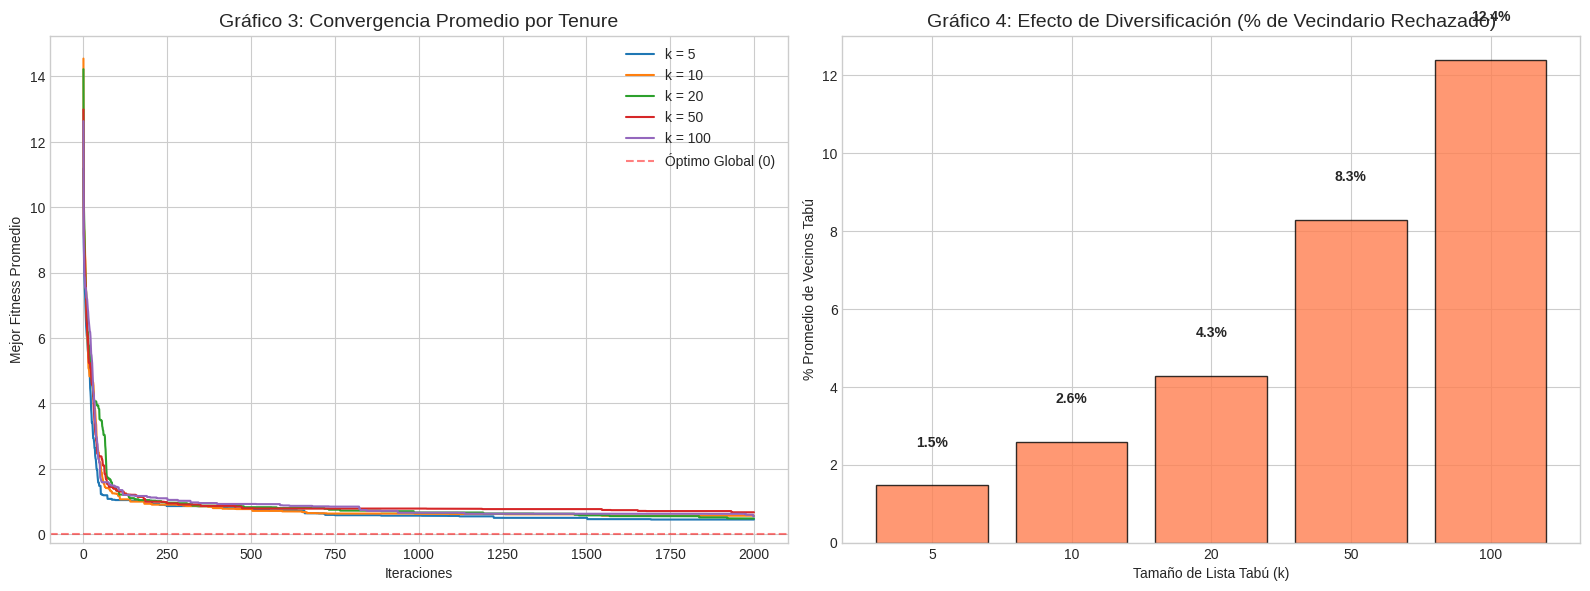

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Convergencia Promedio
for k in k_values:
    # Calculamos el promedio de las 10 repeticiones, iteración a iteración
    convergencia_promedio = np.mean(curvas_convergencia_2d[k], axis=0)
    ax1.plot(convergencia_promedio, label=f'k = {k}', linewidth=1.5)

ax1.set_title('Gráfico 3: Convergencia Promedio por Tenure', fontsize=14)
ax1.set_xlabel('Iteraciones')
ax1.set_ylabel('Mejor Fitness Promedio')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5, label='Óptimo Global (0)')
ax1.legend()

# Proporción de vecinos tabú vs tenure (Barras)
# Agrupamos por k y sacamos el promedio del porcentaje tabú
datos_barras = df_final.groupby('k')['% Tabú'].mean()

ax2.bar(datos_barras.index.astype(str), datos_barras.values, color='coral', edgecolor='black', alpha=0.8)
ax2.set_title('Gráfico 4: Efecto de Diversificación (% de Vecindario Rechazado)', fontsize=14)
ax2.set_xlabel('Tamaño de Lista Tabú (k)')
ax2.set_ylabel('% Promedio de Vecinos Tabú')

# Le agregamos el numerito exacto arriba de cada barra para que quede más prolijo
for i, valor in enumerate(datos_barras.values):
    ax2.text(i, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Preguntas de análisis**:

1. ¿Qué valor de $k$ produce el mejor rendimiento promedio en términos de fitness alcanzado?
2. ¿El tenure óptimo en 2D coincide con el identificado en Schwefel 1D, o requiere ajuste? ¿El espacio 2D requiere memoria más larga?
3. ¿Cómo se relaciona la proporción de vecinos tabú con la calidad de las soluciones finales? ¿Mayor prohibición mejora o perjudica el rendimiento?
4. ¿Tenures muy pequeños ($k = 5$) resultan en ciclos observables en las visualizaciones? ¿Tenures muy grandes ($k = 100$) impiden acercarse al óptimo?
5. ¿Cuántas de las 10 repeticiones de cada configuración logran encontrar soluciones dentro de un radio $d < 10$ del óptimo?

#### Experimento 2: Calibración del tamaño de vecindario en 2D

El tamaño del vecindario $|N|$ determina cuán exhaustivamente se explora el entorno local de la solución actual en cada iteración. En problemas 2D, un vecindario más amplio puede ser necesario para capturar adecuadamente la estructura del paisaje, pero incrementa proporcionalmente el costo computacional por iteración.


**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad k = [k_{\text{óptimo}} \text{ del Exp. 1}] \text{ (fijo)} \\
& \quad |N| \in \{10, 20, 30, 50, 100\} \\
& \quad \sigma = 10.0 \text{ (fijo)} \\
& \quad \varepsilon = 1.0 \text{ (fijo)} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$


**Justificación del rango de $|N|$**:
- $|N| = 10$: exploración local limitada, pocas opciones por iteración
- $|N| = 30$: exploración moderada, balance razonable
- $|N| = 100$: exploración exhaustiva del entorno local, alto costo computacional

**Observación crítica sobre presupuesto computacional**: A diferencia del Experimento 1 donde el número total de evaluaciones era constante, aquí varía con $|N|$:

- $|N| = 10$: $2000 \times 10 = 20{,}000$ evaluaciones totales
- $|N| = 50$: $2000 \times 50 = 100{,}000$ evaluaciones totales
- $|N| = 100$: $2000 \times 100 = 200{,}000$ evaluaciones totales

Esta variación introduce un sesgo: configuraciones con mayor $|N|$ tienen más evaluaciones disponibles. Sin embargo, este experimento busca evaluar el trade-off entre amplitud de exploración local versus número de iteraciones, por lo que se mantiene fijo $N_{\text{max}}$ en lugar del presupuesto total.


> Aplicar el mismo protocolo estadístico del Experimento 1, prestando especial atención a:
> - **Relación costo-beneficio**: ¿El incremento en calidad de soluciones justifica el incremento en evaluaciones?
> - **Tiempo de ejecución**: ¿Cómo escala el tiempo con $|N|$?
> - **Proporción de vecinos tabú**: ¿Vecindarios grandes resultan en mayor o menor proporción de candidatos prohibidos?
> Adicionalmente, para cada valor de $|N|$, calcular:
> - **Número promedio de mejoras por iteración**: frecuencia con que se actualiza $f_{\text{best}}$
> - **Eficiencia computacional**: calidad de solución alcanzada por cada 10000 evaluaciones (puede construir un gráfico de barras mostrando los valores calculados, comparando para los distintos $|N|$ analizados)


In [ ]:
import time

k_optimo = 50
N_values = [10, 20, 30, 50, 100]
N_max = 2000
repeticiones = 10
dominio = [-100, 100]

resultados_exp2 = []

for n_vecinos in N_values:

    # Variables para promediar tiempos (opcional pero útil para tu análisis)
    start_time = time.time()

    for _ in range(repeticiones):
        # USAMOS LA MISMA FUNCIÓN INTACTA
        res = tabu_search_2D(f2, k_optimo, dominio, n_vecinos, N_max)

        # 1. Contamos cuántas veces mejoró el fitness revisando la 'Convergencia'
        convergencia = res['Convergencia']
        mejoras_totales = sum(1 for i in range(1, len(convergencia)) if convergencia[i] < convergencia[i-1])
        promedio_mejoras_iter = mejoras_totales / N_max

        # 2. Eficiencia Computacional (Fitness logrado cada 10,000 evaluaciones)
        evaluaciones_totales = N_max * n_vecinos
        # Como buscamos minimizar (llegar a 0), un valor más bajo es mejor.
        # Dividimos el fitness final por la cantidad de "bloques de 10k" evaluaciones que gastó
        bloques_10k = evaluaciones_totales / 10000
        eficiencia = res['Mejor Fitness'] / bloques_10k

        resultados_exp2.append({
            '|N|': n_vecinos,
            'Mejor Fitness': res['Mejor Fitness'],
            'Dist. promedio': res['Dist. promedio'],
            '% Tabú': res['% Tabú'],
            'Mejoras por Iter': promedio_mejoras_iter,
            'Eficiencia (Fit/10k evals)': eficiencia,
            'Evaluaciones': evaluaciones_totales
        })

    tiempo_total = time.time() - start_time
    print(f"  -> Tiempo para 10 repeticiones con |N| = {n_vecinos}: {tiempo_total:.2f} segundos")

df_exp2 = pd.DataFrame(resultados_exp2)

  -> Tiempo para 10 repeticiones con |N| = 10: 3.91 segundos
  -> Tiempo para 10 repeticiones con |N| = 20: 6.51 segundos
  -> Tiempo para 10 repeticiones con |N| = 30: 10.01 segundos
  -> Tiempo para 10 repeticiones con |N| = 50: 15.99 segundos
  -> Tiempo para 10 repeticiones con |N| = 100: 31.41 segundos



=== Tabla Comparativa: Impacto del Tamaño de Vecindario (|N|) ===
|   |N| |    Media |   Mediana |      Mín |      Máx |   Dist_promedio |   Porc_Tabu |   Mejoras_Iter |   Eficiencia |
|------:|---------:|----------:|---------:|---------:|----------------:|------------:|---------------:|-------------:|
|    10 | 0.49602  |  0.418396 | 0.313159 | 0.757359 |       0.232732  |     12.1485 |        0.00615 |    0.24801   |
|    20 | 0.466329 |  0.482169 | 0.320401 | 0.620208 |       0.200443  |     14.4433 |        0.00565 |    0.116582  |
|    30 | 0.442848 |  0.414527 | 0.241375 | 0.688219 |       0.15836   |     14.9755 |        0.00545 |    0.073808  |
|    50 | 0.443316 |  0.400511 | 0.100512 | 0.678366 |       0.155197  |     15.3124 |        0.0054  |    0.0443316 |
|   100 | 0.363134 |  0.370849 | 0.242551 | 0.476707 |       0.0879455 |     15.2341 |        0.00505 |    0.0181567 |


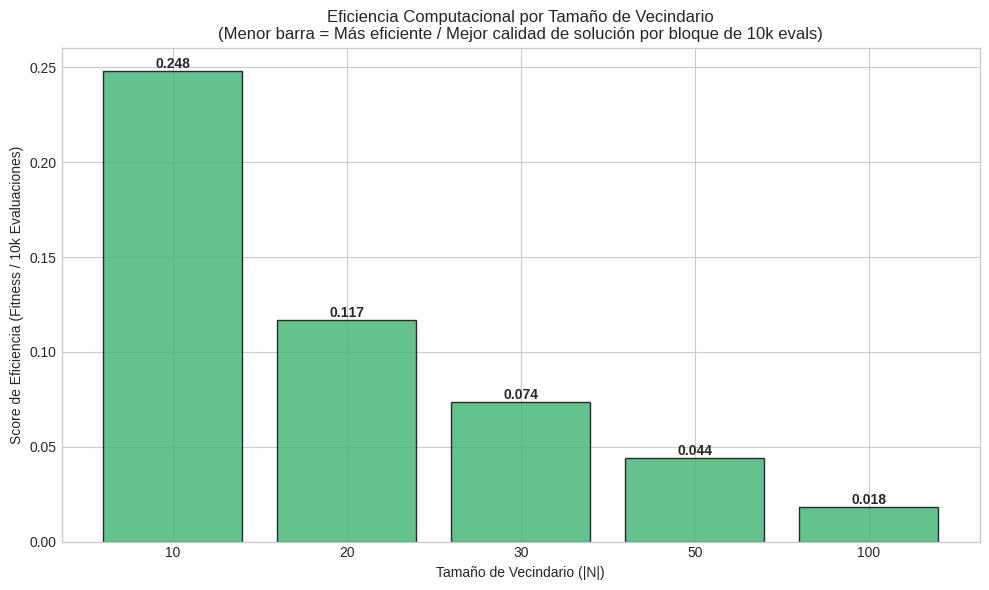

In [ ]:
tabla_resumen_exp2 = df_exp2.groupby('|N|').agg(
    Media=('Mejor Fitness', 'mean'),
    Mediana=('Mejor Fitness', 'median'),
    Mín=('Mejor Fitness', 'min'),
    Máx=('Mejor Fitness', 'max'),
    Dist_promedio=('Dist. promedio', 'mean'),
    Porc_Tabu=('% Tabú', 'mean'),
    Mejoras_Iter=('Mejoras por Iter', 'mean'),
    Eficiencia=('Eficiencia (Fit/10k evals)', 'mean')
).reset_index()

print("\n=== Tabla Comparativa: Impacto del Tamaño de Vecindario (|N|) ===")
print(tabla_resumen_exp2.to_markdown(index=False))

# --- GRÁFICO DE BARRAS: Eficiencia Computacional ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Agrupamos por N y sacamos el promedio de la eficiencia
datos_eficiencia = df_exp2.groupby('|N|')['Eficiencia (Fit/10k evals)'].mean()

# ATENCIÓN: Como es minimización, barras más bajas significan MEJOR eficiencia
# (Llegó a un fitness más cercano a 0 gastando la misma cantidad relativa de cómputo)
barras = plt.bar(datos_eficiencia.index.astype(str), datos_eficiencia.values, color='mediumseagreen', edgecolor='black', alpha=0.8)

plt.title('Eficiencia Computacional por Tamaño de Vecindario\n(Menor barra = Más eficiente / Mejor calidad de solución por bloque de 10k evals)')
plt.xlabel('Tamaño de Vecindario (|N|)')
plt.ylabel('Score de Eficiencia (Fitness / 10k Evaluaciones)')

# Etiquetas arriba de las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Preguntas de análisis**:
1. ¿Qué valor de $|N|$ produce el mejor balance entre calidad de soluciones y costo computacional?
2. ¿Existe un punto de rendimientos decrecientes donde incrementar $|N|$ no mejora sustancialmente los resultados?
3. ¿Cómo interactúa $|N|$ con el tenure $k$? ¿Vecindarios grandes requieren tenures diferentes?
4. Observando el tiempo de ejecución, ¿es práctico usar $|N| = 100$ considerando el beneficio marginal obtenido?
5. Comparando con el Experimento 2.3.2 en Schwefel 1D, ¿el tamaño de vecindario óptimo es diferente en 2D?

#### Experimento 3: Impacto de la tolerancia de proximidad ($\varepsilon$)

El parámetro $\varepsilon$ determina cuán estricta es la comparación de proximidad al verificar si un candidato está en la lista tabú. Un $\varepsilon$ muy pequeño puede permitir que soluciones muy cercanas (pero no idénticas) sean consideradas diferentes, potencialmente causando ciclos. Un $\varepsilon$ muy grande puede prohibir excesivamente regiones amplias alrededor de cada punto tabú.


**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad k = [k_{\text{óptimo}} \text{ del Exp. 1}] \text{ (fijo)} \\
& \quad |N| = [|N|_{\text{óptimo}} \text{ del Exp. 2}] \text{ (fijo)} \\
& \quad \sigma = 10.0 \text{ (fijo)} \\
& \quad \varepsilon \in \{0.1, 0.5, 1.0, 2.0, 5.0\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$



**Justificación del rango de $\varepsilon$**:
- $\varepsilon = 0.1$: tolerancia muy estricta, solo puntos casi idénticos son considerados tabú
- $\varepsilon = 1.0$: tolerancia moderada (~1% del dominio)
- $\varepsilon = 5.0$: tolerancia amplia (~5% del dominio), prohibición de regiones grandes


> Aplicar el mismo protocolo estadístico que el los experimentos anteriores.

In [ ]:
k_optimo = 50
N_optimo = 30
epsilon_values = [0.1, 0.5, 1.0, 2.0, 5.0]
N_max = 2000
repeticiones = 10
dominio = [-100, 100]

resultados_exp3 = []

for eps in epsilon_values:
    for _ in range(repeticiones):
        # Pasamos eps al parámetro tabu_tol de tu función
        res = tabu_search_2D(f2, k_optimo, dominio, N_optimo, N_max, tabu_tol=eps)

        resultados_exp3.append({
            'Epsilon': eps,
            'Mejor Fitness': res['Mejor Fitness'],
            'Dist. promedio': res['Dist. promedio'],
            '% Tabú': res['% Tabú']
        })

df_exp3 = pd.DataFrame(resultados_exp3)


=== Tabla Comparativa: Impacto de Tolerancia (Epsilon) ===
|   Epsilon |    Media |   Mediana |      Mín |      Máx |   Dist_promedio |   Porc_Tabu |
|----------:|---------:|----------:|---------:|---------:|----------------:|------------:|
|       0.1 | 0.272226 |  0.259431 | 0.171749 | 0.401424 |       0.0577874 |    0.220667 |
|       0.5 | 0.410591 |  0.373909 | 0.316694 | 0.589398 |       0.129291  |    4.77017  |
|       1   | 0.441355 |  0.41671  | 0.279633 | 0.734217 |       0.194632  |   15.0067   |
|       2   | 0.649558 |  0.649128 | 0.428644 | 0.863109 |       0.319374  |   35.581    |
|       5   | 0.868319 |  0.843658 | 0.664441 | 1.36896  |       0.578514  |   57.7192   |


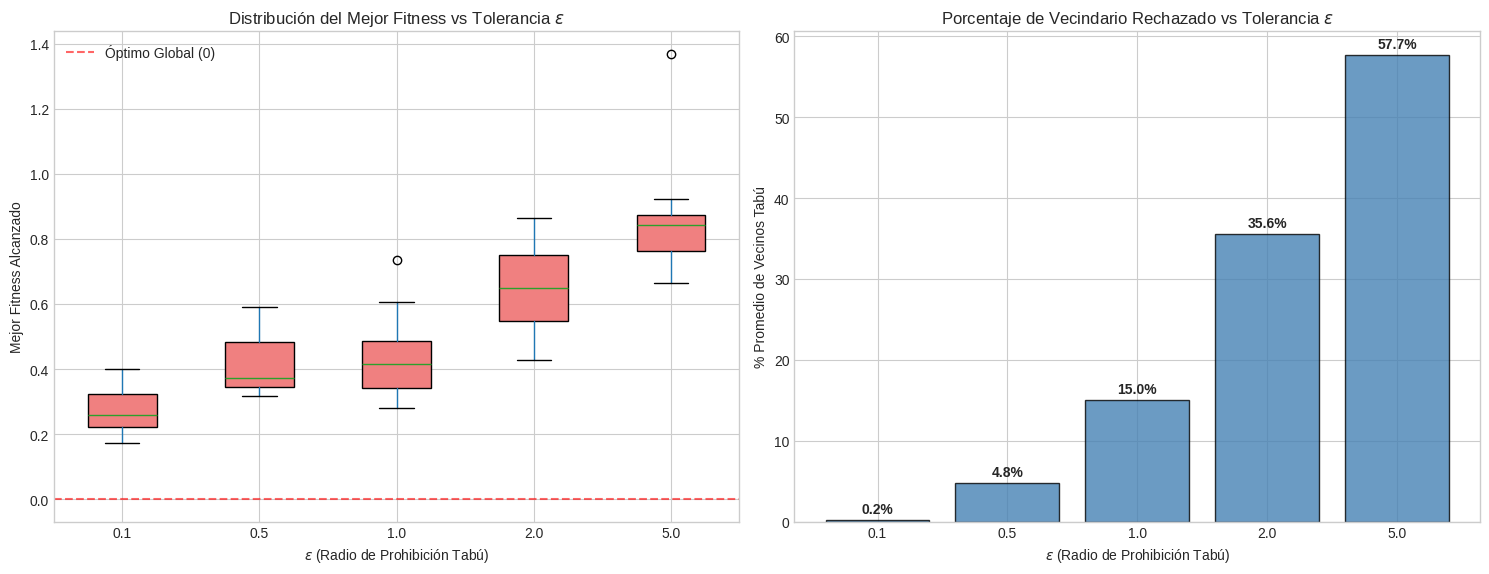

In [ ]:
tabla_resumen_exp3 = df_exp3.groupby('Epsilon').agg(
    Media=('Mejor Fitness', 'mean'),
    Mediana=('Mejor Fitness', 'median'),
    Mín=('Mejor Fitness', 'min'),
    Máx=('Mejor Fitness', 'max'),
    Dist_promedio=('Dist. promedio', 'mean'),
    Porc_Tabu=('% Tabú', 'mean')
).reset_index()

print("\n=== Tabla Comparativa: Impacto de Tolerancia (Epsilon) ===")
print(tabla_resumen_exp3.to_markdown(index=False))

# --- GRÁFICOS ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Boxplot de Calidad de Solución
df_exp3.boxplot(column='Mejor Fitness', by='Epsilon', ax=ax1,
                patch_artist=True, boxprops=dict(facecolor="lightcoral"))
ax1.set_title(r'Distribución del Mejor Fitness vs Tolerancia $\epsilon$')
ax1.set_xlabel(r'$\epsilon$ (Radio de Prohibición Tabú)')
ax1.set_ylabel('Mejor Fitness Alcanzado')
ax1.axhline(0, color='red', linestyle='--', alpha=0.6, label='Óptimo Global (0)')
ax1.legend()
plt.suptitle('')

# Gráfico 2: Efecto del Epsilon en el bloqueo del espacio (Barras)
datos_tabu_eps = df_exp3.groupby('Epsilon')['% Tabú'].mean()
barras = ax2.bar(datos_tabu_eps.index.astype(str), datos_tabu_eps.values, color='steelblue', edgecolor='black', alpha=0.8)

ax2.set_title(r'Porcentaje de Vecindario Rechazado vs Tolerancia $\epsilon$')
ax2.set_xlabel(r'$\epsilon$ (Radio de Prohibición Tabú)')
ax2.set_ylabel('% Promedio de Vecinos Tabú')

for barra in barras:
    yval = barra.get_height()
    ax2.text(barra.get_x() + barra.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


**Preguntas de análisis**:

1. ¿Qué valor de $\varepsilon$ produce el mejor equilibrio entre evitar ciclos y permitir refinamiento local?
2. ¿Tolerancias muy estrictas ($\varepsilon = 0.1$) resultan en comportamiento cualitativamente similar a no tener lista tabú?
3. ¿Tolerancias muy amplias ($\varepsilon = 5.0$) impiden convergencia fina al óptimo por prohibición excesiva?
4. ¿El efecto de $\varepsilon$ es más pronunciado con tenures grandes o pequeños?
5. Observando las visualizaciones, ¿cómo afecta $\varepsilon$ a los patrones espaciales de la búsqueda?


#### Análisis integrador

Una vez completados los tres experimentos, se debe realizar una síntesis que responda:

1. **Transferencia de hiperparámetros**: ¿Los valores óptimos de $k$ y $|N|$ identificados en Schwefel 1D transfieren efectivamente a la función $f_2(x,y)$ 2D, o requieren ajuste sustancial? ¿La dimensionalidad afecta más al tenure o al tamaño de vecindario?

2. **Rol de la tolerancia de proximidad**: ¿El parámetro $\varepsilon$ tiene un impacto comparable a $k$ y $|N|$ en el rendimiento, o su efecto es secundario? ¿Es posible identificar un valor $\varepsilon$ "universal" apropiado, o debe ajustarse según la función?

3. **Desafíos de dimensionalidad**: ¿La función 2D presenta desafíos cualitativamente diferentes a la 1D para Tabu Search? Por ejemplo, ¿la memoria tabú es más o menos efectiva en 2D para evitar ciclos? ¿La proporción de vecinos tabú es mayor o menor?

4. **Visualización del comportamiento**: Basándose en las visualizaciones construidas durante los experimentos, describir cualitativamente cómo Tabu Search navega el paisaje radial con oscilaciones. ¿Las prohibiciones tabú crean patrones espaciales reconocibles (ej: trayectorias que evitan sistemáticamente ciertas regiones)? ¿El algoritmo exhibe comportamiento exploratorio continuo o tiende a estabilizarse en regiones específicas?

5. **Comparación con Simulated Annealing**: Contrastar cualitativamente el comportamiento de Tabu Search en 2D (basándose en visualizaciones y métricas) con el comportamiento de Simulated Annealing (Sección 1.4). ¿Cuál algoritmo parece navegar más eficientemente el paisaje de la función $f_2(x,y)$? ¿Las trayectorias de búsqueda son cualitativamente diferentes?



---

## **Sección 3**: Comparación Experimental en 2D

Una vez calibrados los hiperparámetros de *Simulated Annealing* y *Tabu Search* mediante los experimentos en la función unidimensional de Schwefel, se procede a la evaluación comparativa rigurosa de ambos algoritmos en el problema bidimensional de mayor complejidad: la función $f_2(x,y)$. Esta sección constituye el núcleo del trabajo práctico, donde se contrastan experimentalmente las filosofías de búsqueda fundamentalmente diferentes de SA (aceptación probabilística) y TS (memoria explícita). La comparación se realiza bajo condiciones estrictamente controladas con *presupuesto computacional* fijo, permitiendo establecer conclusiones objetivas sobre las fortalezas y debilidades de cada aproximación.

### 3.1 Diseño experimental

El diseño experimental debe garantizar una comparación justa y reproducible entre los dos algoritmos, controlando cuidadosamente todos los factores que podrían introducir sesgos. El concepto central es el **presupuesto computacional fijo**: todos los algoritmos tienen permitido realizar el mismo número de evaluaciones de la función objetivo, independientemente de sus mecanismos internos de operación.


**Presupuesto computacional**:

$$N_{\text{eval}} = 5000 \text{ evaluaciones de } f_2$$

Este presupuesto es idéntico para los dos algoritmos, pero se implementa de manera diferente según las características de cada uno:

**Simulated Annealing**:
- Cada iteración evalúa exactamente 1 vecino generado aleatoriamente
- Número de iteraciones: $N_{\text{max}} = 5000$
- Evaluaciones totales: $5000 \times 1 = 5000$ ✓

**Tabu Search**:
- Cada iteración evalúa $|N|$ vecinos (explora el vecindario)
- Para lograr 5000 evaluaciones totales: $N_{\text{max}} = \lfloor 5000 / |N| \rfloor$
- Por ejemplo, si $|N| = 20$: $N_{\text{max}} = 250$ iteraciones
- Evaluaciones totales: $250 \times 20 = 5000$ ✓

**Protocolo de repeticiones**:

Para garantizar significancia estadística y capturar la variabilidad inherente de los algoritmos estocásticos, se realizan:

$$\text{30 repeticiones independientes por algoritmo}$$

Este número de repeticiones ($n=30$) es suficiente para que el Teorema Central del Límite garantice aproximadamente normalidad de las estadísticas muestrales, permitiendo el cálculo confiable de intervalos de confianza. Cada repetición utiliza una semilla aleatoria diferente pero reproducible (ej: semillas 1-30 para todos los métodos), asegurando reproducibilidad de los experimentos.

**Inicialización y parámetros comunes**:

- **Inicialización**: Todas las repeticiones de todos los algoritmos inician con soluciones aleatorias uniformes en $[-100, 100]$, usando semillas diferentes pero controladas para cada repetición.

- **Operador de vecindario** (SA y TS): Perturbación Gaussiana bidimensional con desviación estándar $\sigma = 10.0$:
  $$x' = x + \mathcal{N}(0, 100), \quad y' = y + \mathcal{N}(0, 100)$$
  Si el candidato sale del dominio, se proyecta al borde más cercano.


**Configuraciones específicas de cada algoritmo**:

**Simulated Annealing**:
$$
\begin{aligned}
T_0 &= [T_{0,\text{óptimo}} \text{ identificado en Sección 1.4}] \\
\alpha &= [\alpha_{\text{óptimo}} \text{ identificado en Sección 1.4}] \\
\text{Schedule:} & \quad T(t) = \alpha^t \cdot T_0 \text{ (geométrico)} \\
N_{\text{max}} &= 5000 \text{ iteraciones}
\end{aligned}
$$

**Tabu Search**:
$$
\begin{aligned}
k &= [k_{\text{óptimo}} \text{ identificado en Sección 2.4}] \\
|N| &= [|N|_{\text{óptimo}} \text{ identificado en Sección 2.4}] \\
N_{\text{max}} &= \lfloor 5000 / |N| \rfloor \text{ iteraciones} \\
\text{Aspiración:} & \quad \text{No (implementación simple)} \\
\text{Tenure:} & \quad \text{Fijo durante toda la ejecución}
\end{aligned}
$$



**Métricas registradas** (para cada una de las 30 repeticiones de cada algoritmo):

1. **Mejor fitness alcanzado**: $f_{\text{best}}$ al finalizar las 5000 evaluaciones
2. **Posición de la mejor solución**: $(x_{\text{best}}, y_{\text{best}})$
3. **Distancia euclidiana al óptimo**: $d = \sqrt{x_{\text{best}}^2 + y_{\text{best}}^2}$
4. **Evaluación en que se encontró el mejor**: número de evaluación donde se alcanzó $f_{\text{best}}$ (permite análisis de convergencia)
5. **Secuencia temporal del mejor fitness**: para cada algoritmo, registrar $f_{\text{best}}(t)$ para $t = 1, 100, 200, \ldots, 5000$ para graficar curvas de convergencia promedio



In [ ]:
results_sa = []
results_ts = []

T0_sa = 50
alfa_sa = 0.8
Nmax_sa = 5000
sigma_sa = 5.0

k_tenure_ts = 50
dominio_ts = [-100, 100]
N_vecinos_ts = 20
N_max_ts = 250
sigma_ts = 10.0

dom_f2_x = [-100, 100]
dom_f2_y = [-100, 100]

# Eje X: 0, 100, 200, ..., 5000 evaluaciones
evals = np.arange(0, 5001, 100)

for seed in range(1, 31):
    np.random.seed(seed)

    # Simulated Annealing (SA)
    xbest_sa, ybest_sa, fbest_sa, dist_to_optimum_sa, t_best_sa, num_accepted_worse_sa, improvements_count_sa, improvements_delta_sum_sa, history_fbest_at_iter_sa = SimulatedAnnealing_2D(
        f=f2_sa, dom_x=dom_f2_x, dom_y=dom_f2_y, T0=T0_sa, alfa=alfa_sa, Nmax=Nmax_sa, schedule=schedule_geometrico, sigma=sigma_sa)

    # Evaluación en que se encontró el mejor
    eval_at_best_sa = t_best_sa

    # Secuencia temporal cada 100 evaluaciones para SA
    hist_sa = [history_fbest_at_iter_sa[i] for i in evals]


    # Tabu Search (TS)
    res_t = tabu_search_2D(f2, k_tenure=k_tenure_ts, dominio=dominio_ts, N_vecinos=N_vecinos_ts, N_max=N_max_ts, sigma=sigma_ts)

    # evaluación en que se encontró el mejor
    # en qué iteración el valor de 'Convergencia' cambió por última vez
    conv = res_t['Convergencia']
    idx_iter_best = 0
    for i in range(1, len(conv)): # Iterate from 1 as conv[0] is initial best
        if conv[i] < conv[i-1]:
            idx_iter_best = i
    eval_at_best_ts = (idx_iter_best + 1) * N_vecinos_ts # N_vecinos_ts evaluations per iteration

    hist_ts = []
    for eval_point in evals:
        iter_idx = min(eval_point // N_vecinos_ts, N_max_ts)
        hist_ts.append(conv[iter_idx])

    # guardamos todo formateado
    results_sa.append((fbest_sa, [xbest_sa, ybest_sa], eval_at_best_sa, hist_sa))
    results_ts.append((res_t['Mejor Fitness'], [res_t['Posición X'], res_t['Posición Y']], eval_at_best_ts, hist_ts))

### 3.2 Análisis estadístico comparativo

Una vez completadas las ejecuciones experimentales (30 por algoritmo), se procede al análisis para establecer diferencias entre los métodos y comprender sus características de rendimiento. Esta sección guiará el análisis en los pasos secuenciales: estadísticas descriptivas, visualizaciones, tests de significancia, y análisis de convergencia temporal.

#### Paso 1: Estadísticas descriptivas

**Objetivo**: Caracterizar numéricamente el rendimiento de cada algoritmo mediante métricas de tendencia central, dispersión y valores extremos.

**Instrucciones**:

Para cada uno de los algoritmos (Simulated Annealing, Tabu Search), calcular sobre las 30 repeticiones del mejor fitness alcanzado:

1. **Media aritmética**: $\bar{f} = \frac{1}{30}\sum_{i=1}^{30} f_i$

2. **Mediana**: valor central de la distribución ordenada

3. **Valores extremos**: mínimo (mejor caso observado) y máximo (peor caso observado)

4. **Desviación estándar**: $s = \sqrt{\frac{1}{29}\sum_{i=1}^{30}(f_i - \bar{f})^2}$

5. **Coeficiente de variación**: $CV = s/|\bar{f}|$ (medida normalizada de dispersión)



Organizar estos resultados en una **tabla comparativa**:

| Algoritmo | Media | Mediana | Mín | Máx | Std | CV  |
|-----------|-------|---------|-----|-----|-----|-----|
| SA        | 0.3892   | 0.3978   | 0.1805     | 0.6079 | 0.1016 | 0.2611 |
| Tabu      | 0.7428   | 0.7515     | 0.3885 | 1.1911 | 0.1921 | 0.2586 |


In [ ]:
def calcular_estadisticas(resultados_fitness):
    data = np.array(resultados_fitness)

    media = np.mean(data)
    mediana = np.median(data)
    minimo = np.min(data)
    maximo = np.max(data)
    std = np.std(data)

    cv = std / np.abs(media) if media != 0 else 0

    return [media, mediana, minimo, maximo, std, cv]

# fitness (índice 0 de cada tupla de resultados)
fitness_sa = [res[0] for res in results_sa]
fitness_ts = [res[0] for res in results_ts]

# métricas
stats_sa = calcular_estadisticas(fitness_sa)
stats_ts = calcular_estadisticas(fitness_ts)

# formato y tabla
titulos = ["Algoritmo", "Media", "Mediana", "Mín", "Máx", "Std", "CV"]
filas = [
    ["SA"] + [f"{s:.4f}" for s in stats_sa],
    ["Tabu"] + [f"{s:.4f}" for s in stats_ts]
]

print(f"| {' | '.join(titulos)} |")
print(f"|{'-' * 11}|{'-' * 9}|{'-' * 9}|{'-' * 5}|{'-' * 5}|{'-' * 5}|{'-' * 5}|")
for i in filas:
    print(f"| {' | '.join(i)} |")

| Algoritmo | Media | Mediana | Mín | Máx | Std | CV |
|-----------|---------|---------|-----|-----|-----|-----|
| SA | 0.3892 | 0.3978 | 0.1805 | 0.6079 | 0.1016 | 0.2611 |
| Tabu | 0.7428 | 0.7715 | 0.3885 | 1.1911 | 0.1921 | 0.2586 |


**Interpretación requerida**: Basándose en la tabla, analizar:

1. ¿Qué algoritmo tiene el mejor fitness promedio? ¿Y la mejor mediana?

El algoritmo de SA obtuve tanto mejor media como mejor mediana.

2. ¿Los intervalos de confianza de SA y Tabu se superponen? ¿Qué indica esto?



3. ¿Qué algoritmo es más consistente (menor CV)? ¿Y más variable?

Tabú tiene menor coeficiente de variación, pero más variable (desvió más grande).

4. ¿Existe algún algoritmo que tenga el mejor caso absoluto (mínimo) pero no el mejor promedio? ¿Qué implica esto?

No, SA encontró el un mejor mínimo (0.1805 contra 0.3885) y a su vez tiene mejor promedio (0.3892 contra 0.7428).

5. ¿Cómo se relaciona el tiempo de ejecución con la calidad de soluciones?

#### Paso 2: Visualizaciones comparativas

**Objetivo**: Complementar las estadísticas numéricas con representaciones visuales que faciliten la comparación intuitiva de los algoritmos.



**Visualización 2.1: Boxplots del fitness alcanzado**

Generar un gráfico de cajas y bigotes (boxplot) con los tres algoritmos lado a lado, mostrando la distribución completa del mejor fitness alcanzado en las 30 repeticiones. Utilizar colores distintivos para cada algoritmo e incluir outliers.


**Interpretación requerida**: Observando los boxplots, analizar:

1. ¿Qué algoritmo tiene la mediana más baja (mejor)?

SA tiene una menor mediana.

2. ¿Cuál tiene mayor dispersión (rango intercuartil más amplio)?

Tabú tiene una mayor dispersión.

3. ¿Hay outliers evidentes? ¿En qué algoritmo?

Ningún algorítmo presentó outliers.

4. ¿Las distribuciones son simétricas o asimétricas?

SA tiene una distribución más simétrica que Tabú.

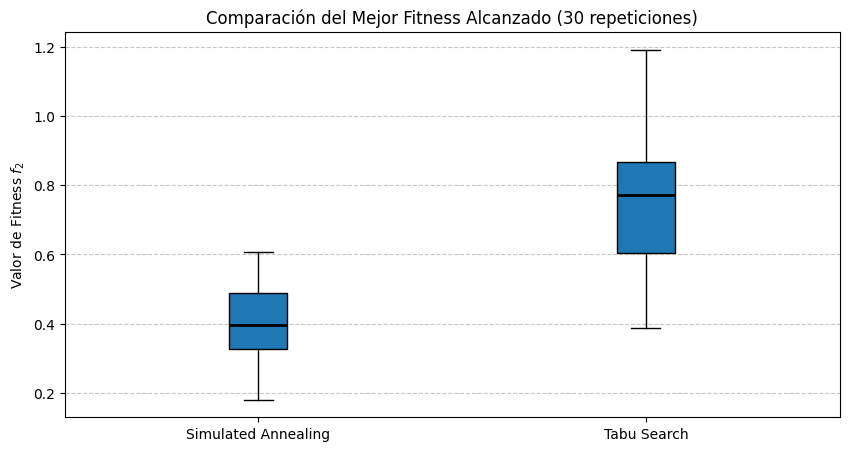

In [ ]:
fitness_sa = [res[0] for res in results_sa]
fitness_ts = [res[0] for res in results_ts]

plt.figure(figsize=(10, 5))
box = plt.boxplot([fitness_sa, fitness_ts],
                  patch_artist=True,
                  tick_labels=['Simulated Annealing', 'Tabu Search'],
                  medianprops=dict(color='black', linewidth=2))

plt.title('Comparación del Mejor Fitness Alcanzado (30 repeticiones)')
plt.ylabel('Valor de Fitness $f_2$')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**Visualización 2.2: Curvas de convergencia**

Generar un gráfico de convergencia mostrando cómo evoluciona el mejor fitness en función del número de evaluaciones para cada algoritmo.

**Especificaciones**:
- Para cada algoritmo, registrar el mejor fitness alcanzado en evaluaciones: 100, 200, ..., 4900, 5000 (50 puntos)
- Calcular la **mediana** del mejor fitness en cada punto (sobre las 30 repeticiones)
- Calcular los **percentiles 25 y 75** en cada punto
- Graficar:
  * Eje X: Número de evaluaciones (0 a 5000)
  * Eje Y: Mejor fitness alcanzado
  * Para cada algoritmo: línea sólida para la mediana, área sombreada entre P25-P75
  * Usar colores distintivos por algoritmo


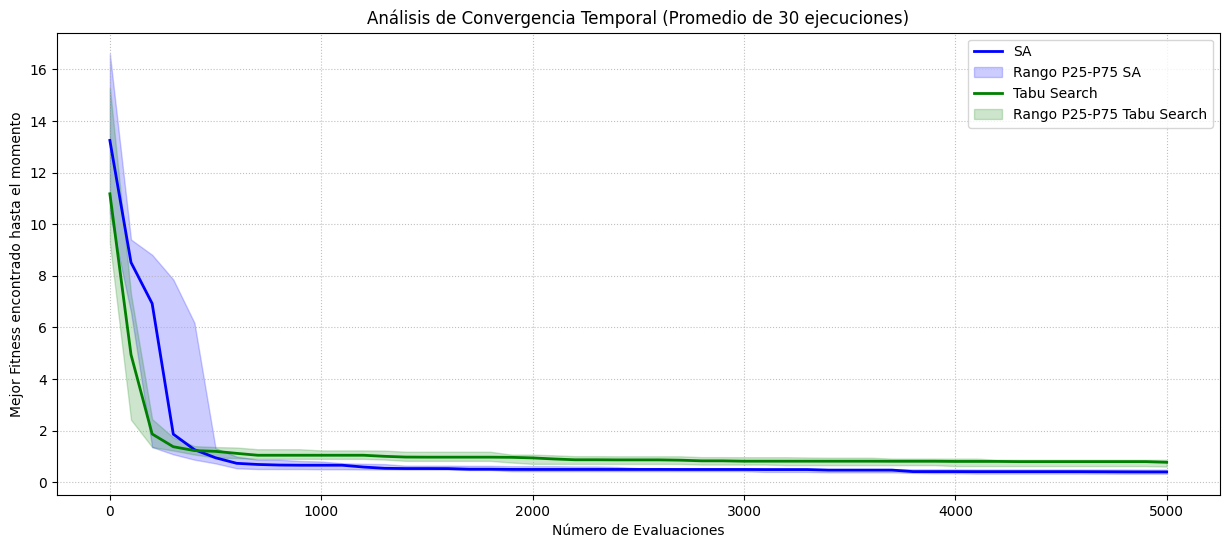

In [ ]:
hist_sa_arr = np.array([res[3] for res in results_sa])
hist_ts_arr = np.array([res[3] for res in results_ts])

# Eje X: 0, 100, 200, ..., 5000 evaluaciones
evals = np.arange(0, 5001, 100)

def graficar_banda_convergencia(evals, data, label, color):
    # Calculamos la mediana y percentiles por columna (eje de las evaluaciones)
    mediana = np.median(data, axis=0)
    p25 = np.percentile(data, 25, axis=0)
    p75 = np.percentile(data, 75, axis=0)

    # Línea de la mediana
    plt.plot(evals, mediana, label=label, color=color, linewidth=2)
    # Área sombreada (Percentiles 25 a 75)
    plt.fill_between(evals, p25, p75, color=color, alpha=0.2, label=f'Rango P25-P75 {label}')

plt.figure(figsize=(15, 6))

graficar_banda_convergencia(evals, hist_sa_arr, 'SA', 'blue')
graficar_banda_convergencia(evals, hist_ts_arr, 'Tabu Search', 'green')

plt.title('Análisis de Convergencia Temporal (Promedio de 30 ejecuciones)')
plt.xlabel('Número de Evaluaciones')
plt.ylabel('Mejor Fitness encontrado hasta el momento')
plt.legend()
plt.grid(True, which="both", linestyle=':', alpha=0.8)

plt.show()


**Interpretación requerida**: Observando las curvas, analizar:

1. ¿Qué algoritmo converge más rápidamente en las primeras 1000 evaluaciones?

SA converge más rápido.

2. ¿Algún algoritmo continúa mejorando significativamente después de 3000 evaluaciones, o todos se estabilizan?

Ambos algorítmos se estabilizan luego de las 1000 evaluaciones.

3. ¿Cuál tiene la banda de variabilidad (P25-P75) más estrecha? ¿Qué indica sobre su consistencia?

Tabu tiene una variabilidad menor, especialmente entre la primera evaluación y la 500.

4. ¿En qué rango de evaluaciones ocurre la mayor diferenciación entre algoritmos?

Desde que empieza hasta la evaluación 500.

#### Paso 3: Análisis de métricas complementarias


**Objetivo**: Complementar el análisis de fitness con métricas adicionales que proporcionen perspectivas diferentes sobre el rendimiento.



**Métrica 4.1: Distancia al óptimo global**

Para cada algoritmo, calcular estadísticas de la distancia euclidiana al óptimo $(0,0)$:

$$d_i = \sqrt{x_{\text{best},i}^2 + y_{\text{best},i}^2}, \quad i = 1, \ldots, 30$$



Calcular y reportar:

| Algoritmo | Dist. media | Dist. mediana | Dist. mínima | Dist. máxima |
|-----------|-------------|---------------|--------------|--------------|
| SA        | 0.1309         | 0.1047            | 0.0116           | 0.3665           |
| Tabu      | 0.4927         | 0.4437           | 0.0476          | 1.3739          |

**Interpretación**: ¿El algoritmo con mejor fitness también tiene menor distancia promedio? ¿O hay discrepancias?

SA que tiene mejor fitness también tiene menor distnacia promedio.

In [ ]:
def stats_distancia(data_algoritmo):
    # data_algoritmo[i][1] contiene el vector [x, y]
    distancias = [np.linalg.norm(res[1]) for res in data_algoritmo]
    return {
        'mean': np.mean(distancias),
        'median': np.median(distancias),
        'min': np.min(distancias),
        'max': np.max(distancias)
    }

dist_sa = stats_distancia(results_sa)
dist_ts = stats_distancia(results_ts)

print("| Algoritmo | Dist. media | Dist. mediana | Dist. mínima | Dist. máxima |")
print("|-----------|-------------|---------------|--------------|--------------|")
for nombre, d in zip(["SA", "Tabu"], [dist_sa, dist_ts]):
    print(f"| {nombre:9} | {d['mean']:11.4f} | {d['median']:13.4f} | {d['min']:12.4f} | {d['max']:12.4f} |")

| Algoritmo | Dist. media | Dist. mediana | Dist. mínima | Dist. máxima |
|-----------|-------------|---------------|--------------|--------------|
| SA        |      0.1309 |        0.1047 |       0.0116 |       0.3665 |
| Tabu      |      0.4927 |        0.4437 |       0.0476 |       1.3739 |



**Métrica 4.2: Tasa de éxito ($\varepsilon$-optimalidad)**

Definir una solución como **$\varepsilon$-óptima** si $f(x,y) < \varepsilon$. Para cada $\varepsilon \in \{1.0, 0.5, 0.1\}$, contar cuántas de las 30 repeticiones alcanzaron este nivel.



Reportar en tabla:

| $\varepsilon$ | SA | Tabu |
|:-------------:|:--:|:----:|
| 1.0           |30 de 30 | 27 de 30 |
| 0.5           |27 de 30 | 4 de 30 |
| 0.1           |0 de 30 | 0 de 30 |


In [ ]:
epsilons = [1.0, 0.5, 0.1]

#fitness_rand = [res[0] for res in results_random]
fitness_sa = [res[0] for res in results_sa]
fitness_ts = [res[0] for res in results_ts]

def contar_exitos(fitness_list, e):
    return sum(1 for f in fitness_list if f < e)

print("| $\\varepsilon$ | SA | Tabu |")
print("|:-------------:|:--:|:----:|")

for e in epsilons:
    count_sa = contar_exitos(fitness_sa, e)
    count_ts = contar_exitos(fitness_ts, e)

    print(f"| {e:13.1f} | {count_sa:2} de 30 | {count_ts:2} de 30 |")

| $\varepsilon$ | SA | Tabu |
|:-------------:|:--:|:----:|
|           1.0 | 30 de 30 | 27 de 30 |
|           0.5 | 27 de 30 |  4 de 30 |
|           0.1 |  0 de 30 |  0 de 30 |



**Interpretación requerida**:

1. ¿Qué algoritmo tiene mayor tasa de éxito en encontrar soluciones de alta calidad ($\varepsilon = 0.1$)?

Ninguno de los algortímos encuentra una solución con calidad alta.

2. ¿Todos los algoritmos logran al menos una solución $\varepsilon < 1.0$, o alguno falla sistemáticamente?

Si, ambos algoritmos logran soluciones con un epsilon menor a 1.0

3. ¿Esta métrica de "tasa de éxito" ofrece una perspectiva diferente al fitness promedio? Explicar.

Podría pasar que Tabu haya encontrada una solución con calidad alta ($\varepsilon = 0.1$) y que tenga peor fitness, aunque no fue el caso. Por lo tanto, en este escenario sigue indicando que SA obtuvo mejores resultados.

### 3.3 Análisis cualitativo

Más allá de las estadísticas numéricas, el análisis cualitativo proporciona insights sobre los mecanismos subyacentes que explican las diferencias de rendimiento observadas.


#### Distribución espacial de soluciones finales



Generar un **scatter plot en 2D** que muestre la posición final de las 30 mejores soluciones encontradas por cada algoritmo, superpuesto sobre un mapa de calor (heatmap) o contour plot de la función $f_2(x,y)$:

- Eje X: coordenada $x$, Eje Y: coordenada $y$
- Marcar el óptimo global $(0,0)$ con una cruz grande
- Para cada algoritmo, usar un color y forma de marcador distintos (ej: SA = círculos azules, Tabu = triángulos rojos)
- Opcionalmente, incluir círculos concéntricos centrados en el origen para visualizar la distancia radial al óptimo

Esta visualización revela patrones importantes:
- **Concentración espacial**: ¿Las soluciones están agrupadas en regiones específicas o dispersas?

SA agrupa a sus soluciones al rededor del óptimo global, minetras que Tabu dispersa más a sus soluciones.

- **Proximidad al óptimo**: ¿Qué algoritmo típicamente encuentra soluciones más cercanas a $(0,0)$?

SA encuentra soluciones más cercanas al (0, 0).

- **Atrapamiento en óptimos locales**: ¿Hay clusters de soluciones en óptimos locales alejados del origen?

No vemos un cluster atrapado lejos del origen para ningun algorítmo.

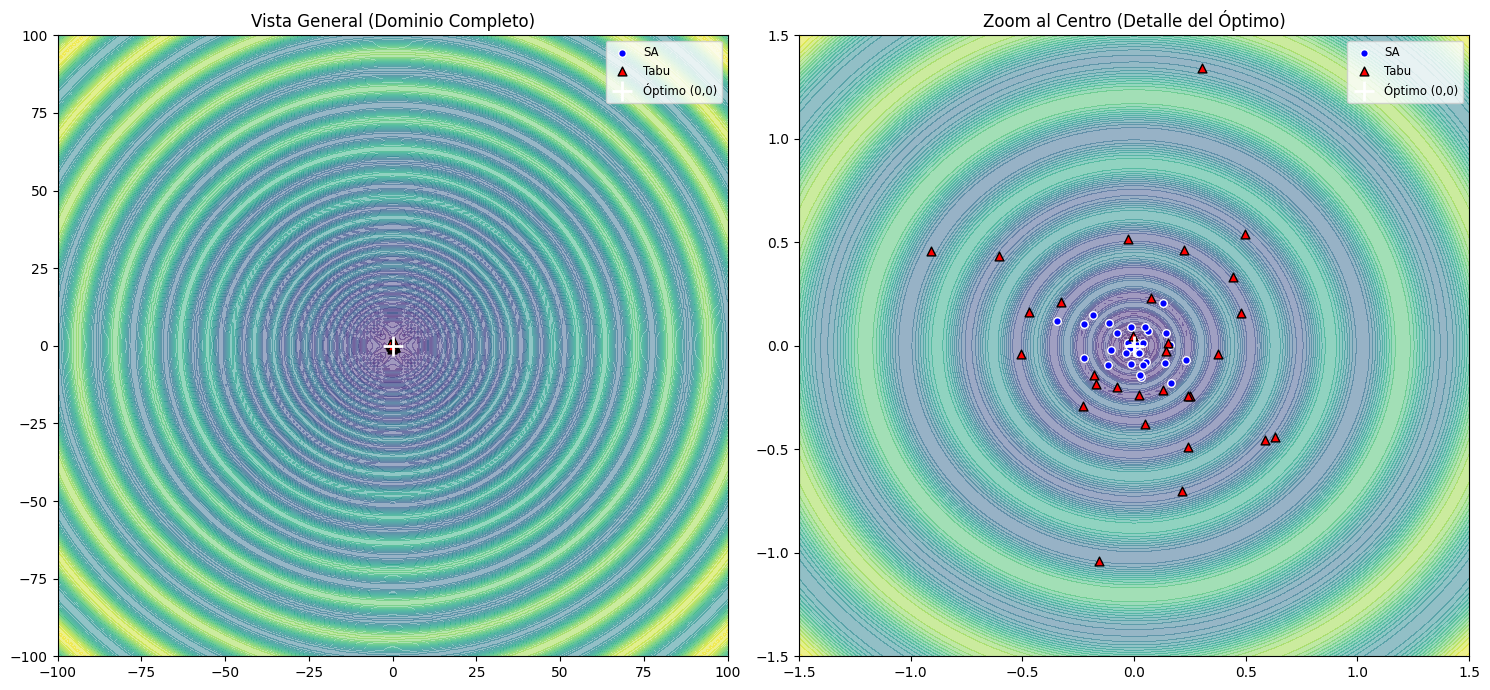

In [ ]:
def plot_distribution(ax, limit, pos_sa, pos_ts, title):
    res = 200
    x = np.linspace(-limit, limit, res)
    y = np.linspace(-limit, limit, res)
    X, Y = np.meshgrid(x, y)
    Z = (X**2 + Y**2)**0.25 * (np.sin(50 * (X**2 + Y**2)**0.1)**2 + 1)

    ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.5)

    ax.scatter(pos_sa[:, 0], pos_sa[:, 1], c='blue', marker='o', label='SA', s=30, edgecolors='white')
    ax.scatter(pos_ts[:, 0], pos_ts[:, 1], c='red', marker='^', label='Tabu', s=40, edgecolors='black')
    ax.plot(0, 0, 'w+', markersize=15, markeredgewidth=2, label='Óptimo (0,0)')

    ax.set_title(title)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.legend(fontsize='small')

# posiciones finales
pos_sa = np.array([res[1] for res in results_sa])
pos_ts = np.array([res[1] for res in results_ts])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

plot_distribution(ax1, 100, pos_sa, pos_ts, "Vista General (Dominio Completo)")
plot_distribution(ax2, 1.5, pos_sa, pos_ts, "Zoom al Centro (Detalle del Óptimo)")

plt.tight_layout()
plt.show()

#### Análisis de convergencia por fases



Dividir las 5000 evaluaciones en tres fases: temprana (0-1500), intermedia (1500-3500), y tardía (3500-5000). Para cada fase y cada algoritmo, calcular:

- Proporción de mejoras significativas (mejoras $> 1\%$ sobre el mejor anterior)
- Tasa de mejora promedio en la fase

Esto permite identificar:
- **Exploración temprana**: ¿qué algoritmo encuentra buenas soluciones más rápido inicialmente?
- **Refinamiento tardío**: ¿qué algoritmo continúa mejorando en etapas avanzadas vs estancamiento?



In [ ]:
def calcular_metricas_fase(historia, indices_eval):
    start, end = indices_eval
    segmento = historia[start:end]

    if len(segmento) < 2: return 0, 0

    # proporción de mejoras significativas (> 1%)
    mejoras = 0
    for i in range(1, len(segmento)):
        if segmento[i] < segmento[i-1] * 0.99: # Mejora del 1%
            mejoras += 1
    prop_mejoras = mejoras / len(segmento)

    # tasa de mejora total en la fase
    v_inicial = segmento[0]
    v_final = segmento[-1]
    tasa_total = (v_inicial - v_final) / (v_inicial + 1e-10)

    return prop_mejoras, tasa_total

# Definición de fases (en evaluaciones)
fases = [(0, 1500), (1500, 3500), (3500, 5000)]
nombres = ["Temprana", "Intermedia", "Tardía"]

print(f"| {'Fase':10} | {'Algoritmo':7} | {'Prop. Mejoras':14} | {'Tasa Mejora %':14} |")
print("|" + "-"*12 + "|" + "-"*9 + "|" + "-"*16 + "|" + "-"*16 + "|")

for i, (ini, fin) in enumerate(fases):
    m_sa = []
    m_ts = []

    for r_sa, r_ts in zip(results_sa, results_ts):
        # SA tiene 5000 puntos en historia (1 por eval)
        # Tabu tiene 250 puntos (1 por cada 20 evals)
        hist_sa = np.array(r_sa[3])
        # Expandimos la historia de Tabú para que tenga 5000 puntos (repetimos el valor de la iteración)
        hist_ts = np.repeat(r_ts[3], 20)

        m_sa.append(calcular_metricas_fase(hist_sa, (ini, fin)))
        m_ts.append(calcular_metricas_fase(hist_ts, (ini, fin)))

    # Promediamos las 30 repeticiones
    avg_sa = np.mean(m_sa, axis=0)
    avg_ts = np.mean(m_ts, axis=0)

    print(f"| {nombres[i]:10} | SA      | {avg_sa[0]:14.4f} | {avg_sa[1]*100:13.2f}% |")
    print(f"| {nombres[i]:10} | Tabu    | {avg_ts[0]:14.4f} | {avg_ts[1]*100:13.2f}% |")

| Fase       | Algoritmo | Prop. Mejoras  | Tasa Mejora %  |
|------------|---------|----------------|----------------|
| Temprana   | SA      |         0.1536 |         96.84% |
| Temprana   | Tabu    |         0.0044 |         93.26% |
| Intermedia | SA      |         0.0000 |          0.00% |
| Intermedia | Tabu    |         0.0000 |          0.00% |
| Tardía     | SA      |         0.0000 |          0.00% |
| Tardía     | Tabu    |         0.0000 |          0.00% |


#### Tiempo de ejecución vs calidad



Generar un **scatter plot** con:
- Eje X: tiempo promedio de ejecución (segundos)
- Eje Y: fitness promedio alcanzado
- Cada algoritmo como un punto con barras de dispersión (desvío estándar)

Alternativamente, para cada repetición individual, graficar:
- Eje X: tiempo de ejecución de esa repetición
- Eje Y: fitness alcanzado en esa repetición
- 90 puntos totales (30 por algoritmo), código de colores por algoritmo

Esto revela el **trade-off calidad vs tiempo**: un algoritmo puede encontrar mejores soluciones pero requerir más tiempo de cómputo, información relevante para decidir cuál usar en aplicaciones con límites de tiempo estrictos.



In [ ]:
import time

# Listas para almacenar (Tiempo, Fitness)
data_sa = []
data_tabu = []

for seed in range(1, 31):
    # --- Medición SA ---
    start_sa = time.perf_counter()
    res_sa = SimulatedAnnealing_2D(f=f2_sa, dom_x=dom_f2_x, dom_y=dom_f2_y, T0=T0_sa, alfa=alfa_sa, Nmax=Nmax_sa, schedule=schedule_geometrico, sigma=sigma_sa)
    end_sa = time.perf_counter()
    data_sa.append((end_sa - start_sa, res_sa[0])) # (tiempo, mejor_fitness)

    # --- Medición TABU ---
    start_ts = time.perf_counter()
    res_ts = tabu_search_2D(f2, k_tenure=50, dominio=(-100, 100), N_vecinos=20, N_max=250, sigma=10.0)
    end_ts = time.perf_counter()
    data_tabu.append((end_ts - start_ts, res_ts['Mejor Fitness']))

data_sa = np.array(data_sa)
data_tabu = np.array(data_tabu)

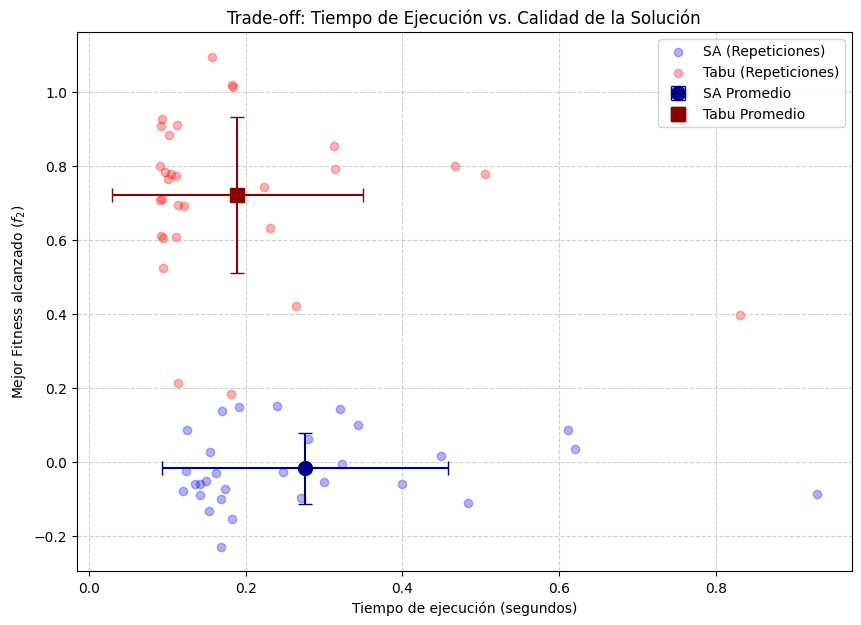

In [ ]:
plt.figure(figsize=(10, 7))

# puntos individuales
plt.scatter(data_sa[:, 0], data_sa[:, 1], c='blue', alpha=0.3, label='SA (Repeticiones)')
plt.scatter(data_tabu[:, 0], data_tabu[:, 1], c='red', alpha=0.3, label='Tabu (Repeticiones)')

# promedio y desvío Estándar
mean_sa = np.mean(data_sa, axis=0)
std_sa = np.std(data_sa, axis=0)
mean_tabu = np.mean(data_tabu, axis=0)
std_tabu = np.std(data_tabu, axis=0)

# barra de error para SA
plt.errorbar(mean_sa[0], mean_sa[1], xerr=std_sa[0], yerr=std_sa[1], fmt='o', color='darkblue', markersize=10, capsize=5, label='SA Promedio')

# barra de error para Tabu
plt.errorbar(mean_tabu[0], mean_tabu[1], xerr=std_tabu[0], yerr=std_tabu[1], fmt='s', color='darkred', markersize=10, capsize=5, label='Tabu Promedio')

plt.title('Trade-off: Tiempo de Ejecución vs. Calidad de la Solución')
plt.xlabel('Tiempo de ejecución (segundos)')
plt.ylabel('Mejor Fitness alcanzado ($f_2$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

#### Robustez: coeficiente de variación



El coeficiente de variación $CV = s/|\bar{f}|$ cuantifica la variabilidad relativa de cada algoritmo. Un $CV$ bajo indica que el algoritmo produce resultados consistentes entre repeticiones (robustez), mientras que un $CV$ alto indica alta variabilidad (sensibilidad a inicialización o aleatoriedad interna). Comparar los $CV$ de los tres algoritmos permite evaluar no solo la calidad promedio sino también la confiabilidad.



In [ ]:
# fitness finales
f_sa = np.array([res[0] for res in results_sa])
f_ts = np.array([res[0] for res in results_ts])

def info_robustez(data, nombre):
    media = np.mean(data)
    std = np.std(data, ddof=1) # Desvío estándar muestral
    cv = std / np.abs(media) if media != 0 else 0
    return media, std, cv

m_sa, s_sa, cv_sa = info_robustez(f_sa, "SA")
m_ts, s_ts, cv_ts = info_robustez(f_ts, "Tabu")

print("| Algoritmo |         Media     |    Desvío    | Coef. Variación (CV) |")
print("|-----------|-------------------|--------------|----------------------|")
print(f"| SA        | {m_sa:17.4f} | {s_sa:12.4f} | {cv_sa:20.4f} |")
print(f"| Tabu      | {m_ts:17.4f} | {s_ts:12.4f} | {cv_ts:20.4f} |")

| Algoritmo |         Media     |    Desvío    | Coef. Variación (CV) |
|-----------|-------------------|--------------|----------------------|
| SA        |            0.3892 |       0.1034 |               0.2656 |
| Tabu      |            0.7428 |       0.1954 |               0.2630 |


#### Número de soluciones que alcanzan $\varepsilon$-optimalidad



Definir una solución como $\varepsilon$-óptima si su fitness está dentro de una tolerancia del óptimo global:
$$f(x,y) < \varepsilon, \quad \text{donde } \varepsilon \in \{1.0, 0.5, 0.1\}$$

Para cada algoritmo y cada valor de $\varepsilon$, contar cuántas de las 30 repeticiones alcanzaron una solución $\varepsilon$-óptima. Presentar en una tabla:

| $\varepsilon$ | SA | Tabu |
|:-------------:|:--:|:----:|
| 1.0              | 30 | 27 |
| 0.5              | 27 | 4 |
| 0.1              | 0 | 0 |

Esto complementa las estadísticas de fitness promedio con una medida de **tasa de éxito absoluta**: no solo importa qué tan bien se desempeña en promedio, sino cuántas veces realmente resuelve el problema satisfactoriamente.


In [ ]:
epsilons = [1.0, 0.5, 0.1]

# función para contar cuántas veces se supera el umbral
def calcular_exitos(fitness_array, e):
    return np.sum(fitness_array < e)

print("| Epsilon | SA (Éxitos) | Tabu (Éxitos) |")
print("|:-------------:|:-----------:|:-------------:|")

for e in epsilons:
    exitos_sa = calcular_exitos(f_sa, e)
    exitos_ts = calcular_exitos(f_ts, e)

    # Formato: "X de 30"
    print(f"| {e:13.1f} | {exitos_sa:2} de 30 | {exitos_ts:2} de 30 |")

| Epsilon | SA (Éxitos) | Tabu (Éxitos) |
|:-------------:|:-----------:|:-------------:|
|           1.0 | 30 de 30 | 27 de 30 |
|           0.5 | 27 de 30 |  4 de 30 |
|           0.1 |  0 de 30 |  0 de 30 |


---

## **ANEXOS**

### Anexo I: *Simulated Annealing*

*Simulated Annealing* (Recocido Simulado) es una metaheurística de búsqueda por trayectorias inspirada en el proceso físico de recocido metalúrgico, donde un material se calienta a alta temperatura y luego se enfría gradualmente para alcanzar un estado de mínima energía con una estructura cristalina ordenada. La analogía entre optimización y física estadística fue formalizada por Kirkpatrick, Gelatt y Vecchi en 1983, quienes adaptaron el algoritmo de Metropolis (originalmente desarrollado para simular el comportamiento de sistemas en equilibrio térmico) al contexto de optimización combinatoria. El algoritmo permite aceptar movimientos que deterioran la función objetivo con una probabilidad que decrece exponencialmente con la magnitud del deterioro y con un parámetro de temperatura que disminuye gradualmente, proporcionando un mecanismo efectivo para escapar de óptimos locales en etapas tempranas de la búsqueda mientras se converge hacia soluciones de alta calidad en etapas tardías.


#### Fundamentos del algoritmo


En el proceso físico de recocido, un metal es calentado hasta una temperatura elevada que permite que sus átomos se muevan libremente, redistribuyéndose en el espacio. Durante el enfriamiento lento y controlado, los átomos van asentándose gradualmente en configuraciones de menor energía, y si el enfriamiento es suficientemente lento, el sistema alcanza su estado de mínima energía, correspondiente a una estructura cristalina perfecta. Si el enfriamiento es demasiado rápido (temple), el metal puede quedar atrapado en configuraciones metaestables correspondientes a mínimos locales de energía, resultando en un material con propiedades subóptimas. Esta analogía se traduce directamente a optimización: la temperatura del sistema físico corresponde a un parámetro de control $T$ en el algoritmo, la energía del sistema corresponde al valor de la función objetivo $f(x)$, y las configuraciones atómicas corresponden a soluciones candidatas $x$ en el espacio de búsqueda.

El mecanismo central de *Simulated Annealing* es el **criterio de Metropolis**, que determina la probabilidad de aceptación de un nuevo candidato $x'$ generado a partir de la solución actual $x$. Si el candidato mejora la función objetivo ($\Delta f = f(x') - f(x) < 0$ para minimización), siempre se acepta. Si el candidato empeora la función objetivo ($\Delta f > 0$), se acepta con probabilidad:

$$P(\text{aceptar}) = \exp\left(-\frac{\Delta f}{T}\right) = \exp\left(-\frac{f(x') - f(x)}{T}\right)$$

donde $T > 0$ es la temperatura actual del sistema. Esta probabilidad de aceptación tiene propiedades importantes: (1) decrece exponencialmente con $\Delta f$, lo que significa que deterioros grandes son menos probables de ser aceptados que deterioros pequeños, (2) aumenta con $T$, permitiendo mayor exploración a temperaturas altas, y (3) tiende a cero cuando $T \to 0$, convergiendo al comportamiento de *Hill Climbing* puro en las etapas finales de la búsqueda.

El balance entre exploración y explotación en *Simulated Annealing* está directamente controlado por el parámetro de temperatura. A temperaturas altas ($T \gg \Delta f$), la probabilidad de aceptación se aproxima a 1, haciendo que el algoritmo se comporte similarmente a una caminata aleatoria que acepta casi cualquier movimiento, favoreciendo la exploración extensiva del espacio de búsqueda. A temperaturas bajas ($T \ll \Delta f$), la probabilidad de aceptación se aproxima a 0, haciendo que el algoritmo se comporte como *Hill Climbing*, aceptando solo movimientos que mejoran la solución actual, favoreciendo la explotación intensiva de la región local. A temperaturas intermedias, el algoritmo exhibe un comportamiento balanceado que permite escapar de óptimos locales poco profundos mientras se explota eficientemente regiones prometedoras.

El pseudocódigo formal de *Simulated Annealing* para minimización se presenta a continuación:

$$
\begin{array}{ll}
\hline
\textbf{Algoritmo:} & \textbf{Simulated Annealing (SA)} \\
\hline
\textbf{Entrada:} & \text{Función objetivo } f, \text{ dominio } \mathcal{D}, \text{ temperatura inicial } T_0 > 0, \\
& \text{tasa de enfriamiento } \alpha \in (0,1), \text{ número máximo de iteraciones } N_{\text{max}} \\
\textbf{Salida:} & \text{Mejor solución } x^* \text{ y su fitness } f(x^*) \\
\hline
\end{array}
$$

$$
\begin{array}{ll}
1: & x \leftarrow \text{Inicialización\_Aleatoria}(\mathcal{D}) \\
2: & x_{\text{best}} \leftarrow x \\
3: & f_{\text{current}} \leftarrow f(x) \\
4: & f_{\text{best}} \leftarrow f_{\text{current}} \\
5: & T \leftarrow T_0 \\
6: & \textbf{for } t = 1 \text{ to } N_{\text{max}} \textbf{ do} \\
7: & \quad x' \leftarrow \text{Generar\_Vecino}(x) \quad \triangleright \text{ Perturbación estocástica} \\
8: & \quad f' \leftarrow f(x') \\
9: & \quad \Delta f \leftarrow f' - f_{\text{current}} \\
10: & \quad \textbf{if } \Delta f < 0 \textbf{ then} \quad \triangleright \text{ Mejora: siempre aceptar} \\
11: & \quad \quad x \leftarrow x' \\
12: & \quad \quad f_{\text{current}} \leftarrow f' \\
13: & \quad \textbf{else} \quad \triangleright \text{ Empeoramiento: aceptar probabilísticamente} \\
14: & \quad \quad p \leftarrow \exp(-\Delta f / T) \\
15: & \quad \quad r \leftarrow U(0,1) \quad \triangleright \text{ Número aleatorio uniforme} \\
16: & \quad \quad \textbf{if } r < p \textbf{ then} \\
17: & \quad \quad \quad x \leftarrow x' \\
18: & \quad \quad \quad f_{\text{current}} \leftarrow f' \\
19: & \quad \quad \textbf{end if} \\
20: & \quad \textbf{end if} \\
21: & \quad \textbf{if } f_{\text{current}} < f_{\text{best}} \textbf{ then} \quad \triangleright \text{ Actualizar mejor global} \\
22: & \quad \quad x_{\text{best}} \leftarrow x \\
23: & \quad \quad f_{\text{best}} \leftarrow f_{\text{current}} \\
24: & \quad \textbf{end if} \\
25: & \quad T \leftarrow \text{Enfriar}(T, t, \alpha) \quad \triangleright \text{ Reducir temperatura} \\
26: & \textbf{end for} \\
27: & \textbf{return } (x_{\text{best}}, f_{\text{best}})
\end{array}
$$

El algoritmo mantiene dos soluciones: la solución actual $x$ que se mueve a través del espacio de búsqueda siguiendo el criterio de Metropolis, y la mejor solución encontrada hasta el momento $x_{\text{best}}$ que se actualiza cada vez que la solución actual alcanza un nuevo mínimo global observado. Esta distinción es crucial porque el algoritmo puede aceptar temporalmente soluciones de peor calidad en su trayectoria de búsqueda, pero siempre retorna la mejor solución vista a lo largo de toda la ejecución.

#### Schedules de enfriamiento

El schedule de enfriamiento (*cooling schedule*) es un componente crítico que determina cómo evoluciona la temperatura $T$ a lo largo de las iteraciones del algoritmo. Un schedule demasiado rápido conduce a convergencia prematura en óptimos locales (análogo al temple rápido en metalurgia), mientras que un schedule demasiado lento resulta en convergencia lenta y desperdicio de recursos computacionales. La literatura de *Simulated Annealing* ha desarrollado diversos schedules con diferentes propiedades teóricas y prácticas.

**Schedule geométrico (geométrico)**: Es el schedule más comúnmente utilizado en la práctica debido a su simplicidad y efectividad empírica:

$$T(t) = \alpha^t \cdot T_0, \quad t = 0, 1, 2, \ldots$$

donde $\alpha \in (0,1)$ es la tasa de enfriamiento y $T_0$ es la temperatura inicial. En cada iteración, la temperatura se multiplica por la constante $\alpha$, resultando en un decrecimiento exponencial. Valores típicos de $\alpha$ están en el rango $[0.8, 0.99]$: valores cercanos a 1 producen enfriamiento lento que permite exploración exhaustiva pero requiere más iteraciones, mientras que valores más pequeños producen enfriamiento rápido que favorece la convergencia temprana pero aumenta el riesgo de estancamiento en óptimos locales.

**Schedule logarítmico**: Propuesto en el trabajo teórico original sobre convergencia asintótica de *Simulated Annealing*:

$$T(t) = \frac{T_0}{\log(1 + t)}, \quad t = 1, 2, 3, \ldots$$

Este schedule garantiza convergencia al óptimo global con probabilidad 1 bajo ciertas condiciones técnicas (asumiendo que el algoritmo explora eventualmente todo el espacio de búsqueda), pero su enfriamiento extremadamente lento lo hace impracticable para aplicaciones reales. Se utiliza principalmente en análisis teóricos y para establecer cotas de rendimiento.

**Schedule exponencial rápido**: Para situaciones donde se dispone de presupuesto computacional limitado:

$$T(t) = T_0 \cdot \exp(-\alpha \cdot t), \quad \alpha > 0$$

donde $\alpha$ controla la velocidad de enfriamiento. Este schedule decrece más rápidamente que el geométrico para valores grandes de $\alpha$, favoreciendo la convergencia rápida a costa de menor exploración. Es útil cuando se requiere obtener buenas soluciones aproximadas en tiempos acotados estrictamente.

La siguiente tabla resume las características comparativas de estos schedules:

| Schedule | Convergencia | Exploración inicial | Costo computacional | Uso típico |
|----------|--------------|---------------------|---------------------|------------|
| Geométrico | Moderada | Alta ($\alpha \to 1$) | $O(1)$ por iteración | General, balanceado |
| Logarítmico | Muy lenta | Muy alta | $O(\log t)$ por iteración | Análisis teórico |
| Exponencial | Rápida | Baja-Moderada | $O(1)$ por iteración | Límites de tiempo estrictos |

### Anexo II: Tabu Search

*Tabu Search* (Búsqueda Tabú) es una metaheurística de búsqueda por trayectorias que utiliza memoria explícita para guiar el proceso de optimización y evitar el estancamiento en óptimos locales. Desarrollada por Fred Glover en los años 1980s, esta técnica se diferencia fundamentalmente de *Simulated Annealing* en su estrategia para escapar de óptimos locales: mientras SA emplea aceptación probabilística de movimientos que empeoran la solución, *Tabu Search* mantiene una lista de movimientos o soluciones recientemente visitadas que se declaran "tabú" (prohibidas) durante un cierto número de iteraciones, forzando al algoritmo a explorar nuevas regiones del espacio de búsqueda de manera determinística. Esta memoria a corto plazo previene ciclos donde el algoritmo retornaría repetidamente a soluciones previamente visitadas, permitiendo una exploración más sistemática del espacio de búsqueda que combina intensificación en regiones prometedoras con diversificación forzada cuando se detecta estancamiento.

El comportamiento de *Tabu Search* contrasta marcadamente con *Hill Climbing*. Mientras *Hill Climbing* se detiene cuando todos los vecinos tienen peor fitness que la solución actual (estancamiento en óptimo local), *Tabu Search* continúa seleccionando el mejor vecino no-tabú disponible, incluso si empeora el fitness actual, utilizando la memoria para evitar retornar inmediatamente a soluciones previas. Este mecanismo permite al algoritmo "salir" de valles correspondientes a óptimos locales y explorar otras regiones del espacio de búsqueda. Para este trabajo práctico, utilizaremos la estrategia más simple: **almacenar las soluciones completas**, prohibiendo moverse a soluciones en el vecindario de cualquier solución tabú. Además, **no se incluirá criterio de aspiración**, manteniendo el algoritmo en su forma más básica donde las prohibiciones tabú son absolutas.

**Exploración del vecindario**: A diferencia de *Simulated Annealing* que genera un único vecino aleatorio y decide si aceptarlo, *Tabu Search* típicamente explora **todo el vecindario** o una muestra significativa del mismo, evaluando múltiples candidatos en cada iteración y seleccionando el mejor vecino no-tabú. Esto hace que cada iteración de *Tabu Search* sea computacionalmente más costosa que una iteración de SA, ya que requiere múltiples evaluaciones de la función objetivo. Esta diferencia es crucial para la comparación justa en la Sección 3, donde se fija el presupuesto total de evaluaciones en lugar del número de iteraciones.

El pseudocódigo formal de *Tabu Search* para minimización se presenta a continuación:

$$
\begin{array}{ll}
\hline
\textbf{Algoritmo:} & \textbf{Tabu Search (TS)} \\
\hline
\textbf{Entrada:} & \text{Función objetivo } f, \text{ dominio } \mathcal{D}, \text{ tamaño de lista tabú (tenure) } k, \\
& \text{tamaño de vecindario } |N|, \text{ número máximo de iteraciones } N_{\text{max}} \\
\textbf{Salida:} & \text{Mejor solución } x^* \text{ y su fitness } f(x^*) \\
\hline
\end{array}
$$

$$
\begin{array}{ll}
1: & x \leftarrow \text{Inicialización Aleatoria}(\mathcal{D}) \\
2: & x_{\text{best}} \leftarrow x \\
3: & f_{\text{best}} \leftarrow f(x) \\
4: & \text{TabuList} \leftarrow \emptyset \quad \triangleright \text{ Lista vacía de tamaño máximo } k \\
5: & \textbf{for } t = 1 \text{ to } N_{\text{max}} \textbf{ do} \\
6: & \quad N(x) \leftarrow \text{Generar Vecindario}(x, |N|) \quad \triangleright \text{ Generar } |N| \text{ vecinos} \\
7: & \quad N'(x) \leftarrow N(x) \setminus \text{TabuList} \quad \triangleright \text{ Remover vecinos tabú} \\
8: & \quad \textbf{if } N'(x) = \emptyset \textbf{ then} \quad \triangleright \text{ Todos los vecinos son tabú} \\
9: & \quad \quad N'(x) \leftarrow N(x) \quad \triangleright \text{ Reiniciar (evitar deadlock)} \\
10: & \quad \textbf{end if} \\
11: & \quad x' \leftarrow \arg\min_{x_i \in N'(x)} f(x_i) \quad \triangleright \text{ Mejor vecino no-tabú} \\
12: & \quad x \leftarrow x' \quad \triangleright \text{ Siempre aceptar (determinístico)} \\
13: & \quad \text{TabuList}.\text{add}(x') \quad \triangleright \text{ Agregar a lista tabú} \\
14: & \quad \textbf{if } |\text{TabuList}| > k \textbf{ then} \quad \triangleright \text{ Mantener tamaño fijo} \\
15: & \quad \quad \text{TabuList}.\text{remove oldest}() \\
16: & \quad \textbf{end if} \\
17: & \quad \textbf{if } f(x') < f_{\text{best}} \textbf{ then} \quad \triangleright \text{ Actualizar mejor global} \\
18: & \quad \quad x_{\text{best}} \leftarrow x' \\
19: & \quad \quad f_{\text{best}} \leftarrow f(x') \\
20: & \quad \textbf{end if} \\
21: & \textbf{end for} \\
22: & \textbf{return } (x_{\text{best}}, f_{\text{best}})
\end{array}
$$

#### Estructuras de memoria

La implementación eficiente de la lista tabú es crucial para el desempeño práctico de Tabu Search. En problemas de optimización continua, donde las soluciones son vectores de números reales, la gestión de la lista requiere consideraciones especiales.

**Representación de la lista tabú**: Para problemas continuos, almacenar vectores completos en la lista tabú plantea el desafío de la comparación: dos vectores de punto flotante rara vez son exactamente iguales debido a errores de redondeo numérico. Se requiere un criterio de proximidad: dos soluciones $x_1$ y $x_2$ se consideran equivalentes si $\|x_1 - x_2\| < \varepsilon$ para alguna tolerancia $\varepsilon$ apropiada. En Python, la lista puede implementarse como:

```python
tabu_list = []  # Lista de vectores numpy
tenure = 20

def is_tabu(x_candidate, tabu_list, epsilon=0.01):
    """Verifica si un candidato está en la lista tabú"""
    for x_tabu in tabu_list:
        if np.linalg.norm(x_candidate - x_tabu) < epsilon:
            return True
    return False

def add_to_tabu(x, tabu_list, tenure):
    """Agrega solución a lista tabú (FIFO)"""
    tabu_list.append(x.copy())
    if len(tabu_list) > tenure:
        tabu_list.pop(0)  # Remover más antiguo
```

**Tenure fijo vs adaptativo**: El tamaño de la lista tabú puede ser:
- **Fijo**: valor constante $k$ durante toda la ejecución (más simple, usado en este TP)
- **Adaptativo**: varía dinámicamente según el progreso de la búsqueda, aumentando cuando se detecta estancamiento (favorece diversificación) y disminuyendo cuando se encuentran mejoras (favorece intensificación)

**Gestión de la lista (FIFO)**: La estructura opera como cola: cuando se alcanza el tamaño máximo $k$ y se debe agregar un nuevo elemento, el elemento más antiguo (primero en entrar) se elimina automáticamente. Esto garantiza que prohibiciones antiguas eventualmente expiran, permitiendo que regiones previamente visitadas sean re-exploradas después de un período de exploración de otras áreas. En Python, esto puede implementarse con `collections.deque` con `maxlen=tenure` para gestión automática, o con una lista regular y remoción manual como se muestra arriba.

**Intensificación y diversificación en TS**: Aunque la lista tabú básica proporciona un mecanismo de diversificación (forzar exploración de nuevas soluciones), Tabu Search avanzado puede incorporar estrategias adicionales:
- **Intensificación**: cuando se encuentra una región prometedora, reducir temporalmente el tenure para permitir exploración exhaustiva local
- **Diversificación**: cuando se detecta estancamiento (sin mejora por muchas iteraciones), aumentar tenure o penalizar regiones frecuentemente visitadas

---


## **Referencias Bibliográficas**



Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). Optimization by simulated annealing. *Science*, 220(4598), 671-680. https://doi.org/10.1126/science.220.4598.671

Glover, F. (1986). Future paths for integer programming and links to artificial intelligence. *Computers & Operations Research*, 13(5), 533-549. https://doi.org/10.1016/0305-0548(86)90048-1

Glover, F. (1989). Tabu search—part I. *ORSA Journal on Computing*, 1(3), 190-206. https://doi.org/10.1287/ijoc.1.3.190

Talbi, E.-G. (2009). *Metaheuristics: From Design to Implementation*. John Wiley & Sons.
- Capítulo 2: Local Search Algorithms
- Capítulo 3: Simulated Annealing and Tabu Search

Metropolis, N., Rosenbluth, A. W., Rosenbluth, M. N., Teller, A. H., & Teller, E. (1953). Equation of state calculations by fast computing machines. *The Journal of Chemical Physics*, 21(6), 1087-1092. https://doi.org/10.1063/1.1699114

Černý, V. (1985). Thermodynamical approach to the traveling salesman problem: An efficient simulation algorithm. *Journal of Optimization Theory and Applications*, 45(1), 41-51. https://doi.org/10.1007/BF00940812

Gendreau, M., & Potvin, J.-Y. (Eds.). (2010). *Handbook of Metaheuristics* (2nd ed.). Springer.
- Capítulo 3: Simulated Annealing
- Capítulo 4: Tabu Search

Henderson, D., Jacobson, S. H., & Johnson, A. W. (2003). The theory and practice of simulated annealing. In F. Glover & G. A. Kochenberger (Eds.), *Handbook of Metaheuristics* (pp. 287-319). Springer. https://doi.org/10.1007/0-306-48056-5_10

Sörensen, K., & Glover, F. (2013). Metaheuristics. In S. I. Gass & M. C. Fu (Eds.), *Encyclopedia of Operations Research and Management Science* (pp. 960-970). Springer. https://doi.org/10.1007/978-1-4419-1153-7_1167

Aarts, E., & Korst, J. (1989). *Simulated Annealing and Boltzmann Machines: A Stochastic Approach to Combinatorial Optimization and Neural Computing*. John Wiley & Sons.

Glover, F., & Laguna, M. (1997). *Tabu Search*. Springer. https://doi.org/10.1007/978-1-4615-6089-0

> *"In theory, there is no difference between theory and practice. In practice, there is."*  
> — Yogi Berra

# Resumen y Conclusiones del Trabajo Práctico

## 1. Explicación de los Algoritmos Utilizados

En este trabajo práctico se implementaron y compararon dos metaheurísticas de búsqueda por trayectorias diseñadas para escapar de óptimos locales:

*   **Simulated Annealing (Recocido Simulado):**
    *   **Inspiración:** Proceso de enfriamiento de metales.
    *   **Mecanismo:** Utiliza el **Criterio de Metropolis**. Siempre acepta movimientos que mejoran el fitness y acepta movimientos que lo empeoran de forma probabilística según la temperatura actual ($P = e^{-\Delta f / T}$).
    *   **Control:** El balance entre exploración y explotación se gestiona mediante un **schedule de enfriamiento** (geométrico en este caso). A alta temperatura el algoritmo explora aleatoriamente; a baja temperatura, se comporta como un Hill Climbing.

*   **Tabu Search (Búsqueda Tabú):**
    *   **Inspiración:** Procesos cognitivos de memoria.
    *   **Mecanismo:** Emplea una **Memoria Explícita** (Lista Tabú) que prohíbe revisitar soluciones recientes durante un tiempo determinado (*tenure*).
    *   **Estrategia:** Explora un vecindario de $N$ candidatos y selecciona determinísticamente el mejor vecino no prohibido, incluso si este es peor que la solución actual. Esto obliga al algoritmo a salir de valles y explorar nuevas regiones.

## 2. Explicación de Resultados Obtenidos

Tras realizar 30 repeticiones con un presupuesto fijo de **5000 evaluaciones**, los resultados en la función 2D de Oscilación Radial muestran:

*   **Calidad de Solución:** **Simulated Annealing (SA)** superó consistentemente a Tabu Search. SA obtuvo un fitness promedio de **0.3892**, mientras que Tabu Search promedió **0.7428**.
*   **Convergencia:** SA mostró una convergencia más agresiva y rápida en las fases tempranas. Tabu Search, aunque consistente, tendió a estabilizarse en valores de fitness superiores, lo que sugiere que su mecanismo de memoria en este paisaje radial no fue tan efectivo como la aceptación probabilística de SA.
*   **Precisión Espacial:** SA logró encontrar soluciones mucho más cercanas al óptimo global $(0,0)$, con una distancia media de **0.1309**, comparado con el **0.4927** de Tabu Search.
*   **Robustez:** Ambos algoritmos presentaron coeficientes de variación similares (~0.26), lo que indica una confiabilidad comparable en cuanto a la repetitividad de sus resultados, aunque SA opera en un rango de calidad superior.

## 3. Conclusión

El análisis experimental permite concluir que **Simulated Annealing es más robusto y efectivo** para optimizar la función de Oscilación Radial bajo las condiciones dadas.

La naturaleza de la función $f_2$, con sus anillos concéntricos de óptimos locales, parece beneficiarse más de la capacidad de SA para realizar saltos probabilísticos que permiten "saltar" entre crestas, en comparación con la memoria de Tabu Search que, aunque evita ciclos, puede tener dificultades para navegar paisajes con una estructura radial tan densa si el tamaño del vecindario o la tolerancia de proximidad no están perfectamente calibrados.

Finalmente, se destaca que la calibración de hiperparámetros (como $\sigma$ y $T_0$) es el factor determinante para el éxito de estas trayectorias, siendo la transición de 1D a 2D un desafío que requiere una mayor capacidad de exploración local.